# Сборный проект — 2

## О проекте

**Описание проекта**

HR-аналитики компании «Работа с заботой» помогают бизнесу оптимизировать управление персоналом: бизнес предоставляет данные, а аналитики предлагают, как избежать финансовых потерь и оттока сотрудников. В этом HR-аналитикам пригодится машинное обучение, с помощью которого получится быстрее и точнее отвечать на вопросы бизнеса.

Компания предоставила данные с характеристиками сотрудников компании. Среди них — уровень удовлетворённости сотрудника работой в компании. Эту информацию получили из форм обратной связи: сотрудники заполняют тест-опросник, и по его результатам рассчитывается доля их удовлетворённости от 0 до 1, где 0 — совершенно неудовлетворён, 1 — полностью удовлетворён.

Собирать данные такими опросниками не так легко: компания большая, и всех сотрудников надо сначала оповестить об опросе, а затем проследить, что все его прошли.

Почему бизнесу это важно: удовлетворённость работой напрямую влияет на отток сотрудников. А предсказание оттока — одна из важнейших задач HR-аналитиков. Внезапные увольнения несут в себе риски для компании, особенно если уходит важный сотрудник.

**Цели проекта**

У нас будет несколько задач:
1. Построить модель, которая сможет предсказать уровень удовлетворённости сотрудника на основе данных заказчика.

2. Построить модель, которая сможет на основе данных заказчика предсказать то, что сотрудник уволится из компании.

**План проекта**

Задача 1 (предсказание уровня удовлетворённости сотрудника на основе данных заказчика):

1. Загрузить данные и предварительно изучить их на соответствие содержимого заявленному.

2. Предобработать данные: изучить их на наличие пропусков и дублей.

3. Провести исследовательский анализ данных: изучить закономерности и распределение данных.

4. С помощью пайплайна подготовить данные для работы с моделью.

5. Обучить несколько моделей и выбрать из них лучшую (Критерий успеха: SMAPE ≤15 на тестовой выборке).

6. Сохранить лучшую модель, подвести предварительные итоги и перейти к работе над следующей задачей.

Задача 2 (предсказание увольнения сотрудника из компании):

1. Загрузить данные и предварительно изучить их на соответствие содержимого заявленному.

2. Предобработать данные: изучить их на наличие пропусков и дублей.

3. Провести исследовательский анализ данных: изучить закономерности и распределение данных. Составить портрет уволившегося сотрудника. Проверить, влияет ли уровень удовлетворенности сотрудника на то, уволится ли сотрудник.

4. В случае обнаружения связи между уровнем удовлетворенности работой и увольнением сотрудника - добавить новый признак, предсказанный с помощью полученной в рамках решения первой задачи модели новый входной признак.

5. С помощью пайплайна подготовить данные для работы с моделью.

6. Обучить несколько моделей и выбрать из них лучшую (Критерий успеха: ROC-AUC ≥0.91 на тестовой выборке).

7. Сделать промежуточный и общие выводы.


**Описание данных**

Для полученных задач заказчик предоставил данные с признаками:

- `'id'` — уникальный идентификатор сотрудника;
- `'dept'` — отдел, в котором работает сотрудник;
- `'level'` — уровень занимаемой должности;
- `'workload'` — уровень загруженности сотрудника;
- `'employment_years'` — длительность работы в компании (в годах);
- `'last_year_promo'` — показывает, было ли повышение за последний год;
- `'last_year_violations'` — показывает, нарушал ли сотрудник трудовой договор за последний год;
- `'supervisor_evaluation'` — оценка качества работы сотрудника, которую дал руководитель;
- `'salary'` — ежемесячная зарплата сотрудника;
- `'job_satisfaction_rate'` — уровень удовлетворённости сотрудника работой в компании, целевой признак для Задачи 1;
- `'quit'` — увольнение сотрудника из компании, целевой признак для Задачи 2.

Для каждой из задач заказчик предоставил отдельные датасеты:

- `'test_features.csv'` - входные признаки тестовой выборки, общие для обеих задач;

- Для Задачи 1 (предсказание уровня удовлетворённости сотрудника):

    - `'train_job_satisfaction_rate.csv'` - тренировочая выборка;
    - `'test_target_job_satisfaction_rate.csv'` - целевой признак тестовой выборки.

- Для Задачи 2 (предсказание увольнения сотрудника из компании):

    - `'train_quit.csv'` - тренировочная выборка:
    - `'test_target_quit.csv'` - целевой признак тестовой выборки

## Подключение библиотек

Прежде, чем приступать работе, необходимо подключить необходимые для этого библиотеки и задать константы.

In [ ]:
# тестовая ячейка проверки версии библиотеки "из коробки"
# import sklearn
# sklearn.__version__

In [ ]:
# "выключаем звук" (строчки с текстом по мере загрузки) с помощью -q
!pip install phik -q # весы и корреляция
!pip install shap -q # оценка важности признаков
!pip install scikit-learn==1.5.2 -q # обновление для корректной работы некоторых частей кода
!pip install optuna -q # байесовская оптимизация перебора гиперпараметров
!pip install optuna-integration[sklearn] -q # байесовская оптимизация перебора гиперпараметров, дополнение к ней

In [ ]:
import pandas as pd
import numpy as np
import scipy.stats as st # работа со статистикой
import random # для одного из варианот выборки изи выборки; кажется, тут не пригодилась
# байесовская оптимизация перебора гиперпараметров, взяла целиком, так как отдельные элементы давали ошибки
# при sklearn 1.1.3
import optuna

# "выключаем" красные предупреждения.
# Лучше включать после того, как все сделано, чтобы для себя обращать внимание и что-то не проворонить,
# а также понимать - тот же перебор параметров по сетке еще думает и перебирает или уже завис намертво
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)

import seaborn as sns # для некоторых графиков и матриц
import matplotlib.pyplot as plt # для некоторых графиков
# дублирование на всякий случай и для будущих проетов, чтоб про нее не забыть,
# возможно не нужно, так как уже загрузили/подключили через pip, и вроде без дубля работает тоже ок
import phik # для одного из вариантов корреляции

from phik import phik_matrix # вариант матрицы корреляции
from phik.report import plot_correlation_matrix # ее отрисовка

# подготовка данных
from sklearn.model_selection import train_test_split # для разбивки на выборки для МО
from sklearn.preprocessing import(
# кодировка категориальных признаков
    OneHotEncoder, # номинальные
    OrdinalEncoder, # ранговые
    LabelEncoder, # целевой
    StandardScaler, MinMaxScaler, RobustScaler # масштабирование количественных
    )
from sklearn.impute import SimpleImputer # работа с пропусками при кодировании

# инструменты для работы с пайплайнами
from sklearn.pipeline import Pipeline # пайплайны
from sklearn.compose import ColumnTransformer # помогает работать с данными разного типа в одном наборе

# модели
from sklearn.linear_model import LogisticRegression, LinearRegression # модели логистической и линейной регресии
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor # дерево решений
from sklearn.neighbors import KNeighborsClassifier # метод k-ближайших соседей
from sklearn.svm import SVC # метод опорных векторов

# автоподбор параметров моделей
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV
from optuna.integration import OptunaSearchCV # выдает ошибку
from optuna import distributions # для настройки гиперпараметров Optuna

#кросс-валидация
from sklearn.model_selection import KFold # создание блоков
from sklearn.model_selection import cross_val_score # оценка модели на кросс-валидации

# метрики моделей
from sklearn.metrics import(
# для разных моделей
    RocCurveDisplay, # график ROC-кривой
    roc_auc_score, # ROC-AUC (площадь под ROC-кривой)
    make_scorer, # создание своей метрики
    )

# для оценки вкладов признаков
from sklearn.inspection import permutation_importance # важность перестановок
import shap # с помощью значений Шепли

In [ ]:
# задаем константы
RANDOM_STATE = 42

Теперь, после того, как все необходимые библиотеки подключены, можно приступать к решению задач.

## Задача 1: предсказание уровня удовлетворённости сотрудника

### Загрузка данных

Для данной задачи мы получили три датасета. Для начала загрузим их и посмотрим на содержимое.

In [ ]:
# загрузка тренировочной выборки
# ссылки сделаны неработоспособными в рамках этичности работы с предоставляемыми данными
try:
    train_job_satisfaction_rate = pd.read_csv('/datasets/train_job_satisfaction_rate.csv')
except:
    train_job_satisfaction_rate = pd.read_csv('https://адрес_удален/datasets/train_job_satisfaction_rate.csv')

In [ ]:
train_job_satisfaction_rate.head(20) # содержимое

,id,dept,level,workload,employment_years,last_year_promo,last_year_violations,supervisor_evaluation,salary,job_satisfaction_rate
0,155278,sales,junior,medium,2,no,no,1,24000,0.58
1,653870,hr,junior,high,2,no,no,5,38400,0.76
2,184592,sales,junior,low,1,no,no,2,12000,0.11
3,171431,technology,junior,low,4,no,no,2,18000,0.37
4,693419,hr,junior,medium,1,no,no,3,22800,0.20
5,405448,hr,middle,low,7,no,no,4,30000,0.78
6,857135,sales,sinior,medium,9,no,no,3,56400,0.56
7,400657,purchasing,middle,high,9,no,no,3,52800,0.44
8,198846,hr,junior,low,1,no,no,2,13200,0.14
9,149797,technology,middle,high,6,no,no,3,54000,0.47


In [ ]:
train_job_satisfaction_rate.shape # размер

(4000, 10)

Датасет `'train_job_satisfaction_rate'` имеет размер в 10 столбцов и 4000 строк. Содержимое соответствует описанию. Уже заметно большое количество участвующих отделов в компании, и по три уровня занимаемой должности и загруженности, что может привести к сложностям в подготовке данных (особенно - количество вариантов отделов, ведь остальные два - ранговые категориальные признаки).

Также в наличии столбец с целевым признаком, который в будущем придется отделять для работы с моделью.

Также мы не знаем, в каких единицах исчисляется ежемесячная зарплата, на какой момент времени она указана и как она считается: часто зарплата состоит из фиксированного оклада и премий, которые могут меняться, а может - и как процент от продаж. Плюс в течении года сам оклад и проценты премий могли меняться, особенно, если было повышение в должности.

In [ ]:
# загрузка входных признаков тестовой выборки
# ссылки сделаны неработоспособными в рамках этичности работы с предоставляемыми данными
try:
    test_features = pd.read_csv('/datasets/test_features.csv', na_values = ' ')
except:
    test_features = pd.read_csv('https://адрес_удален/datasets/test_features.csv', na_values = ' ')

In [ ]:
test_features.head(20) # содержимое

,id,dept,level,workload,employment_years,last_year_promo,last_year_violations,supervisor_evaluation,salary
0,485046,marketing,junior,medium,2,no,no,5,28800
1,686555,hr,junior,medium,1,no,no,4,30000
2,467458,sales,middle,low,5,no,no,4,19200
3,418655,sales,middle,low,6,no,no,4,19200
4,789145,hr,middle,medium,5,no,no,5,40800
5,429973,purchasing,middle,medium,6,no,no,3,42000
6,850699,technology,junior,medium,3,no,no,3,26400
7,500791,sales,middle,high,9,no,no,4,49200
8,767867,marketing,middle,high,3,no,yes,4,62400
9,937235,sales,junior,medium,1,no,yes,3,26400


In [ ]:
test_features.shape # размер

(2000, 9)

Датасет `'test_features'` имеет 2000 строк и 9 столбцов (столбец с целевым признаком отделен заранее), то есть составляет по количеству не треть, а даже половину от количества тренировочных данных.

Содержимое соответствует описанию и имеет те же сложности для кодирования.

In [ ]:
# загрузка целевого признака тестовой выборки
# ссылки сделаны неработоспособными в рамках этичности работы с предоставляемыми данными
try:
    test_target_job_satisfaction_rate = pd.read_csv('/datasets/test_target_job_satisfaction_rate.csv')
except:
    test_target_job_satisfaction_rate = pd.read_csv('https://адрес_удален/datasets/test_target_job_satisfaction_rate.csv')

In [ ]:
test_target_job_satisfaction_rate.head(20) # содержимое

,id,job_satisfaction_rate
0,130604,0.74
1,825977,0.75
2,418490,0.60
3,555320,0.72
4,826430,0.08
5,817219,0.76
6,269033,0.64
7,962356,0.38
8,649052,0.14
9,532834,0.59


In [ ]:
test_target_job_satisfaction_rate.shape # размер

(2000, 2)

Содержимое датасета соответствует описанию и `'test_target_job_satisfaction_rate'` составляет 2000 строк (совпадает с датасетом `'test_features'`), что, в случае совпадения `'id'` позволяет надеятся, что мы имеем данные от всех сотрудников, попавших в тестовую выборку. Для гарантии этого мы предварительно объединим эти два датасета по столбцу с `'id'`, чтобы целевой признак принял правильный порядок и установил соответствие своему работнику, а уже потом будем его отделять для проверки качества работы модели.

**Выводы**

Для исследования было получено три датасета:

- `'train_job_satisfaction_rate'` - содержит данные о работниках для тренировочной выборки вместе с целевым признаком (уровень удовлетворенности работой);
- `'test_features'` - входные признаки для тестовой выбоки;
- `'test_target_job_satisfaction_rate'` - целевой признак тестовой выборки.

Имена столбцов хоть и часто слишком длинны, но в целом соответствуют правилам хорошего тона.

Содержимое всех датасетов соответствует заявленному. Однако мы не знаем, в каких единицах исчисляется ежемесячная зарплата, на какой момент времени она указана и как она считается.

Разнообразие некоторых признаков может создать сложности в будущем моделировании.

### Предобработка данных

Изучим данные на предмет наличия пропусков и дубликатов, а также корректность типов данных столбцов.

#### Пропуски и типы данных

Посмотрим информацию о наших датасетах. Начнем с `'train_job_satisfaction_rate'`.

In [ ]:
train_job_satisfaction_rate.head() # содержимое

,id,dept,level,workload,employment_years,last_year_promo,last_year_violations,supervisor_evaluation,salary,job_satisfaction_rate
0,155278,sales,junior,medium,2,no,no,1,24000,0.58
1,653870,hr,junior,high,2,no,no,5,38400,0.76
2,184592,sales,junior,low,1,no,no,2,12000,0.11
3,171431,technology,junior,low,4,no,no,2,18000,0.37
4,693419,hr,junior,medium,1,no,no,3,22800,0.20


In [ ]:
train_job_satisfaction_rate.info() # описание

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   id                     4000 non-null   int64  
 1   dept                   3994 non-null   object 
 2   level                  3996 non-null   object 
 3   workload               4000 non-null   object 
 4   employment_years       4000 non-null   int64  
 5   last_year_promo        4000 non-null   object 
 6   last_year_violations   4000 non-null   object 
 7   supervisor_evaluation  4000 non-null   int64  
 8   salary                 4000 non-null   int64  
 9   job_satisfaction_rate  4000 non-null   float64
dtypes: float64(1), int64(4), object(5)
memory usage: 312.6+ KB


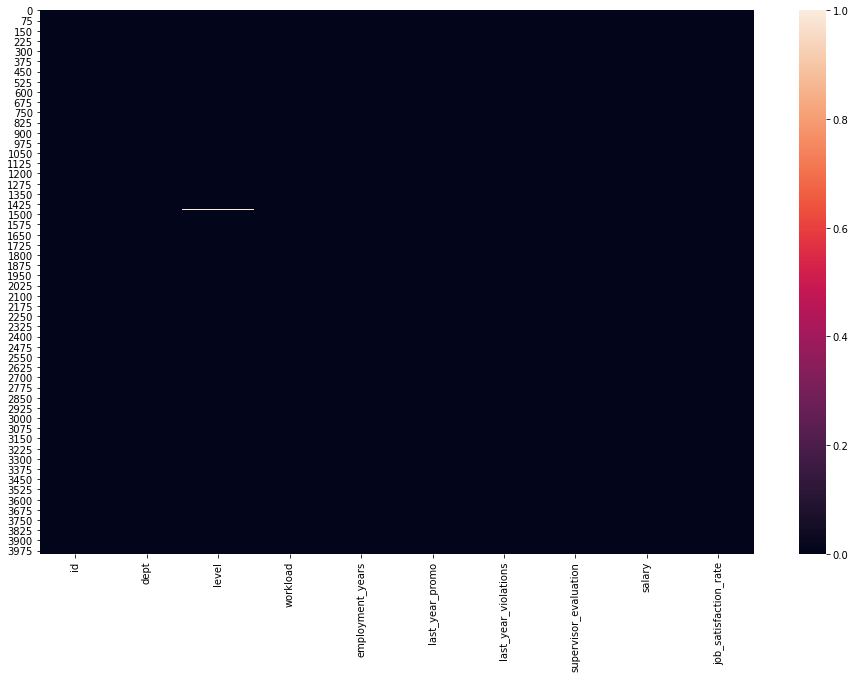

In [ ]:
# смотрим структуру
plt.figure(figsize=(16,10))
sns.heatmap(train_job_satisfaction_rate.isna())
plt.show()

Типы данных столбцов соответствуют содержимому.

Имеются пропуски в столбцах `'dept'` и `'level'`которые мы заполним в будущем (на этапе подготовки данных). Так как данные категориальные, то заполнять их будем модой (самым частопринимаемым значением).

Явные пропуски в остальных столбцах не обнаружены.

In [ ]:
test_features.head() # содержимое

,id,dept,level,workload,employment_years,last_year_promo,last_year_violations,supervisor_evaluation,salary
0,485046,marketing,junior,medium,2,no,no,5,28800
1,686555,hr,junior,medium,1,no,no,4,30000
2,467458,sales,middle,low,5,no,no,4,19200
3,418655,sales,middle,low,6,no,no,4,19200
4,789145,hr,middle,medium,5,no,no,5,40800


In [ ]:
test_features.info() # описание

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   id                     2000 non-null   int64 
 1   dept                   1997 non-null   object
 2   level                  1999 non-null   object
 3   workload               1999 non-null   object
 4   employment_years       2000 non-null   int64 
 5   last_year_promo        2000 non-null   object
 6   last_year_violations   2000 non-null   object
 7   supervisor_evaluation  2000 non-null   int64 
 8   salary                 2000 non-null   int64 
dtypes: int64(4), object(5)
memory usage: 140.8+ KB


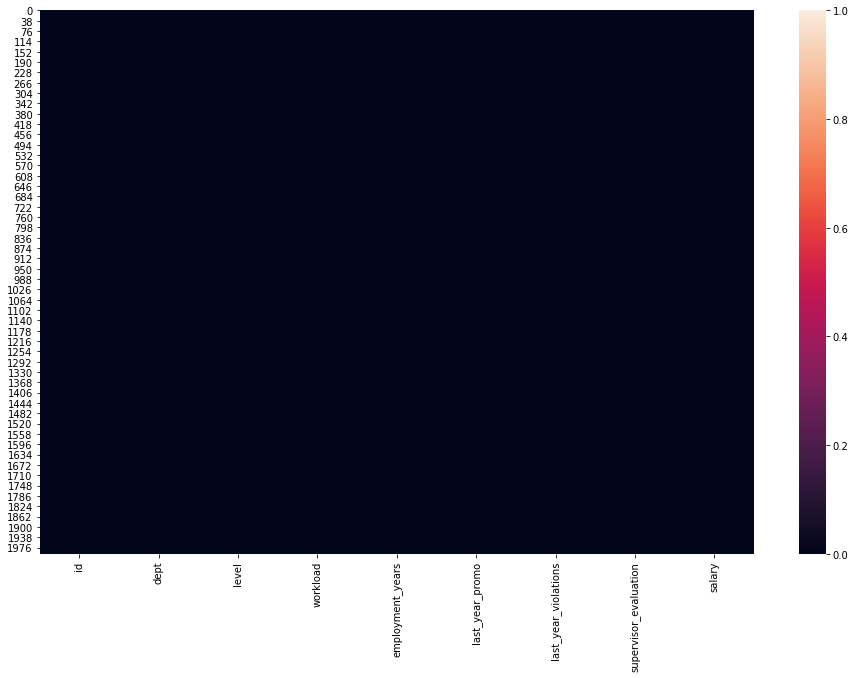

In [ ]:
# смотрим структуру
plt.figure(figsize=(16,10))
sns.heatmap(test_features.isna())
plt.show()

Столбцы `'dept'`, `'level'` и `'workload'` датасета `'test_features'` также имеют пропуска, которые будут исправляться аналогично на этапе подготовки данных.

In [ ]:
test_target_job_satisfaction_rate.head() # содержимое

,id,job_satisfaction_rate
0,130604,0.74
1,825977,0.75
2,418490,0.60
3,555320,0.72
4,826430,0.08


In [ ]:
test_target_job_satisfaction_rate.info() # описание

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 2 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   id                     2000 non-null   int64  
 1   job_satisfaction_rate  2000 non-null   float64
dtypes: float64(1), int64(1)
memory usage: 31.4 KB


Явных пропусков в датасете `'test_target_job_satisfaction_rate'` не обнаружено. Типы данных соответствуют содержимому.

***Выводы***

Типы данных соответствуют содержимому.

В датасетах `'train_job_satisfaction_rate'` имеются пропуски в столбцах `'dept'` и `'level'`, которые мы заполним модой на этапе подготовки данных. В этих же столбцах и дополнительно в столбце `'workload'`имеет пропуски и датасет `'test_features'`

В датасете `'test_target_job_satisfaction_rate'` явные пропуски не обнаружены.

#### Неявные пропуски и работа с дубликатами

Теперь посмотрим на содержимое столбцов более внимательно, а особенно - на уникальные значения в столбцах с типом данных object. Пойдем по датасетам в том же порядке.

##### `'train_job_satisfaction_rate'`

Начнем с дубликатов.

In [ ]:
train_job_satisfaction_rate.duplicated().sum() # выявление явных дубликатов

0

In [ ]:
train_job_satisfaction_rate.drop('id', axis=1).duplicated().sum() # выявление скрытых дубликатов

245

Полные дубликаты отсутствуют. Но есть 245 комплектов одинаковых данных от разных сотрудников. То есть минимум у каждого 16-17го есть коллега-"близнец". Но с учетом размера компании и ограниченности количества параметров, характеризующих сотрудника - такое вполне возможно.

А если убрать еще и целевой признак?

In [ ]:
train_job_satisfaction_rate.drop(['id', 'job_satisfaction_rate'], axis=1).duplicated().sum() # выявление скрытых дубликатов

1492

Почти полторы тысячи дубликатов из четырех! То есть множество сотрудников, имеющих одни и те же характеристики оценивают свой уровень удовлетворенности по-разному!

Модели похоже придется тяжело, в деле точного предсказать уровеня удовлетворенности. А заказчику, возможно, нужно будет ввести дополнительные параметры, характеризующие работника. Например, работает ли он в офисе или из дома, часто ли задерживается, имеет ли доступ к каким-либо бонусам от фирмы вроде бесплатного питания или скидки на абонемент в тренажерный зал?

In [ ]:
train_job_satisfaction_rate.columns # вспоминаем название столбцов тренировочный

Index(['id', 'dept', 'level', 'workload', 'employment_years',
       'last_year_promo', 'last_year_violations', 'supervisor_evaluation',
       'salary', 'job_satisfaction_rate'],
      dtype='object')

In [ ]:
len(train_job_satisfaction_rate['id'].unique()) # подсчет уникальных id

4000

Количество id совпадает с таковым у строк, то есть все id уникальны.

In [ ]:
train_job_satisfaction_rate['dept'].unique() # виды отделов

array(['sales', 'hr', 'technology', 'purchasing', 'marketing', nan],
      dtype=object)

In [ ]:
train_job_satisfaction_rate['level'].unique() # виды уровней должностей

array(['junior', 'middle', 'sinior', nan], dtype=object)

Имеем пять разных отделов и три уровня должностей.

In [ ]:
train_job_satisfaction_rate['workload'].unique() # варианты уровней загруженности работника

array(['medium', 'high', 'low'], dtype=object)

Уровней загруженности работников тоже три.

In [ ]:
sorted(train_job_satisfaction_rate['employment_years'].unique(), reverse=True) # количество лет стажа в компании

[10, 9, 8, 7, 6, 5, 4, 3, 2, 1]

Стаж работников составляет от 1 до 10 лет.

In [ ]:
train_job_satisfaction_rate['last_year_promo'].unique() # наличие повышения за последний год

array(['no', 'yes'], dtype=object)

In [ ]:
train_job_satisfaction_rate['last_year_violations'].unique() # наличие нарушений за последний год

array(['no', 'yes'], dtype=object)

Столбцы, отмечающие наличие или отсутствие повышений и нарушений у работника за последний год имеют лишь два варианта значений.

In [ ]:
# варианты оценки качества работы сотрудника со стороны руководителя
sorted(train_job_satisfaction_rate['supervisor_evaluation'].unique())

[1, 2, 3, 4, 5]

Оценка происходит по пятибальной шкале. Однако мы не знаем, какая оценка для работника является наивысшей - 1 или 5.

Перейдем к остальным датасетам.

##### `'test_features'`

In [ ]:
test_features.duplicated().sum() # выявление явных дубликатов

0

In [ ]:
test_features.drop('id', axis=1).duplicated().sum() # выявление скрытых дубликатов

557

Явных дубликатов тут нет, однако "близнецов" также много.

In [ ]:
test_features.columns # вспоминаем название столбцов

Index(['id', 'dept', 'level', 'workload', 'employment_years',
       'last_year_promo', 'last_year_violations', 'supervisor_evaluation',
       'salary'],
      dtype='object')

In [ ]:
len(test_features['id'].unique()) # подсчет уникальных id

2000

Количество id совпадает с таковым у строк, то есть все id уникальны. Однако, надо бы проверить, попали ли одинаковые id в оба датасета (для тренировочной и для тестовой выборки)?

Один из вариантов - попробовать объединить таблицы  по id с помощью merge в варианте 'inner' и сохранить в отдельный список те id, котрые останутся по итогу. Но этот способ не слишком эстетичный (хоть и проще по исполнению), поэтому применим другой.

In [ ]:
# проверка совпадений id
if any(x in train_job_satisfaction_rate['id'].unique().tolist() for x in test_features['id'].unique().tolist()):
    print("Элемент из train_job_satisfaction_rate есть в test_features")
else:
    print("Элементов из train_job_satisfaction_rate нет в test_features")

Элементов из train_job_satisfaction_rate нет в test_features


Совпадающих значений нет, а значит можно не бояться утечки данных.

In [ ]:
test_features['dept'].unique() # виды отделов

array(['marketing', 'hr', 'sales', 'purchasing', 'technology', nan],
      dtype=object)

In [ ]:
# Преобразует все значения типа float (nan в нашем случае) в строки,
# а затем отсортируем список уникальных значений столбца «dept»,
# чтобы сравнить его у двух датасетов
print(sorted(map(str, test_features['dept'].unique().tolist())) == \
      sorted(map(str, train_job_satisfaction_rate['dept'].unique().tolist())))

True


Количество отделов и сами отделы совпадают с таковыми у датасета `'train_job_satisfaction_rate'`.

In [ ]:
test_features['level'].unique() # виды уровней должностей

array(['junior', 'middle', 'sinior', nan], dtype=object)

In [ ]:
# сравниваем варианты у двух датасетов
print(sorted(map(str, test_features['level'].unique().tolist())) == \
      sorted(map(str, train_job_satisfaction_rate['level'].unique().tolist())))

True


Количество уровней и сами уровни должностей у двух датасетов совпадают.

In [ ]:
test_features['workload'].unique() # варианты уровней загруженности работника

array(['medium', 'low', 'high', nan], dtype=object)

In [ ]:
# сравниваем варианты у двух датасетов
print(sorted(map(str, test_features['workload'].unique().tolist())) == \
      sorted(map(str, train_job_satisfaction_rate['workload'].unique().tolist())))

False


Количество уровней загруженности работников совпали, и названия (визуально) - тоже. Но похоже, закралась опечатка и имеется разность в написании?

In [ ]:
train_job_satisfaction_rate['workload'].unique()

array(['medium', 'high', 'low'], dtype=object)

Похоже, несовпадение вызвано отсутствием пропусков у аналогичного столбца в `'train_job_satisfaction_rate'` и на самом деле все в порядке.

In [ ]:
sorted(test_features['employment_years'].unique(), reverse=True) # количество лет стажа в компании

[10, 9, 8, 7, 6, 5, 4, 3, 2, 1]

Количество лет стажа в компании также составляет от 1 до 10 лет.

In [ ]:
test_features['last_year_promo'].unique() # наличие повышения за последний год

array(['no', 'yes'], dtype=object)

In [ ]:
test_features['last_year_violations'].unique() # наличие нарушений за последний год

array(['no', 'yes'], dtype=object)

Столбцы, отмечающие наличие или отсутствие повышений и нарушений у работника за последний год также имеют лишь два варианта значений.

In [ ]:
# варианты оценки качества работы сотрудника со стороны руководителя
sorted(test_features['supervisor_evaluation'].unique())

[1, 2, 3, 4, 5]

Оценка также происходит по пятибальной шкале с неизвестным высшим баллом.

##### `'test_target_job_satisfaction_rate'`

In [ ]:
len(test_target_job_satisfaction_rate['id'].unique()) # подсчет уникальных id

2000

Количество id совпадает с таковым у строк, то есть все id уникальны.

In [ ]:
print(sorted(test_target_job_satisfaction_rate['id'].unique()) == sorted(test_features['id'].unique()))

True


Сами id также совпадают, а значит при объединении двух датасетов мы не потеряем информацию.

***Выводы***

В ходе изучения трех датасетов явные дубли не обнаружены. Однако в `'train_job_satisfaction_rate'` и `'test_features'` обнаружены скрытые. С учетом размера компании и ограниченности количества параметров, характеризующих сотрудника - такое вполне возможно, и на самом деле это разные сотрудники.

При этом сотрудники-"близнецы" часто оценивают уровень удовлетворенности работой по-разному, что может создать сложности для модели. Поэтому,возможно, заказчику необходимо будет ввести дополнительные параметры, характеризующие работника, чтобы лучше дифференцировать их (и учитывать и другие моменты, которые могут влиять на целевой признак). Например, работает ли он в офисе или из дома, часто ли задерживается, имеет ли доступ к каким-либо бонусам от фирмы вроде бесплатного питания или скидки на абонемент в тренажерный зал?

Написание одних и тех же параметров у `'train_job_satisfaction_rate'` и `'test_features'` совпадают, при этом одинаковых id в обоих датасетах не обнаружено. Зато id из `'test_features'` полностью совпадают с таковыми у `'test_target_job_satisfaction_rate'`, что говорит о том, что мы не потеряем данные при объединении этих двух датасетов.

Также мы не знаем, какая оценка качества работы сотрудника от руководителя является наивысшей - 1 или 5. Но по аналогии с оценками удовлетворенности (0 - совершенно неудовлетворен и 1 - полностью удовлетворен) примем, что 1 - минимальная, 5 - максимальная.

**Выводы**

1. Типы данных трех полученных датасетов соответствуют содержимому.

2. В датасетах `'train_job_satisfaction_rate'` имеются пропуски в столбцах `'dept'` и `'level'`, которые мы заполним модой на этапе подготовки данных. В этих же столбцах и дополнительно в столбце `'workload'`имеет пропуски и датасет `'test_features'`. В датасете `'test_target_job_satisfaction_rate'` явные пропуски не обнаружены.

3. Мы не знаем, какая оценка качества работы сотрудника от руководителя является наивысшей - 1 или 5. Но по аналогии с оценками удовлетворенности (0 - совершенно неудовлетворен и 1 - полностью удовлетворен) примем, что 1 - минимальная, 5 - максимальная.

4. В ходе изучения трех датасетов явные дубли не обнаружены. Однако в `'train_job_satisfaction_rate'` и `'test_features'` обнаружены скрытые. С учетом размера компании и ограниченности количества параметров, характеризующих сотрудника - такое вполне возможно. При этом сотрудники-"близнецы" часто оценивают уровень удовлетворенности работой по-разному, что может создать сложности для модели. Поэтому,возможно, заказчику необходимо будет ввести дополнительные параметры, характеризующие работника, чтобы лучше дифференцировать их (и учитывать и другие моменты, которые могут влиять на целевой признак). Например, работает ли он в офисе или из дома, часто ли задерживается, имеет ли доступ к каким-либо бонусам от фирмы вроде бесплатного питания или скидки на абонемент в тренажерный зал?

5. Написание одних и тех же параметров у `'train_job_satisfaction_rate'` и `'test_features'` совпадают, при этом одинаковых id в обоих датасетах не обнаружено. Зато id из `'test_features'` полностью совпадают с таковыми у `'test_target_job_satisfaction_rate'`, что говорит о том, что мы не потеряем данные при объединении этих двух датасетов.

### Исследовательский анализ данных

Теперь изучим данные не по форме, а по содержанию. Пойдем по датасетам в том же порядке.

#### `'train_job_satisfaction_rate'`

##### Числовые данные

Для начала взглянем на числовые данные датасета с тренировочной выборкой, чтобы сразу обнаружить яркую аномалию. А также сравнить данные (их порядки) между собой.

In [ ]:
train_job_satisfaction_rate.drop(['id'], axis = 1).describe() # общее описание

,employment_years,supervisor_evaluation,salary,job_satisfaction_rate
count,4000.000000,4000.000000,4000.000000,4000.000000
mean,3.718500,3.476500,33926.700000,0.533995
std,2.542513,1.008812,14900.703838,0.225327
min,1.000000,1.000000,12000.000000,0.030000
25%,2.000000,3.000000,22800.000000,0.360000
50%,3.000000,4.000000,30000.000000,0.560000
75%,6.000000,4.000000,43200.000000,0.710000
max,10.000000,5.000000,98400.000000,1.000000


В рамках своих столбцов данные находятся в одних порядках и большинство из них имеют неширокий "диапазон значений". Однако порядки друг относительно друга у них отличаются: что-то в единицах (`'employment_years'`, `'supervisor_evaluation'`), что-то - в долях единицы (`'job_satisfaction_rate'`), что-то и вовсе в тысячах (`'salary'`). То есть данные требуют стандартизации для последующей работы модели.

Ярких аномалий на данном этапе не наблюдается.

Посмотрим теперь каждый столбец в отдельности.

In [ ]:
# длительность работы в компании
train_job_satisfaction_rate['employment_years'].describe() # общее описание

count    4000.000000
mean        3.718500
std         2.542513
min         1.000000
25%         2.000000
50%         3.000000
75%         6.000000
max        10.000000
Name: employment_years, dtype: float64

Среднее и медиана не слишком близки, что вместе с большим стандартным отклонением говорит о неравномерности выборки.

Максимальная длительность работы сотрудниками компании составил 10 лет, минимальная - год. Нормальными значениями можно считать от 2 до 6.

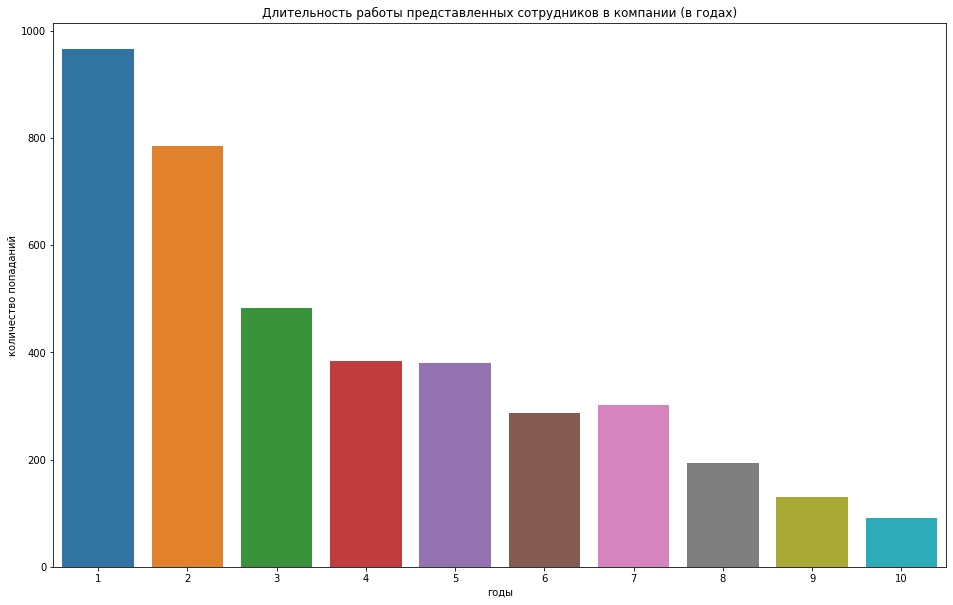

In [ ]:
# график для дискретного признака (на каждое уникальные значение признака строит свою корзину)
plt.figure(figsize=(16,10))

sns.countplot(x=train_job_satisfaction_rate['employment_years'])

plt.title('Длительность работы представленных сотрудников в компании (в годах)')
plt.xlabel('годы')
plt.ylabel('количество попаданий')

plt.show()

Как мы могли заметить ранее, признак является дискретным, а значит диаграмма размаха к нему не применима.

Распределение в выборке не является нормальным: сотрудников с большим стажем меньше, чем с меньшим. Либо сотрудники сотрудники чаще предпочитают увольняться после определенного времени работы, либо переодически происходит расширение штата и набор новых сотрудников, либо все вместе.

In [ ]:
# оценка качества работы сотрудника от руководителя
train_job_satisfaction_rate['supervisor_evaluation'].describe() # общее описание

count    4000.000000
mean        3.476500
std         1.008812
min         1.000000
25%         3.000000
50%         4.000000
75%         4.000000
max         5.000000
Name: supervisor_evaluation, dtype: float64

Среднее и медиана не слишком близки, что вместе с большим стандартным отклонением говорит о неравномерности выборки.

Максимальная оценка качества работы сотрудника от руководителя составила 5, минимальная - 1. Нормальными значениями можно считать от 3 до 4.

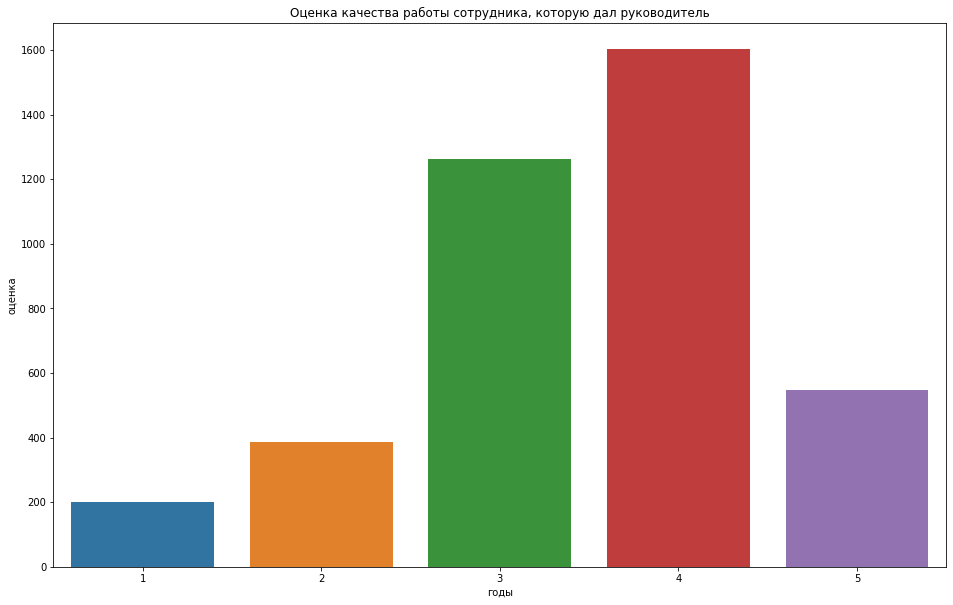

In [ ]:
# график для дискретного признака (на каждое уникальные значение признака строит свою корзину)
plt.figure(figsize=(16,10))

sns.countplot(x=train_job_satisfaction_rate['supervisor_evaluation'])

plt.title('Оценка качества работы сотрудника, которую дал руководитель')
plt.xlabel('годы')
plt.ylabel('оценка')

plt.show()

Как мы могли заметить ранее, признак является дискретным, а значит диаграмма размаха к нему не применима.

Гистограмма стремится (на сколько это возможно) к нормальному распределению.

Как мы видим, почти 200 человек получили низший балл - единицу.

Взглянем на эти строки вниметельнее.

In [ ]:
len(train_job_satisfaction_rate[train_job_satisfaction_rate['supervisor_evaluation']==1]) # считатем

201

In [ ]:
train_job_satisfaction_rate[train_job_satisfaction_rate['supervisor_evaluation']==1] # смотрим

,id,dept,level,workload,employment_years,last_year_promo,last_year_violations,supervisor_evaluation,salary,job_satisfaction_rate
0,155278,sales,junior,medium,2,no,no,1,24000,0.58
18,848242,sales,middle,high,2,yes,no,1,50400,0.39
32,176144,hr,sinior,high,3,no,no,1,72000,0.22
45,538347,technology,sinior,high,3,no,no,1,84000,0.21
53,460328,technology,junior,high,1,no,no,1,37200,0.10
64,188350,marketing,middle,high,6,no,yes,1,60000,0.31
67,990103,purchasing,middle,medium,2,no,no,1,42000,0.33
87,702721,sales,middle,medium,6,no,yes,1,31200,0.15
91,641867,technology,junior,high,1,no,no,1,44400,0.36
109,303318,marketing,junior,high,5,no,no,1,33600,0.37


Целых 201 работник удостоился минимальной из возможных оценок от своего руководителя (причем характеристики их вполне разнообразны). Немало,<s> но уже не может считаться выбросом. А вот аномалией - вполне, в том плане, что</s> *поэтому* неплохо было бы изучить, чем так плохи данные работники, и что можно предпринять для повышениния качества их труда? Например, отправить на дополнительные обучаюшие курсы или перевести на менее ответсвенную и/или загруженную должность?

А как у них с уровнем удовлетворенности работой? (так сказать, зеркальная оценка?)

In [ ]:
train_job_satisfaction_rate[train_job_satisfaction_rate['supervisor_evaluation']==1]['job_satisfaction_rate'].describe()

count    201.000000
mean       0.305423
std        0.127789
min        0.060000
25%        0.200000
50%        0.310000
75%        0.380000
max        0.580000
Name: job_satisfaction_rate, dtype: float64

Уровень удовлетворенности работой у них тоже не слишком высок. Быть может, им надоела/не нравится работа и они делают ее спустя рукава? Или не справляются с нагрузкой и возложенными задачами, а потому разочаровываются в ней? В любом случае, низкие оценки - это похоже взаимно, и это плохо. А значит тем более следует изучить проблему и пути ее решения.

В любом случае, мы не можем исключить данную группу из исследования, чтобы не пострадало качество модели (тем более, что эта группа "наиболее уязвима" ввиду низкой удовлетворенности).

In [ ]:
# создание функции для будущего описания числовых недискретных признаков
def discr_num(col_data, title, x_label):
    # Создание графиков: гистограмма и диаграмма размаха
    fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(16, 8))

    # Гистограмма
    sns.histplot(data=col_data, bins=50, kde=True, ax=axs[0])
    axs[0].set_xlabel(x_label)
    axs[0].set_ylabel('Количество попаданий в выборку')
    axs[0].set_title('Гистограмма')

    # Диаграмма размаха
    sns.boxplot(data=col_data, ax=axs[1])
    axs[1].set_xlabel(x_label)
    axs[1].set_title('Диаграмма размаха')

    # Заголовок графиков
    fig.suptitle(title)

    # Показать графики и вернуть описательные статистики
    plt.show()
    return col_data.describe()

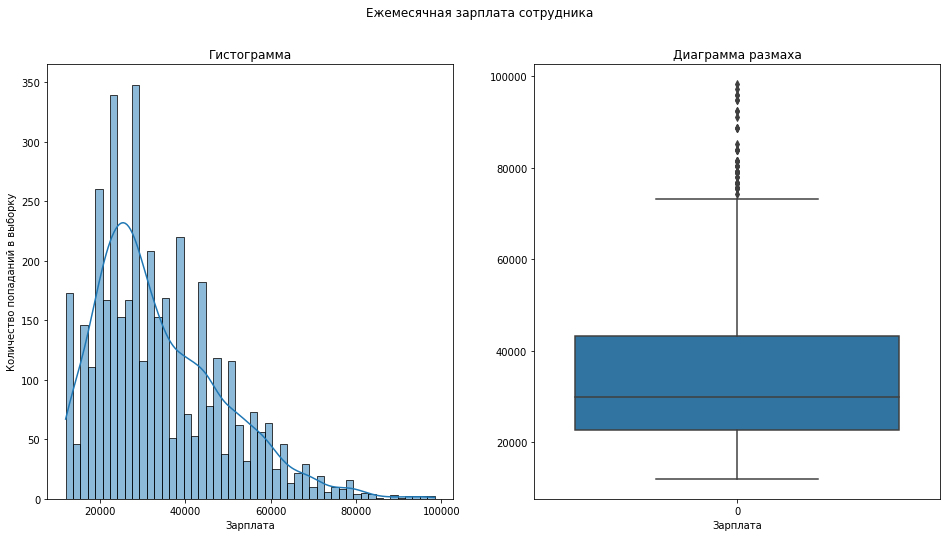

count     4000.000000
mean     33926.700000
std      14900.703838
min      12000.000000
25%      22800.000000
50%      30000.000000
75%      43200.000000
max      98400.000000
Name: salary, dtype: float64


In [ ]:
# Вызов функции discr_num и ее вывод
print(discr_num(train_job_satisfaction_rate['salary'],
                   'Ежемесячная зарплата сотрудника',
                   'Зарплата'))

Среднее и медиана относительно близки, однако большое стандартное отклонение говорит о неравномерности выборки. Возможно, есть влияние какой-то категорий.

Максимальная зарплата в компании составила 98400 неизвестных единиц, минимальная - 12000 (то есть разница более чем в 8 раз!). Нормальными значениями можно считать от 22800 до 43200 неизвестных единиц.

Распределение стремится к нормальному со смещением влево и хвостом справа.

Диаграмма размаха демонтрирует ряд выбросов после приблизительно 77000 неизвестных единиц. Возможно, это топ-менеджмент компании?

Взглянем на них.

In [ ]:
len(train_job_satisfaction_rate[train_job_satisfaction_rate['salary']>77000]) # считатем

42

In [ ]:
train_job_satisfaction_rate[train_job_satisfaction_rate['salary'] >77000] # смотрим

,id,dept,level,workload,employment_years,last_year_promo,last_year_violations,supervisor_evaluation,salary,job_satisfaction_rate
45,538347,technology,sinior,high,3,no,no,1,84000,0.21
141,128304,marketing,sinior,high,7,no,no,3,80400,0.48
360,405345,marketing,sinior,high,7,no,no,2,81600,0.58
1203,493024,technology,sinior,high,10,no,no,4,79200,0.64
1241,148024,technology,sinior,high,4,no,no,4,94800,0.67
1491,796799,marketing,sinior,high,4,no,no,3,79200,0.25
1655,611498,sales,sinior,high,8,no,no,4,78000,0.86
1718,712878,purchasing,sinior,high,9,no,yes,4,80400,0.66
1799,494125,marketing,sinior,high,10,no,no,4,84000,0.81
1855,355174,technology,sinior,high,6,no,yes,4,88800,0.74


42 сотрудника на высоких должностях и высокой нагрузкой - то есть их столь высокая зарплата вполне объяснима. И также мы не можем их исключать из исследования, чтобы модель научилась делать правильные прогнозы для всех работников.

Ради интереса вглянем и на их уровень удовлетворенности.

In [ ]:
train_job_satisfaction_rate[train_job_satisfaction_rate['salary'] >77000]['job_satisfaction_rate'].describe()

count    42.000000
mean      0.642857
std       0.208658
min       0.210000
25%       0.492500
50%       0.670000
75%       0.807500
max       0.990000
Name: job_satisfaction_rate, dtype: float64

А вот тут уже разнообразнее. Но тоже есть те, кто не удовлетворен своей работой, что может быть вредно для компании с учетом уровня квалификации подобного сотрудника.

In [ ]:
# доля удовлетворенности
train_job_satisfaction_rate['job_satisfaction_rate'].describe() # общее описание

count    4000.000000
mean        0.533995
std         0.225327
min         0.030000
25%         0.360000
50%         0.560000
75%         0.710000
max         1.000000
Name: job_satisfaction_rate, dtype: float64

Среднее и медиана достаточно близки. А вот большое стандартное отклонением говорит о неравномерности выборки.

Максимальная доля удовлетворенности сотрудника работой 1, минимальная - 0.3. Нормальными значениями можно считать от 0.36 до 0.71. Низкий уровень нижней границы "нормальности" - не очень хороший знак для компании.

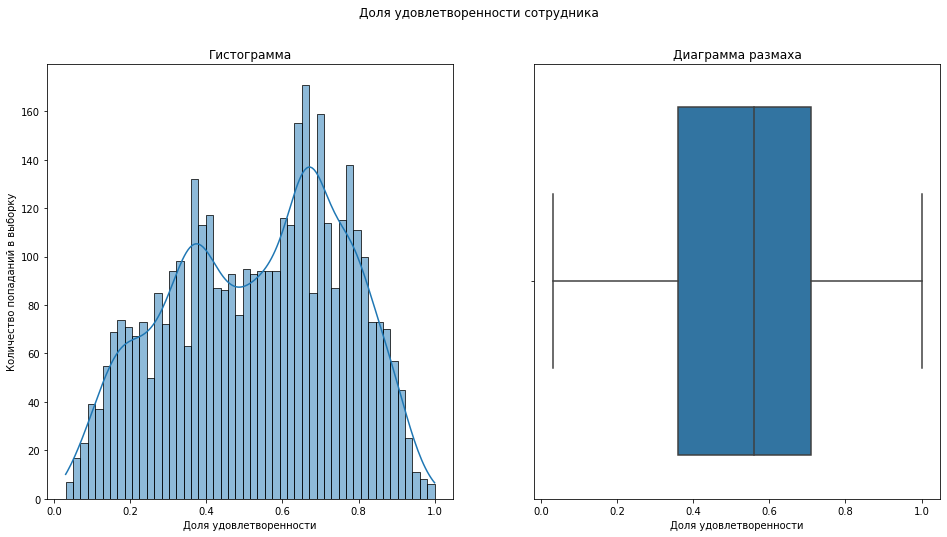

In [ ]:
# доля удовлетворенности, диаграмма размаха и гистограмма
fig, axs = plt.subplots(nrows= 1 , ncols= 2, figsize = (16,8))
sns.histplot(data = train_job_satisfaction_rate, x = 'job_satisfaction_rate', ax=axs[0], bins = 50, kde=True)
axs[0].set_xlabel('Доля удовлетворенности')
axs[0].set_ylabel('Количество попаданий в выборку')
axs[0].set_title('Гистограмма')
sns.boxplot(data = train_job_satisfaction_rate, x = 'job_satisfaction_rate', ax=axs[1])
axs[1].set_xlabel('Доля удовлетворенности')
axs[1].set_title('Диаграмма размаха')
fig.suptitle('Доля удовлетворенности сотрудника')
plt.show()

Гистограмма стремится к нормальности, однако имеет два пика (мультимодальное распределение). Выбросов на диаграмме не выявлено.

Так это - целевой признак, как мы не можем просто разбить его на две категории (до 0.5 и выше 0.5) для использования в модели ввиду того, что заказчика наверняка волнуют более точные значения. Поэтому в случае низкого качества метрик полученной модели придется придумать что-то еще.

##### Категориальные данные

Перейдем на категориальные данные.

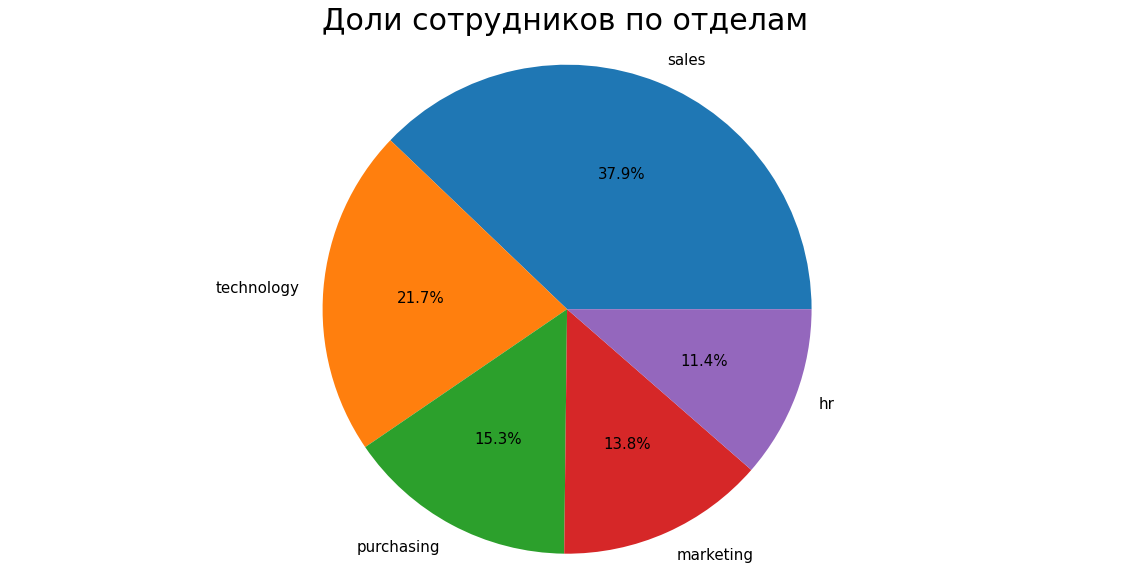

In [ ]:
# визуализируем отделы
train_job_satisfaction_rate['dept'].value_counts().plot(kind = 'pie', grid = True,\
                                     figsize = (20,10), fontsize=15, autopct='%1.1f%%')

plt.title('Доли сотрудников по отделам', fontsize=30)
plt.axis('equal')
plt.ylabel('', fontsize=13)

plt.show()

Больше всего сотрудников занято в продажах ("sales", 1е место с отрывом), технологиях ("technology", 2е), меньше - в закупках("purchasing"), маркетинге и кадрах("hr").

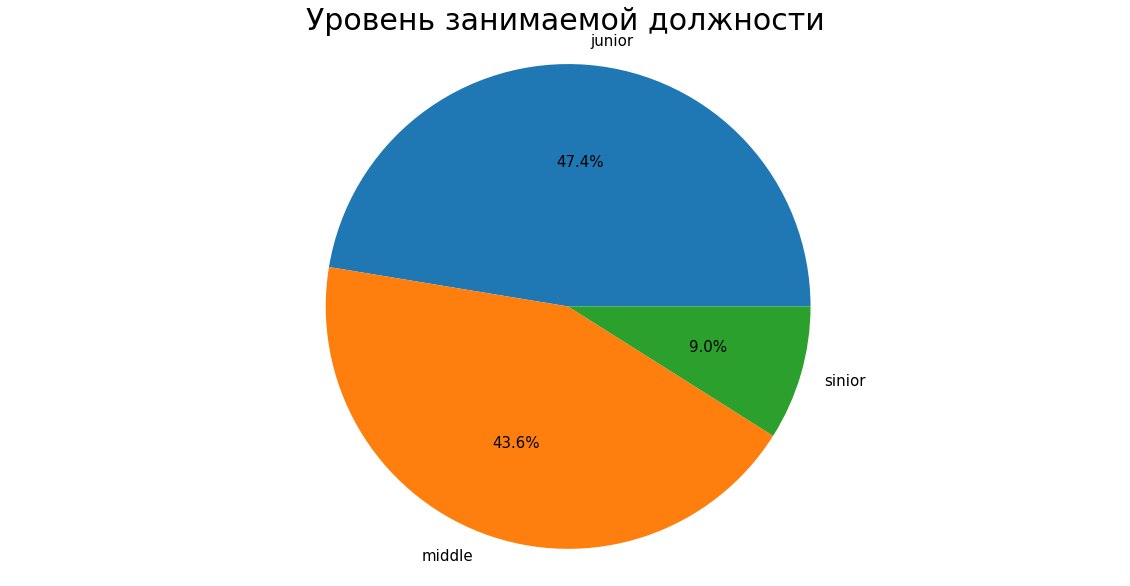

In [ ]:
# визуализируем должности
train_job_satisfaction_rate['level'].value_counts().plot(kind = 'pie', grid = True,\
                                     figsize = (20,10), fontsize=15, autopct='%1.1f%%')

plt.title('Уровень занимаемой должности', fontsize=30)
plt.axis('equal')
plt.ylabel('', fontsize=13)

plt.show()

Доли сотрудников уровня "junior" и "middle" относительно близки (но первых все-таки больше), а вот "sinior" ожидаемо гораздо меньше.

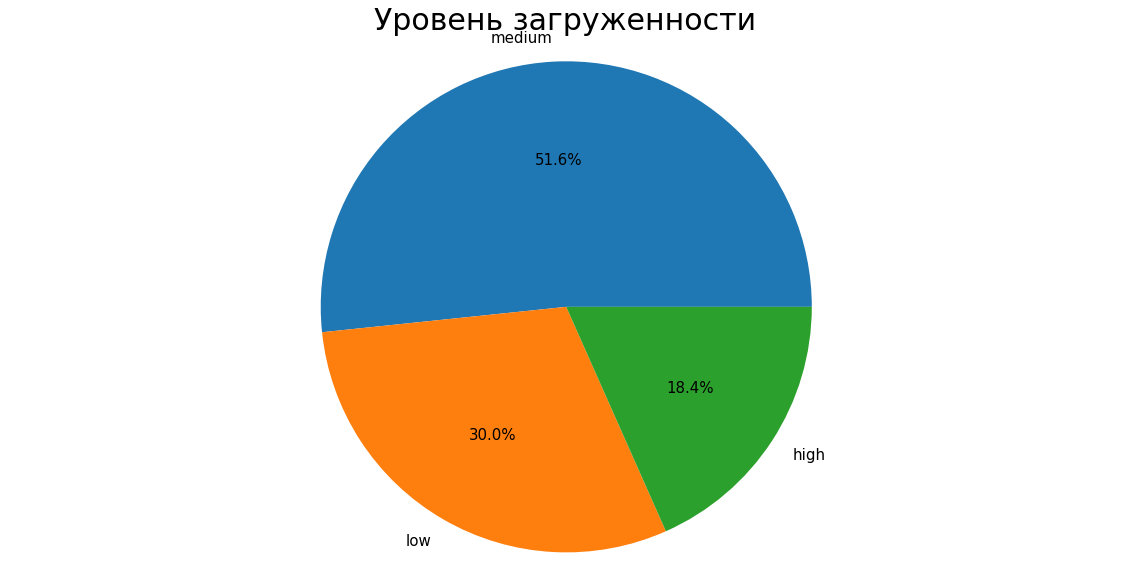

In [ ]:
# визуализируем уровень загруженности
train_job_satisfaction_rate['workload'].value_counts().plot(kind = 'pie', grid = True,\
                                     figsize = (20,10), fontsize=15, autopct='%1.1f%%')

plt.title('Уровень загруженности', fontsize=30)
plt.axis('equal')
plt.ylabel('', fontsize=13)

plt.show()

Средний уровень нагрузки занимает самую большую долю (что логично), а тяжелый - меньше всех.

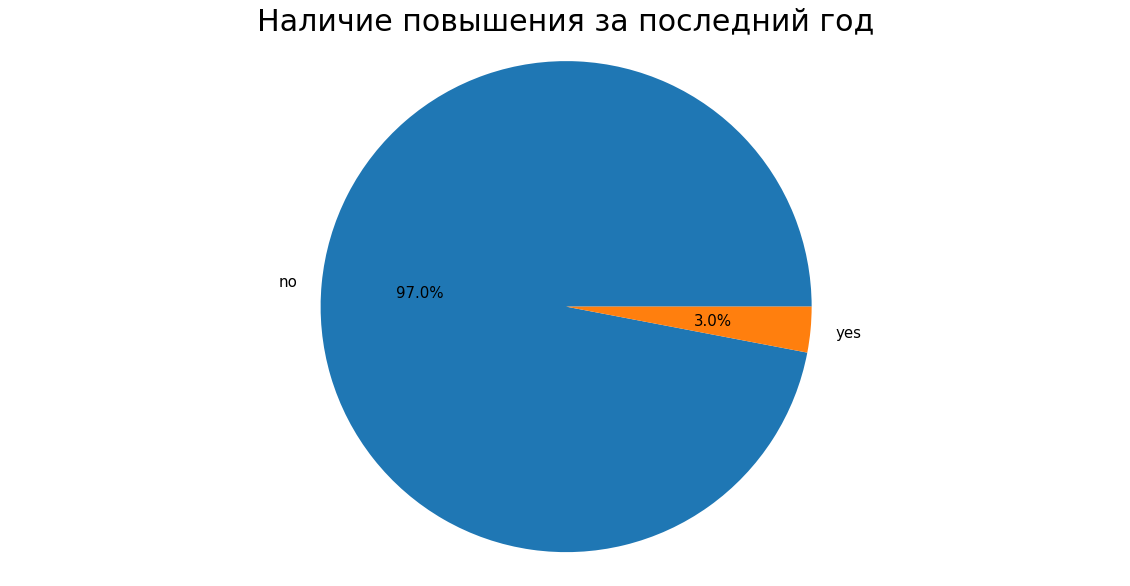

In [ ]:
# визуализируем повышения
train_job_satisfaction_rate['last_year_promo'].value_counts().plot(kind = 'pie', grid = True,\
                                     figsize = (20,10), fontsize=15, autopct='%1.1f%%')

plt.title('Наличие повышения за последний год', fontsize=30)
plt.axis('equal')
plt.ylabel('', fontsize=13)

plt.show()

Повышения выдают не так часто: лишь 3% сотрудников получили его за последний год. Это выглядит логичным: достойных сотрудников может быть много, а свободных вакансий - мало.

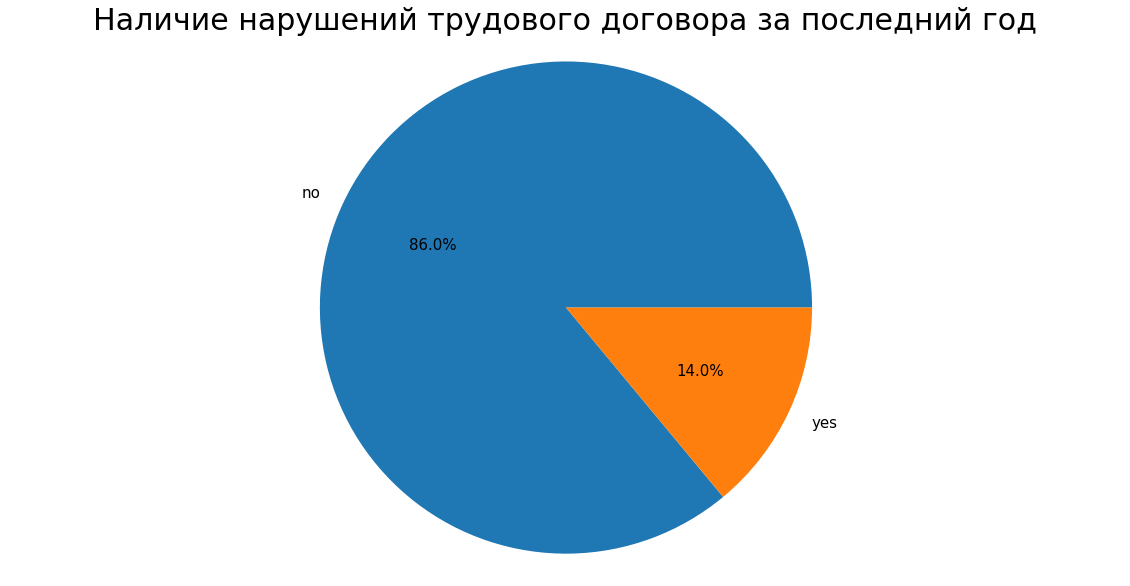

In [ ]:
# визуализируем повышения
train_job_satisfaction_rate['last_year_violations'].value_counts().plot(kind = 'pie', grid = True,\
                                     figsize = (20,10), fontsize=15, autopct='%1.1f%%')

plt.title('Наличие нарушений трудового договора за последний год', fontsize=30)
plt.axis('equal')
plt.ylabel('', fontsize=13)

plt.show()

14% сотрудников имели нарушения за прошлый год (по крайней мере, заффиксированные. Мы не знаем, сколько их было у каждого из нарушивших, и были ли какие-то упущены и не зафиксированы). С одной стороны - выглядит кажется немного. А с другой - каждый 7й сотрудний является нарушителем! Все-таки лучше выяснить, в чем именно состоят эти нарушения: опоздания ли это из-за нарушающего расписания автобуса или непредвиденных погодных условий, нежелание следовать дресс-коду, разовая неявка на частые совещания или что-то еще? И ввиду этого следует пересмотреть внутренний регламент, сделать его более гибким и комфортным не в ущерб рабочему процессу?

##### Диаграммы рассеяния

Теперь попробуем взглянуть на некоторые диаграммы рассеяния для этих признаков с учетом целевого.

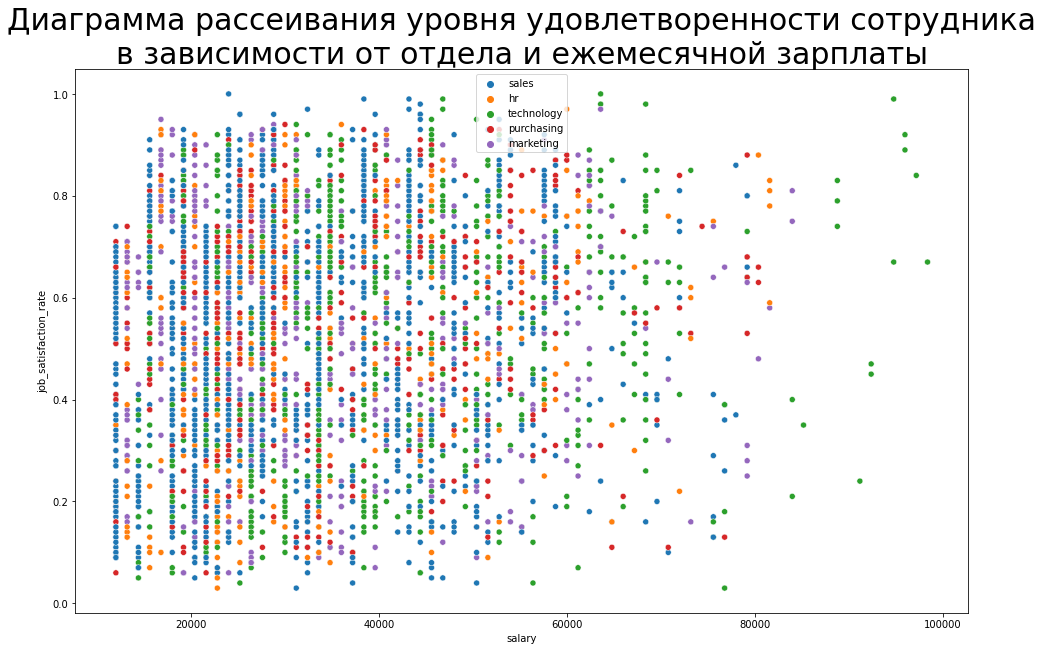

In [ ]:
# диаграмма рассеяния, вариант 1
plt.figure(figsize=(16,10))

sns.scatterplot(data=train_job_satisfaction_rate, hue='dept', x='salary', y='job_satisfaction_rate')
plt.legend(loc='upper center')
plt.title('Диаграмма рассеивания уровня удовлетворенности сотрудника\n\
в зависимости от отдела и ежемесячной зарплаты', fontsize=30)

plt.show()

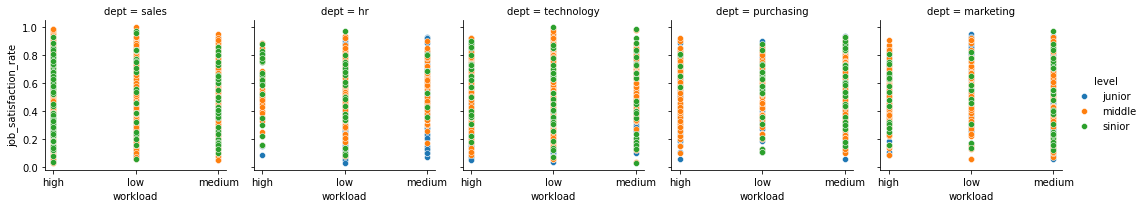

In [ ]:
# диаграмма рассеяния, вариант 2
sns.FacetGrid(train_job_satisfaction_rate, col='dept', hue='level', col_wrap=5)\
.map(sns.scatterplot, 'workload', 'job_satisfaction_rate')\
.add_legend();

plt.show()

Такие диаграммы подробны, но разглядеть на них что-то сложно (Правдо, можно обнаружить, что самые высокоплачиваемые сотрудники работают в отделе технологий, причем самые довольные из этого отдела имеют самую высокую зарплату из всех. Возможно, зарплата - один из ключей к успеху?).

Возьмем вариант попроще.

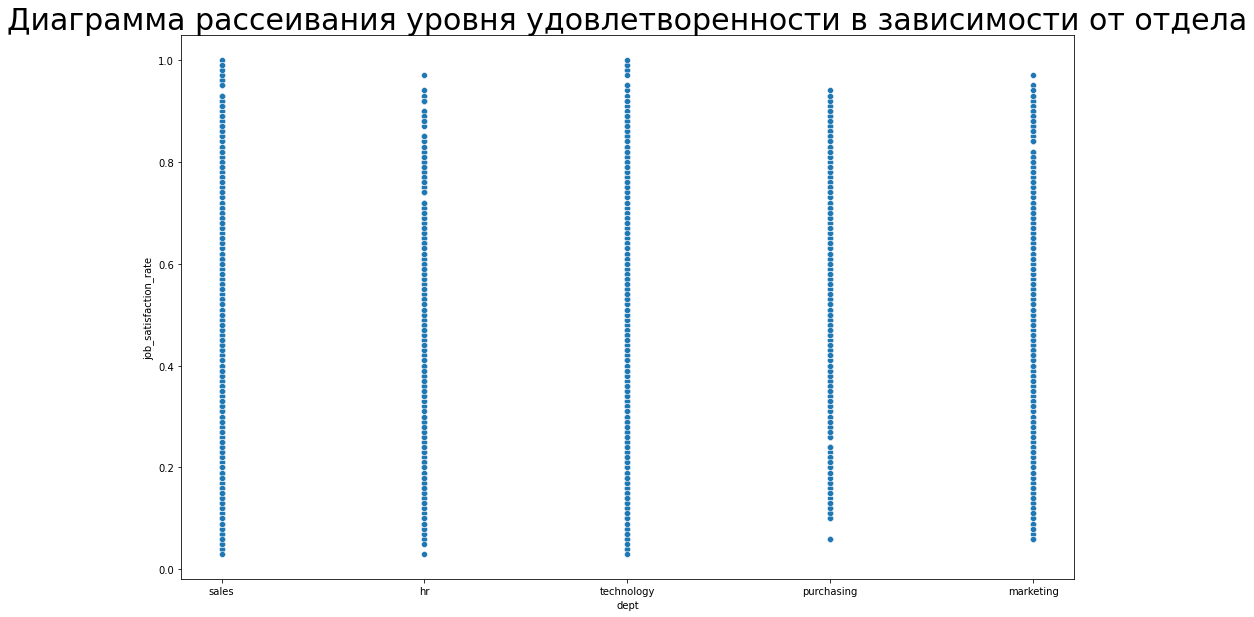

In [ ]:
# диаграмма рассеяния, вариант 3
plt.figure(figsize=(16,10))

sns.scatterplot(data=train_job_satisfaction_rate, x='dept', y='job_satisfaction_rate')

plt.title('Диаграмма рассеивания уровня удовлетворенности в зависимости от отдела', fontsize=30)

plt.show()

В целом уровень удовлетворенности не зависит от отдела.

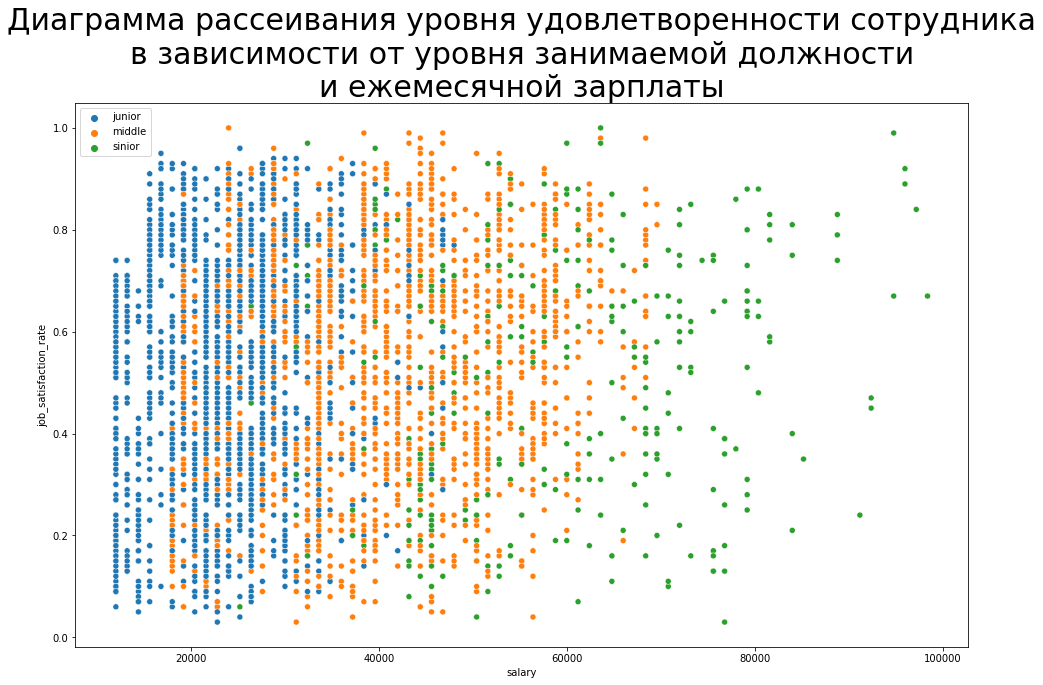

In [ ]:
# диаграмма рассеяния, вариант 1
plt.figure(figsize=(16,10))

sns.scatterplot(data=train_job_satisfaction_rate, hue='level', x='salary', y='job_satisfaction_rate')
plt.legend(loc='best')
plt.title('Диаграмма рассеивания уровня удовлетворенности сотрудника\n\
в зависимости от уровня занимаемой должности\n\
и ежемесячной зарплаты', fontsize=30)

plt.show()

Видна корреляция: чем выше уровень должности - тем выше зарплата. А вот на уровень удовлетворенности должность похоже не оказывает заметного влияния.

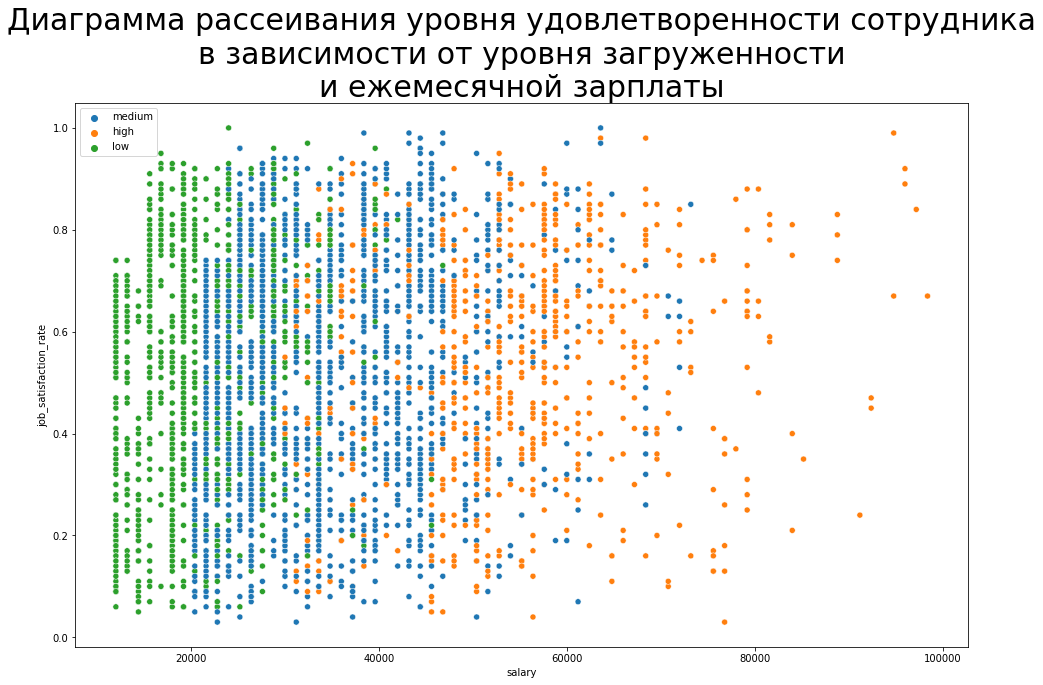

In [ ]:
# диаграмма рассеяния, вариант 1
plt.figure(figsize=(16,10))

sns.scatterplot(data=train_job_satisfaction_rate, hue='workload', x='salary', y='job_satisfaction_rate')
plt.legend(loc='best')
plt.title('Диаграмма рассеивания уровня удовлетворенности сотрудника\n\
в зависимости от уровня загруженности\n\
и ежемесячной зарплаты', fontsize=30)

plt.show()

Снова видна тенденция (пусть и с некоторыми исключениями): выше нагрузка - выше оплата.

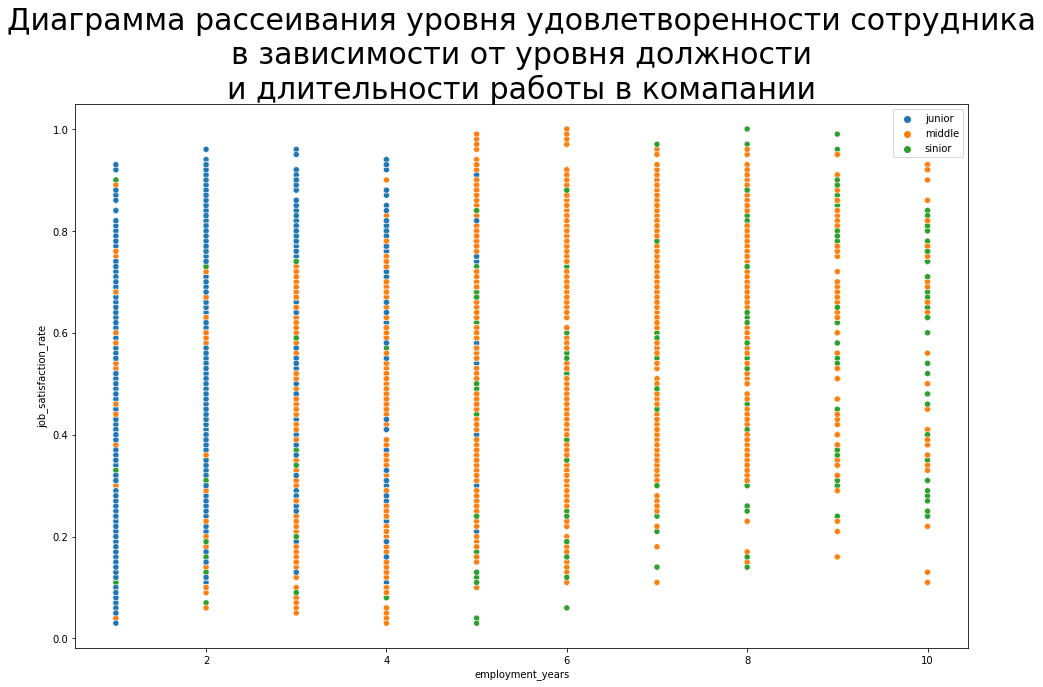

In [ ]:
# диаграмма рассеяния, вариант 1
plt.figure(figsize=(16,10))

sns.scatterplot(data=train_job_satisfaction_rate, hue='level', x='employment_years', y='job_satisfaction_rate')
plt.legend(loc='best')
plt.title('Диаграмма рассеивания уровня удовлетворенности сотрудника\n\
в зависимости от уровня должности\n\
и длительности работы в комапании', fontsize=30)

plt.show()

Уровень удовлетворенности похоже не зависит от работы и стажа, зато мы увидели, что чем меньше стаж - тем ниже уровень должности.

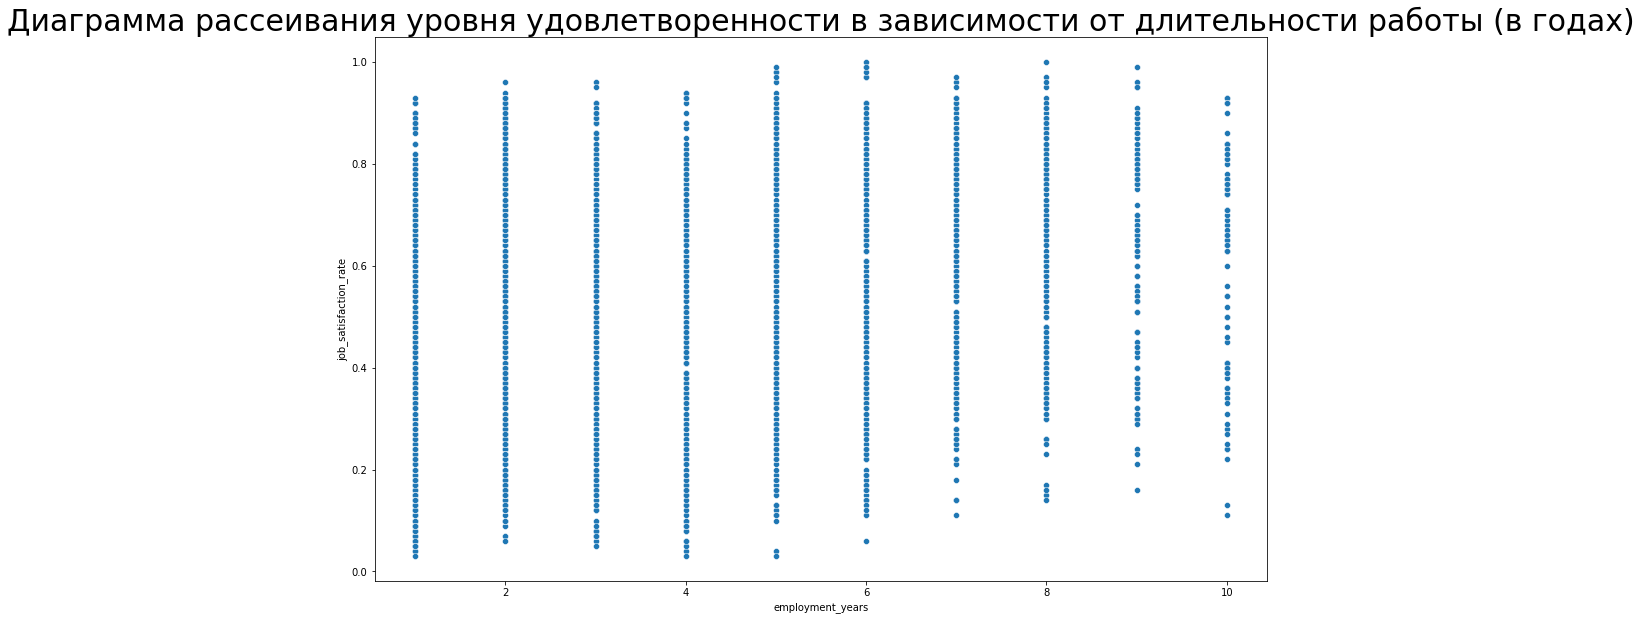

In [ ]:
# диаграмма рассеяния, вариант 3
plt.figure(figsize=(16,10))

sns.scatterplot(data=train_job_satisfaction_rate, x='employment_years', y='job_satisfaction_rate')

plt.title('Диаграмма рассеивания уровня удовлетворенности в зависимости от длительности работы (в годах)', fontsize=30)

plt.show()

Зависимость уровня удовлетворенности от длительности работы  компании не обнаружена.

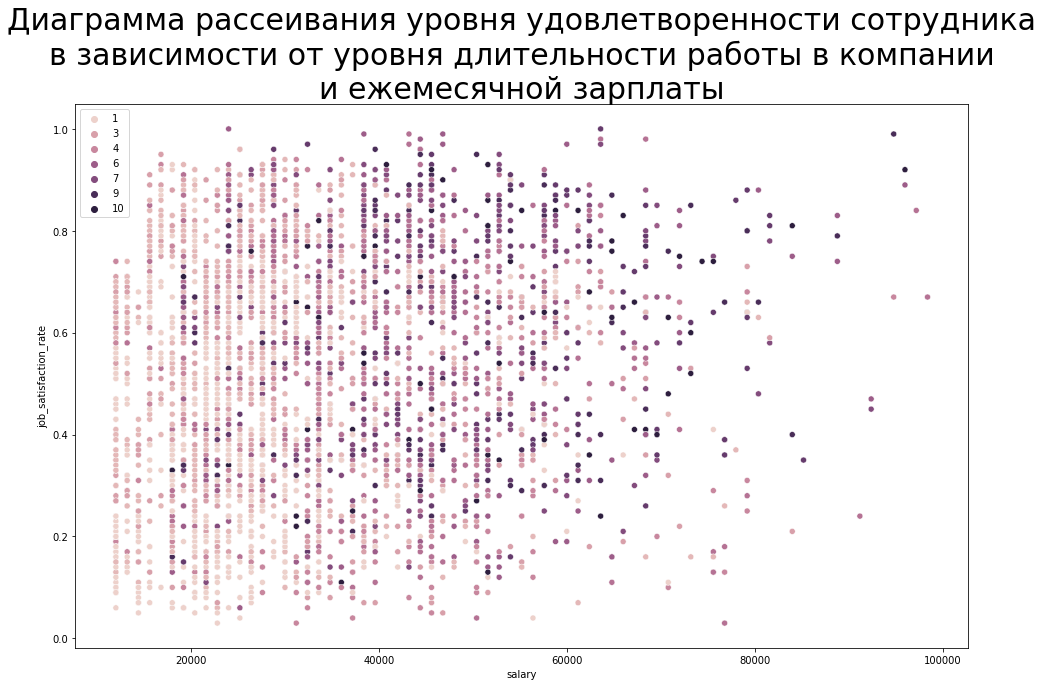

In [ ]:
# диаграмма рассеяния, вариант 1
plt.figure(figsize=(16,10))

sns.scatterplot(data=train_job_satisfaction_rate, hue='employment_years', x='salary', y='job_satisfaction_rate')
plt.legend(loc='best')
plt.title('Диаграмма рассеивания уровня удовлетворенности сотрудника\n\
в зависимости от уровня длительности работы в компании\n\
и ежемесячной зарплаты', fontsize=30)

plt.show()

Четких зависимостей уровня удовлетворенности сотрудника от уровня длительности работы в компании и ежемесячной зарплаты не выявлено.

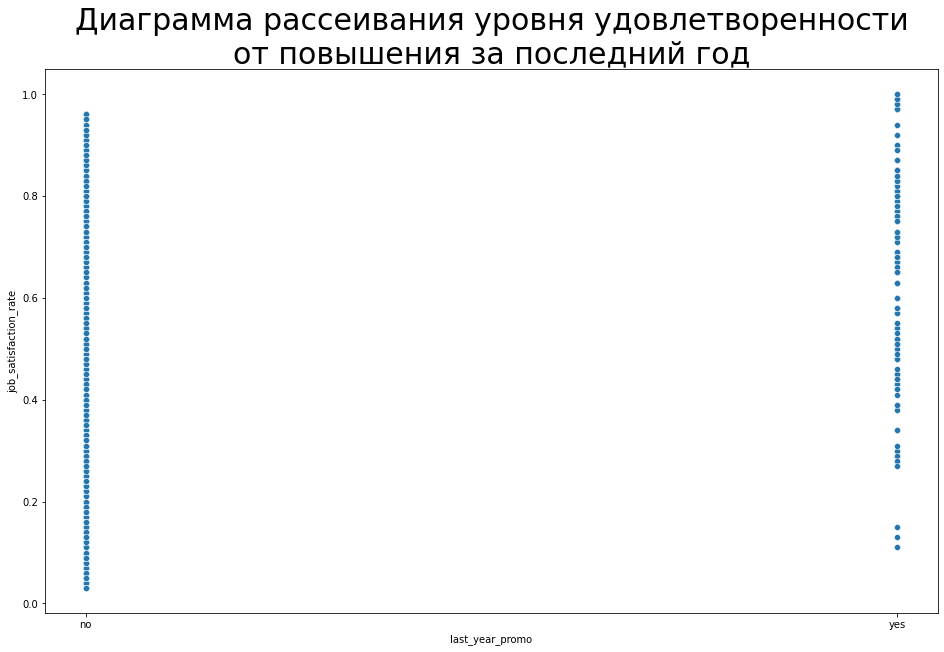

In [ ]:
# диаграмма рассеяния, вариант 3
plt.figure(figsize=(16,10))

sns.scatterplot(data=train_job_satisfaction_rate, x='last_year_promo', y='job_satisfaction_rate')

plt.title('Диаграмма рассеивания уровня удовлетворенности\n\
от повышения за последний год', fontsize=30)

plt.show()

Те, кто получали повышения, несколько более удовлетворены своей работой чем те, кто не получал.

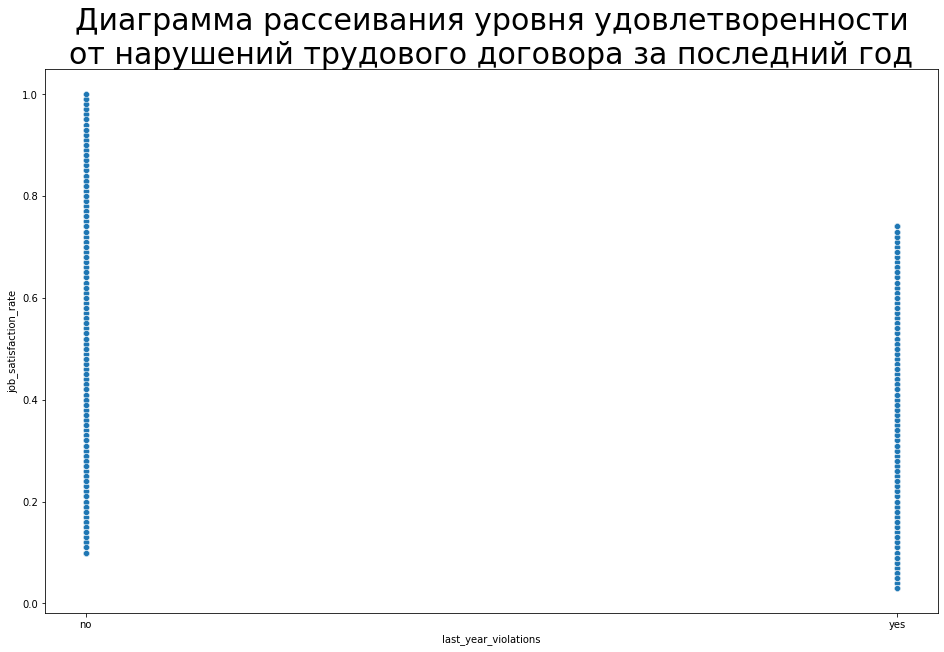

In [ ]:
# диаграмма рассеяния, вариант 3
plt.figure(figsize=(16,10))

sns.scatterplot(data=train_job_satisfaction_rate, x='last_year_violations', y='job_satisfaction_rate')

plt.title('Диаграмма рассеивания уровня удовлетворенности\n\
от нарушений трудового договора за последний год', fontsize=30)

plt.show()

Логично, что те, кто нарушал, менее удовлетворены чем те, кто нет.

Интересно, кстати, получали ли нарушители повышения?

In [ ]:
train_job_satisfaction_rate[(train_job_satisfaction_rate['last_year_violations'] == 'yes')&\
                            (train_job_satisfaction_rate['job_satisfaction_rate'] == 'yes')]

,id,dept,level,workload,employment_years,last_year_promo,last_year_violations,supervisor_evaluation,salary,job_satisfaction_rate


Нет, таких не оказалось.

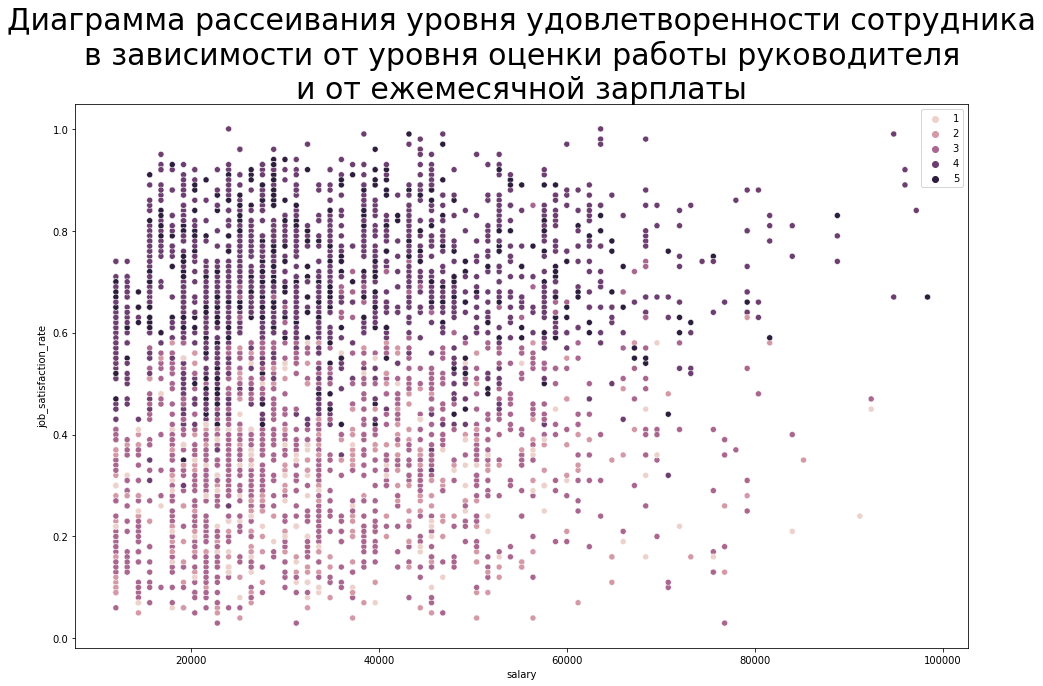

In [ ]:
# диаграмма рассеяния, вариант 1
plt.figure(figsize=(16,10))

sns.scatterplot(data=train_job_satisfaction_rate, hue='supervisor_evaluation', x='salary', y='job_satisfaction_rate')
plt.legend(loc='best')
plt.title('Диаграмма рассеивания уровня удовлетворенности сотрудника\n\
в зависимости от уровня оценки работы руководителя\n\
и от ежемесячной зарплаты', fontsize=30)

plt.show()

Сотрудники, которых руководитель оценивает более высоко, в целом больше удовлетворены работой. Однако на оплате труда оценка руководителя похоже не сказывается.

##### Корреляционный анализ

Самый наглядный способ увидеть всю корреляцию сразу - построить матрицу корреляции.

Для начала используем ранговую корреляция Спирмена, которая является подходящей для порядковых или непрерывных данных, которые нарушают предположения о корреляции Пирсона.

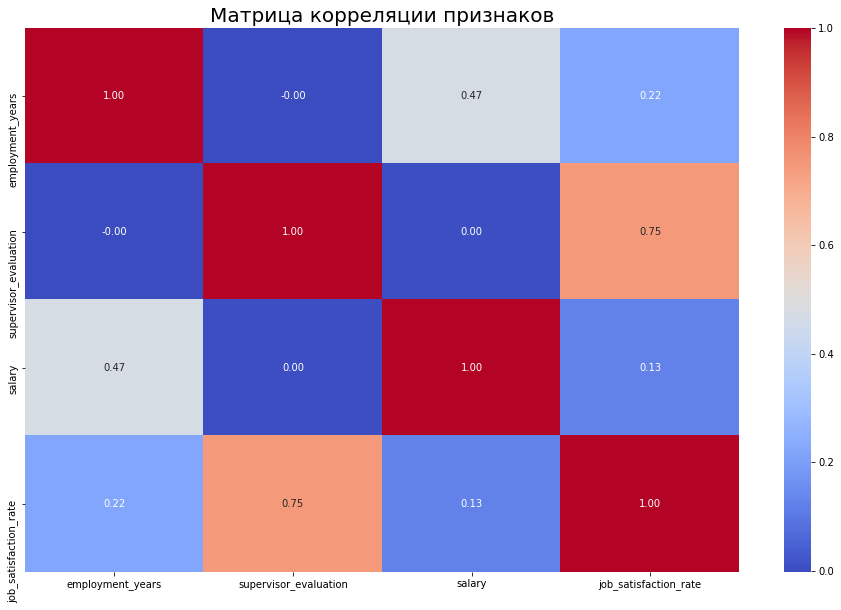

In [ ]:
# матрица корреляции 1
plt.figure(figsize=(16,10))

sns.heatmap(train_job_satisfaction_rate.drop('id', axis=1).corr(method='spearman'), annot=True, fmt='.2f', cmap='coolwarm');

plt.title('Матрица корреляции признаков', fontsize=20)

plt.show()

Самый высокий коэфициент корреляции (0.75) оказался между целевым признаком (уровень удовлетворенности сотрудника работой) и оценкой качества работы, которую дал руководитель. Данный коэфициент недостаточно высок, чтобы говорить о мультиколлениарности.

При этом уровень зарплата показывает с целевым признаком умеренную теснотусвязи.

Однако в матрицу попали только числовые признаки, а нам надо учесть и категориальные.

In [ ]:
train_job_satisfaction_rate.columns # вспоминаем название столбцов

Index(['id', 'dept', 'level', 'workload', 'employment_years',
       'last_year_promo', 'last_year_violations', 'supervisor_evaluation',
       'salary', 'job_satisfaction_rate'],
      dtype='object')

In [ ]:
# неприрывные значения - ошибочное
#interval_cols = ['employment_years', 'supervisor_evaluation', 'salary', 'job_satisfaction_rate']

In [ ]:
# неприрывные значения - исправленное
interval_cols = ['salary', 'job_satisfaction_rate']

In [ ]:
# считаем корреляции
phik_overview = train_job_satisfaction_rate.drop('id', axis=1).phik_matrix(interval_cols=interval_cols)

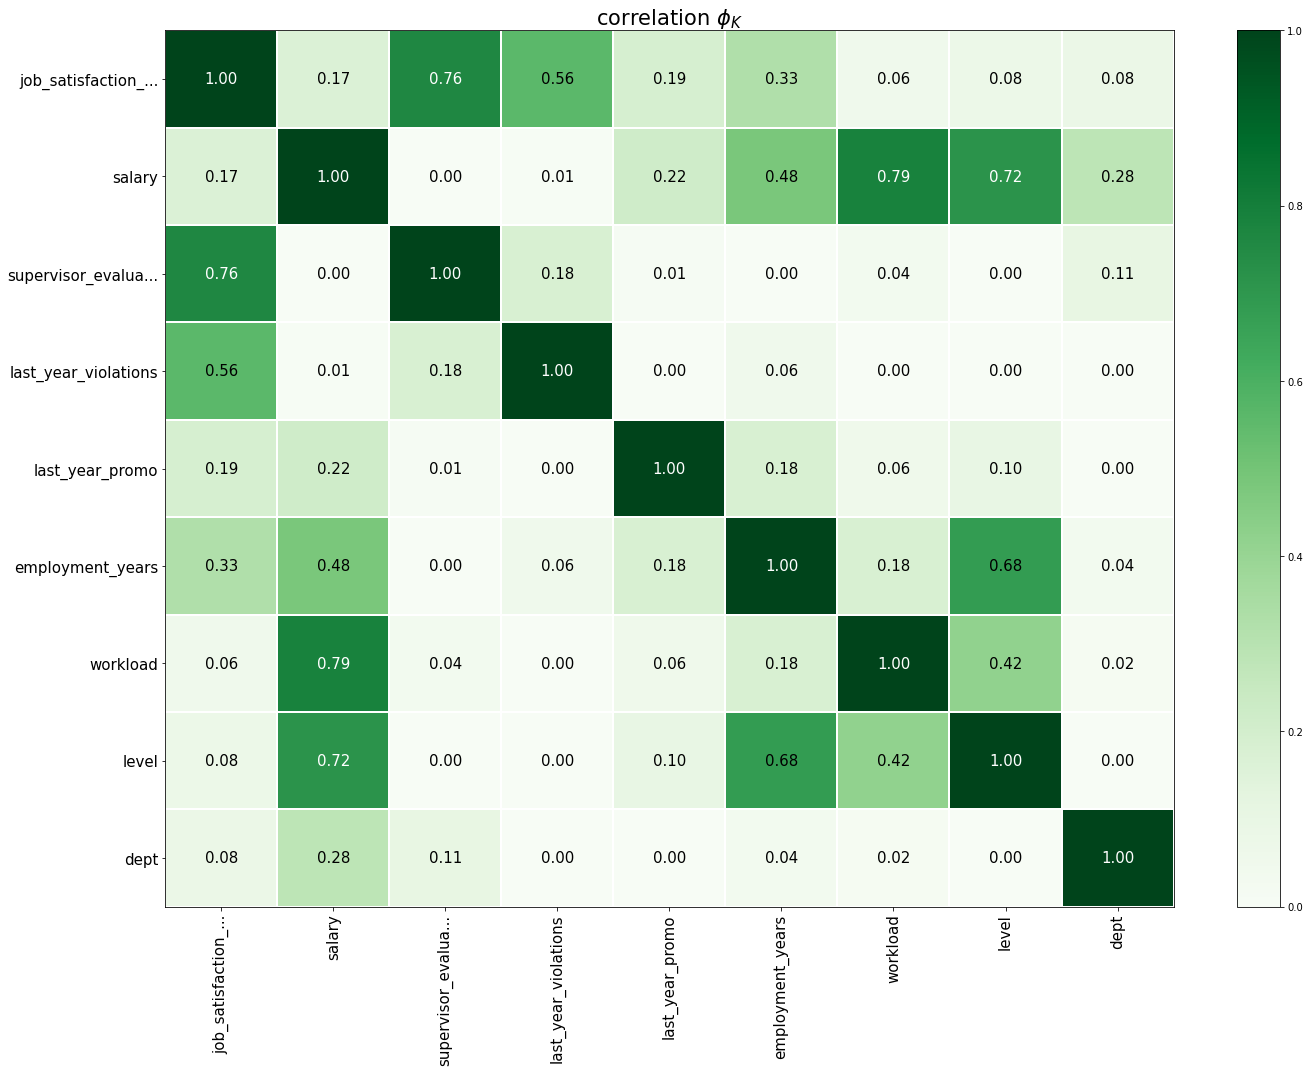

In [ ]:
# матрица корреляции 2
plot_correlation_matrix(
    phik_overview.values,
    x_labels=phik_overview.columns,
    y_labels=phik_overview.index,
    vmin=0, vmax=1, color_map='Greens',
    title=r'correlation $\phi_K$',
    fontsize_factor=1.5,
    figsize=(20, 15)
)

Наибольший коэфициент корреляции (0.79) мы получили между ежемесячной зарплатой (`'salary'`) и уровнем загруженности сотрудника (`workload`), то есть в компании ценят затрачиваемые сотрудником усилия. Но такого коэфициента также недостаточно для мультиколлениарности. Также высокую тесноту связи (коэфициент корреляции 0.72) зарплата проявила с уровнем должности (`'level'`).

С целевым признаком "уровень удовлетворенности работой"(`'job_satisfaction_rate'`) высокую тесноту связи показал оценка работника руководителем (`'supervisor_evaluation'`, коэфициент корреляции 0.76), заметную - наличие нарушений за последний год (`'last_year_violations'`, 0.56), умеренную - длительность работы в компании (`'employment_years'`, 0.33), слабую - наличие повышения за последний год (`'last_year_promo'`, 0.19) и среднемесячная зарплата (` 'salary'`, 0.17).

Остальные признаки не выявили связи с целевым, но имеют связи с частью других. Поэтому удалять их (по крайней мере, самостоятельно) не будем.

***Выводы***

Проанализировав датасет с тренировочными данными `'train_job_satisfaction_rate'` мы обнаружили, что:

- В рамках своих столбцов данные находятся в одних порядках и большинство из них имеют неширокий "диапазон значений". Однако порядки друг относительно друга у них отличаются: что-то в единицах (`'employment_years'`, `'supervisor_evaluation'`), что-то - в долях единицы (`'job_satisfaction_rate'`), что-то и вовсе в тысячах (`'salary'`). То есть данные требуют стандартизации для последующей работы модели.

- Для параметра `'employment_years'` среднее и медиана не слишком близки, что вместе с большим стандартным отклонением говорит о неравномерности выборки. Максимальная длительность работы сотрудниками компании составил 10 лет, минимальная - 1 год. Нормальными значениями можно считать от 2 до 6. Распределение в выборке не является нормальным: сотрудников с большим стажем меньше, чем с меньшим. Либо сотрудники сотрудники чаще предпочитают увольняться после определенного времени работы, либо переодически происходит расширение штата и набор новых сотрудников, либо все вместе.

- Для параметра `'supervisor_evaluation'` среднее и медиана не слишком близки, что вместе с большим стандартным отклонением говорит о неравномерности выборки. Максимальная оценка качества работы сотрудника от руководителя составила 5, минимальная - 1. Нормальными значениями можно считать от 3 до 4. Распределение стремится к нормальному. Привлекают внимание работники, получившие единицу, которые после дополнительного изучения признаны настоящими данными (при этом указанные работники также не очень удовлетворены своей работой), которые мы не можем исключить из исследования чтобы не пострадало качество работы модели (тем более, что эта группа "наиболее уязвима" ввиду низкой удовлетворенности).

- Для параметра `'salary'` среднее и медиана относительно близки, однако большое стандартное отклонение говорит о неравномерности выборки. Максимальная зарплата в компании составила 98400 неизвестных единиц, минимальная - 12000 (то есть разница более чем в 8 раз!). Нормальными значениями можно считать от 22800 до 43200 неизвестных единиц. Распределение стремится к нормальному со смещением влево и хвостом справа. Диаграмма размаха демонтрирует ряд выбросов после приблизительно 77000 неизвестных единиц, которые после дополнительного изучения были признаны настоящими (принадлежащими топовым работникам (сотрудники на высоких должностях и высокой нагрузкой - то есть их столь высокая зарплата вполне объяснима) компании). Мы также не можем их исключать из исследования, чтобы модель научилась делать правильные прогнозы для всех работников. Тем более, что уровни удовлетворенности у них более разнообразный, чем у работников с низкой оценколй от руководитьеля: есть и с высоким, и с низким уровнем (а низкий уровень удовлетворенности подобного высококлассного специалиста может быть вреден для компании).

- Для целевого признака `'job_satisfaction_rate'` среднее и медиана достаточно близки. А вот большое стандартное отклонением говорит о неравномерности выборки. Максимальная доля удовлетворенности сотрудника работой 1, минимальная - 0.3. Нормальными значениями можно считать от 0.36 до 0.71. Низкий уровень нижней границы "нормальности" является не очень хорошим знаком для компании. Гистограмма стремится к нормальности, однако имеет два пика (мультимодальное распределение), но так это - целевой признак, как мы не можем просто разбить его на две категории (до 0.5 и выше 0.5) для использования в модели ввиду того, что заказчика наверняка волнуют более точные значения. Поэтому в случае низкого качества метрик полученной модели придется придумать что-то еще. Выбросов на диаграмме не выявлено.

- Распределение параметра `'dept'`: больше всего сотрудников занято в продажах ("sales", 1е место с отрывом), технологиях ("technology", 2е), меньше - в закупках("purchasing"), маркетинге и кадрах("hr").

- Распределение параметра `'level'`: доли сотрудников уровня "junior" и "middle" относительно близки (но первых все-таки больше), а вот "sinior" ожидаемо гораздо меньше.

- Распределение параметра `'workload'`: средний уровень нагрузки занимает самую большую долю (что логично), а тяжелый - меньше всех.

- Распределение параметра `'last_year_promo'`: повышения выдают не так часто: лишь 3% сотрудников получили его за последний год. Это выглядит логичным: достойных сотрудников может быть много, а свободных вакансий - мало.

- Распределение параметра `'last_year_violations'`: 14% сотрудников имели нарушения за прошлый год (по крайней мере, заффиксированные. Мы не знаем, сколько их было у каждого из нарушивших, и были ли какие-то упущены и не зафиксированы). С одной стороны - выглядит кажется немного. А с другой - каждый 7й сотрудний является нарушителем! Все-таки лучше выяснить, в чем именно состоят эти нарушения: опоздания ли это из-за нарушающего расписания автобуса или непредвиденных погодных условий, нежелание следовать дресс-коду, разовая неявка на частые совещания или что-то еще? И ввиду этого следует пересмотреть внутренний регламент, сделать его более гибким и комфортным не в ущерб рабочему процессу?

Изучение диаграммы рассеивания для данного датасета выявило, что:

- В целом уровень удовлетворенности не зависит от отдела.

- Видна корреляция: чем выше уровень должности - тем выше зарплата. А вот на уровень удовлетворенности должность похоже не оказывает заметного влияния.

- Также видна тенденция (пусть и с некоторыми исключениями): выше нагрузка - выше оплата.

- Зависимость уровня удовлетворенности от длительности работы в компании не обнаружена.

- Четких зависимостей уровня удовлетворенности сотрудника от уровня длительности работы в компании и ежемесячной зарплаты не выявлено.

- Обнаружено, что чем меньше стаж - тем ниже уровень должности.

- Те, кто получали повышения, несколько более удовлетворены своей работой чем те, кто не получал.

- Те, кто нарушал, менее удовлетворены чем те, кто нет, что логично. Нарушители повышения не получали.

- Сотрудники, которых руководитель оценивает более высоко, в целом больше удовлетворены работой. Однако на оплате труда оценка руководителя похоже не сказывается.

Проведение корреляционного анализа с помощью матрицы phik выявило, что:

- Наибольший коэфициент корреляции (0.79) мы получили между ежемесячной зарплатой (`'salary'`) и уровнем загруженности сотрудника (`workload`), то есть в компfнии ценят затрачиваемые сотрудником усилия. Но такого коэфициента также недостаточно для мультиколлениарности. Также высокую тесноту связи (коэфициент корреляции 0.72) зарплата проявила с уровнем должности (`'level'`).

- С целевым признаком "уровень удовлетворенности работой"(`'job_satisfaction_rate'`) высокую тесноту связи показал оценка работника руководителем (`'supervisor_evaluation'`, коэфициент корреляции 0.76), заметную - наличие нарушений за последний год (`'last_year_violations'`, 0.56), умеренную - длительность работы в компании (`'employment_years'`, 0.33), слабую - наличие повышения за последний год (`'last_year_promo'`, 0.19) и среднемесячная зарплата (` 'salary'`, 0.17).

- Остальные признаки не выявили связи с целевым, но имеют связи с частью других. Поэтому удалять их (по крайней мере, самостоятельно) не будем.

#### `'test_features'`

##### Числовые данные

Для начала взглянем на числовые данные датасета с тестовой выборкой, чтобы сразу обнаружить яркую аномалию. А также сравнить данные (их порядки) между собой.

In [ ]:
test_features.drop(['id'], axis = 1).describe() # общее описание

,employment_years,supervisor_evaluation,salary
count,2000.000000,2000.000000,2000.000000
mean,3.666500,3.526500,34066.800000
std,2.537222,0.996892,15398.436729
min,1.000000,1.000000,12000.000000
25%,1.000000,3.000000,22800.000000
50%,3.000000,4.000000,30000.000000
75%,6.000000,4.000000,43200.000000
max,10.000000,5.000000,96000.000000


Числовые данные также как и в тренировочном датасете измеряются разными порядками и также требуют стандартизации. Ярких аномалий на данном этапе не наблюдается.

Посмотрим теперь каждый столбец в отдельности сравним его с аналогичным у тренировочных данных.

In [ ]:
# длительность работы в компании
test_features['employment_years'].describe() # общее описание

count    2000.000000
mean        3.666500
std         2.537222
min         1.000000
25%         1.000000
50%         3.000000
75%         6.000000
max        10.000000
Name: employment_years, dtype: float64

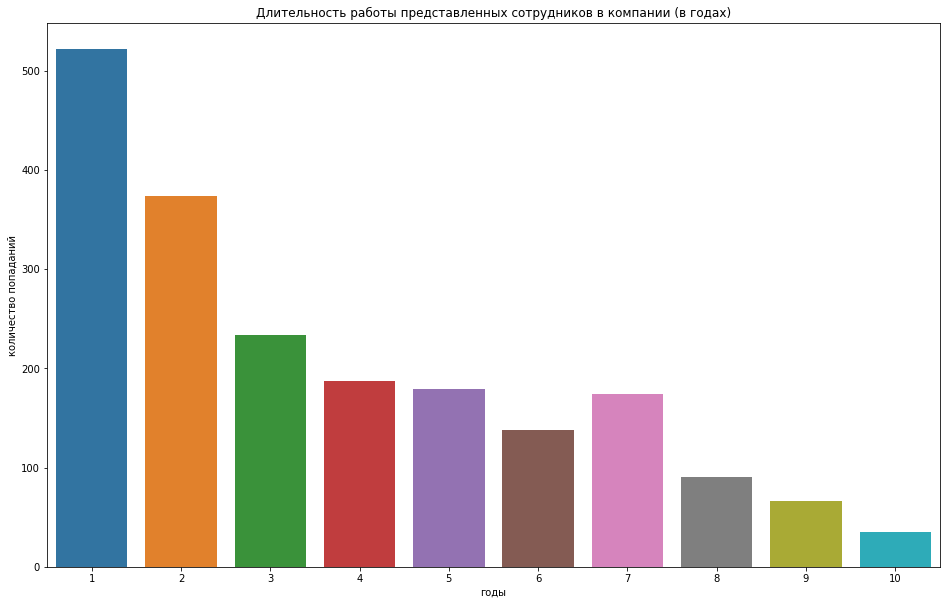

In [ ]:
# график для дискретного признака (на каждое уникальные значение признака строит свою корзину)
plt.figure(figsize=(16,10))

sns.countplot(x=test_features['employment_years'])

plt.title('Длительность работы представленных сотрудников в компании (в годах)')
plt.xlabel('годы')
plt.ylabel('количество попаданий')

plt.show()

In [ ]:
# оценка качества работы сотрудника от руководителя
test_features['supervisor_evaluation'].describe() # общее описание

count    2000.000000
mean        3.526500
std         0.996892
min         1.000000
25%         3.000000
50%         4.000000
75%         4.000000
max         5.000000
Name: supervisor_evaluation, dtype: float64

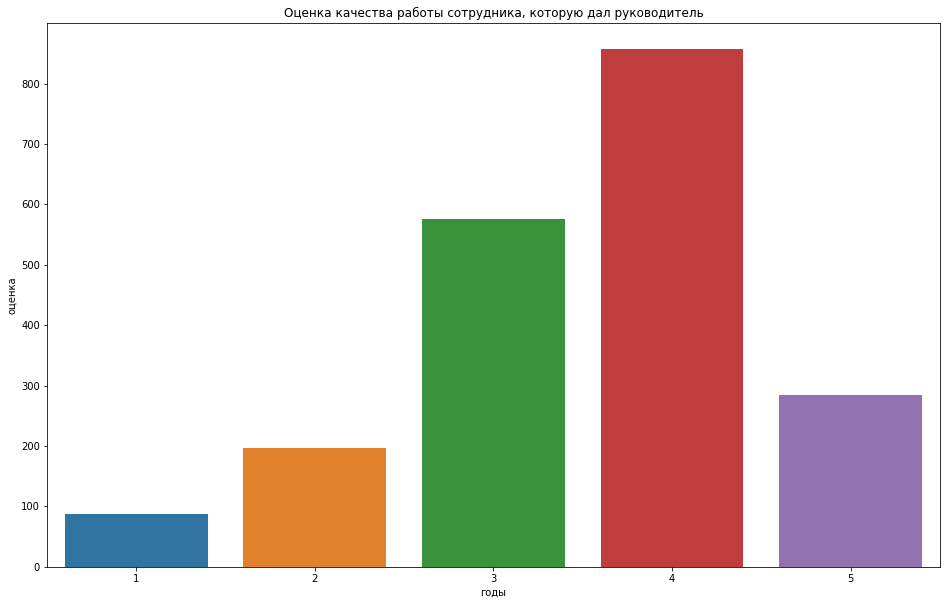

In [ ]:
# график для дискретного признака (на каждое уникальные значение признака строит свою корзину)
plt.figure(figsize=(16,10))

sns.countplot(x=test_features['supervisor_evaluation'])

plt.title('Оценка качества работы сотрудника, которую дал руководитель')
plt.xlabel('годы')
plt.ylabel('оценка')

plt.show()

In [ ]:
# зарплата сотрудника
test_features['salary'].describe() # общее описание

count     2000.000000
mean     34066.800000
std      15398.436729
min      12000.000000
25%      22800.000000
50%      30000.000000
75%      43200.000000
max      96000.000000
Name: salary, dtype: float64

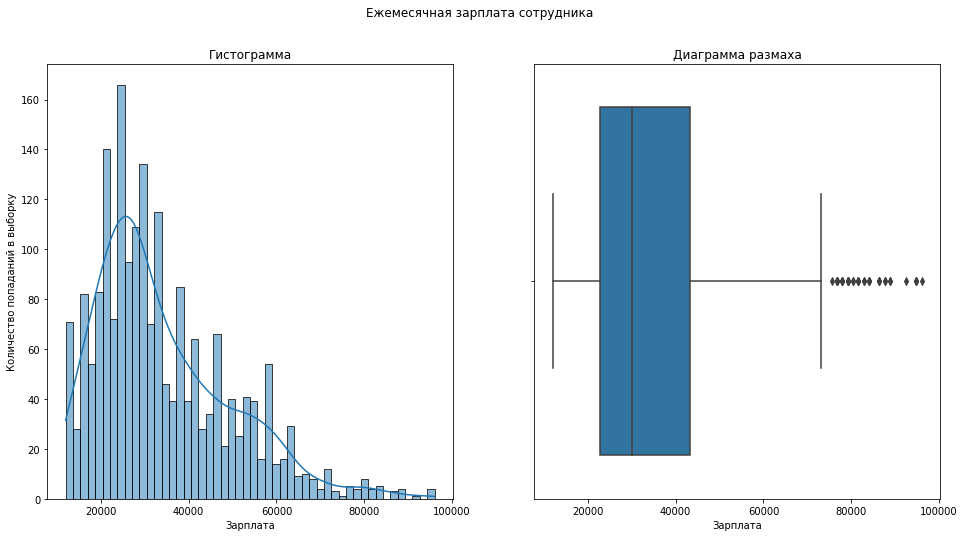

In [ ]:
# зарплата сотрудника, диаграмма размаха и гистограмма
fig, axs = plt.subplots(nrows= 1 , ncols= 2, figsize = (16,8))
sns.histplot(data = test_features, x = 'salary', ax=axs[0], bins = 50, kde=True)
axs[0].set_xlabel('Зарплата')
axs[0].set_ylabel('Количество попаданий в выборку')
axs[0].set_title('Гистограмма')
sns.boxplot(data = test_features, x = 'salary', ax=axs[1])
axs[1].set_xlabel('Зарплата')
axs[1].set_title('Диаграмма размаха')
fig.suptitle('Ежемесячная зарплата сотрудника')
plt.show()

Распределение числовых признаков тестовых данных очень близко к таковым у тренировочных (и аномалии в тех же местах присутсутствуют).

Перейдем к категориальным данным.

##### Категориальные данные

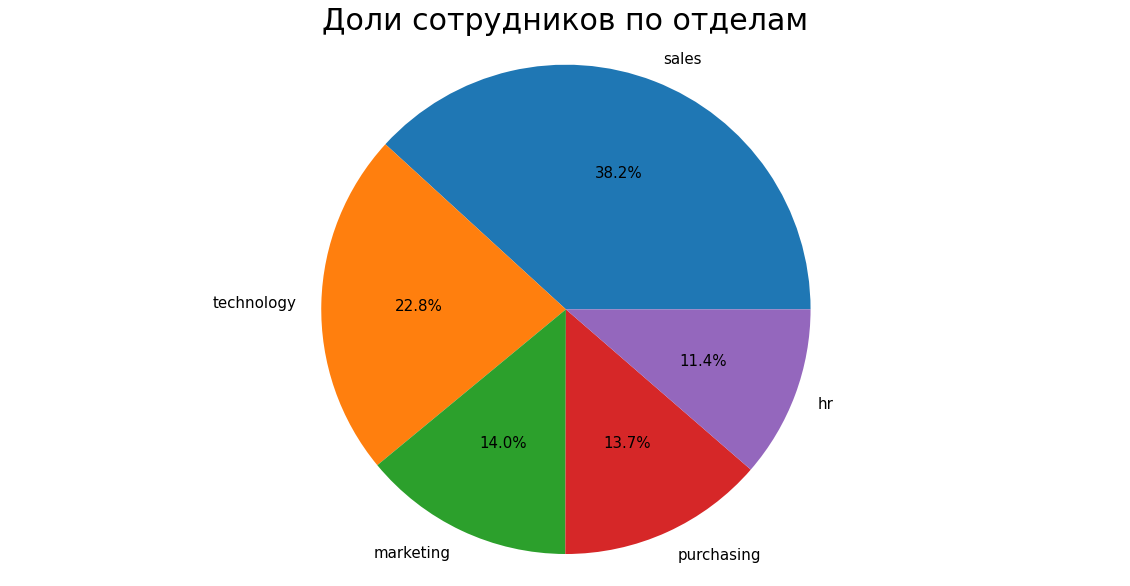

In [ ]:
# визуализируем отделы
test_features['dept'].value_counts().plot(kind = 'pie', grid = True,\
                                     figsize = (20,10), fontsize=15, autopct='%1.1f%%')

plt.title('Доли сотрудников по отделам', fontsize=30)
plt.axis('equal')
plt.ylabel('', fontsize=13)

plt.show()

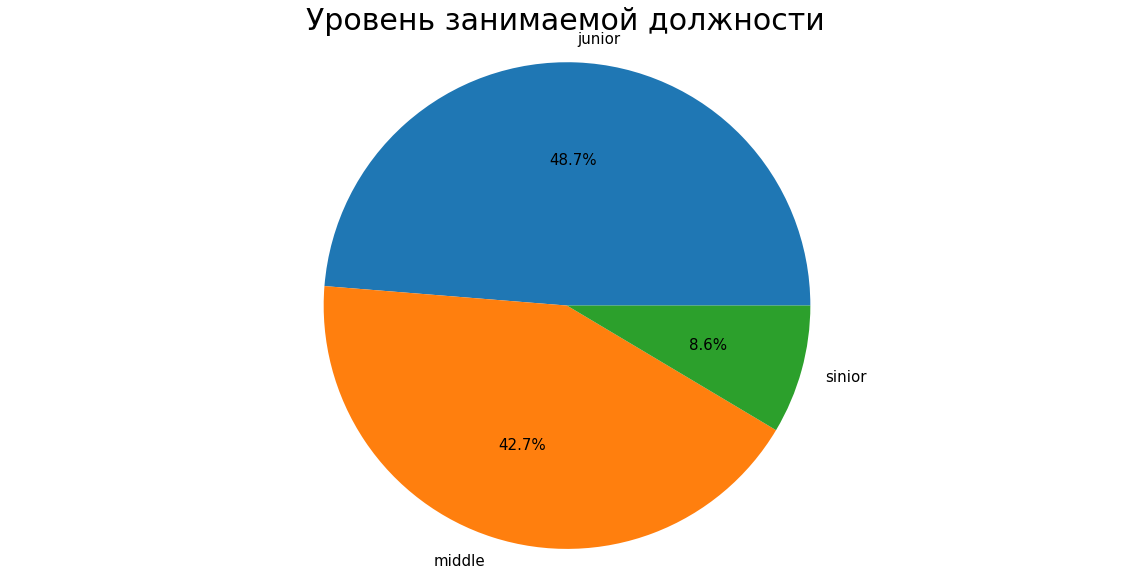

In [ ]:
# визуализируем должности
test_features['level'].value_counts().plot(kind = 'pie', grid = True,\
                                     figsize = (20,10), fontsize=15, autopct='%1.1f%%')

plt.title('Уровень занимаемой должности', fontsize=30)
plt.axis('equal')
plt.ylabel('', fontsize=13)

plt.show()

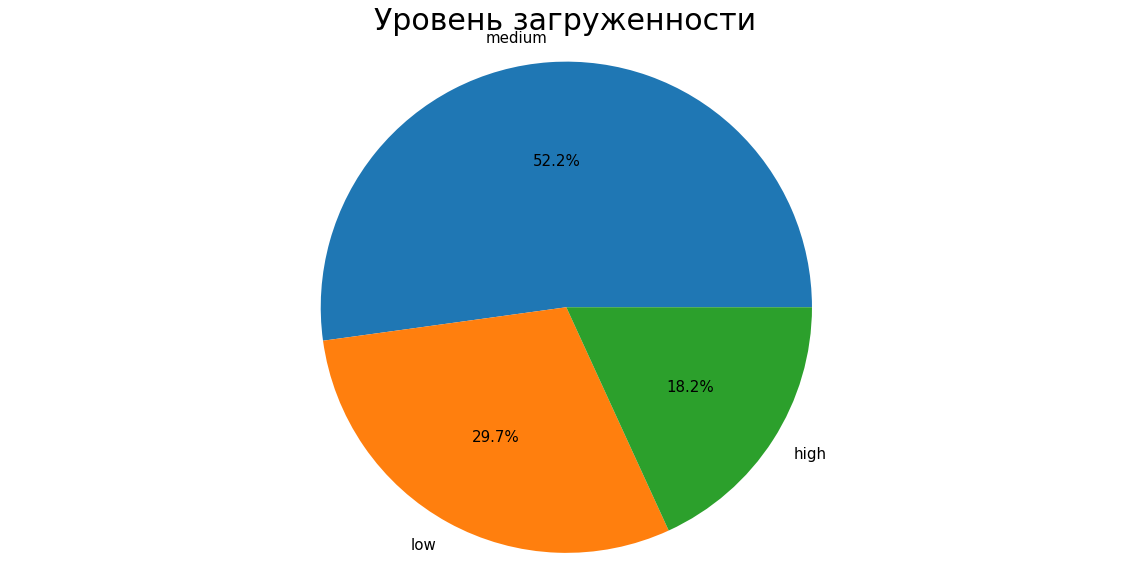

In [ ]:
# визуализируем уровень загруженности
test_features['workload'].value_counts().plot(kind = 'pie', grid = True,\
                                     figsize = (20,10), fontsize=15, autopct='%1.1f%%')

plt.title('Уровень загруженности', fontsize=30)
plt.axis('equal')
plt.ylabel('', fontsize=13)

plt.show()

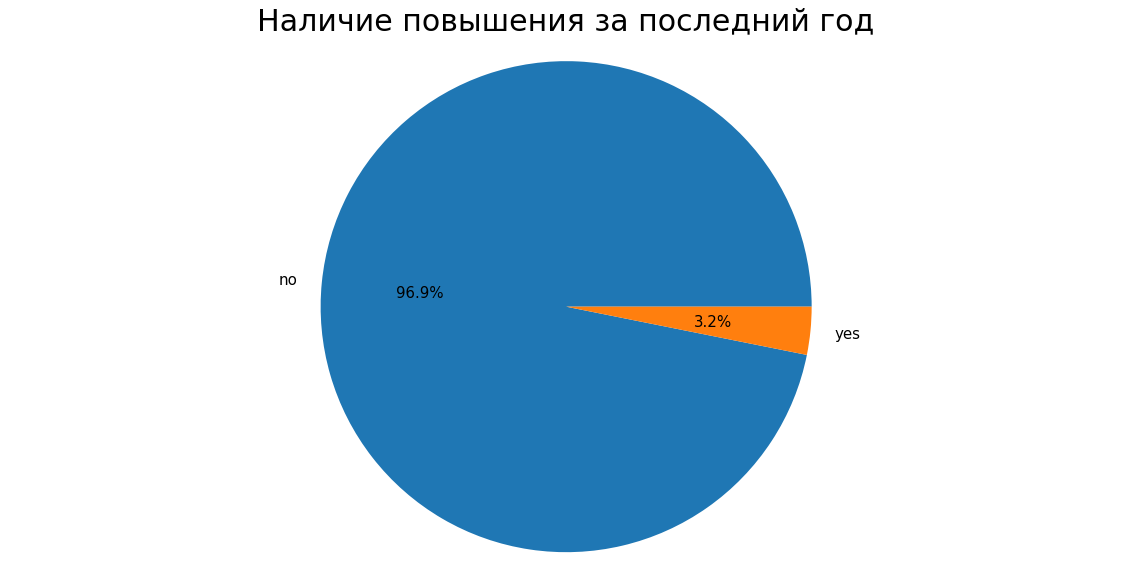

In [ ]:
# визуализируем повышения
test_features['last_year_promo'].value_counts().plot(kind = 'pie', grid = True,\
                                     figsize = (20,10), fontsize=15, autopct='%1.1f%%')

plt.title('Наличие повышения за последний год', fontsize=30)
plt.axis('equal')
plt.ylabel('', fontsize=13)

plt.show()

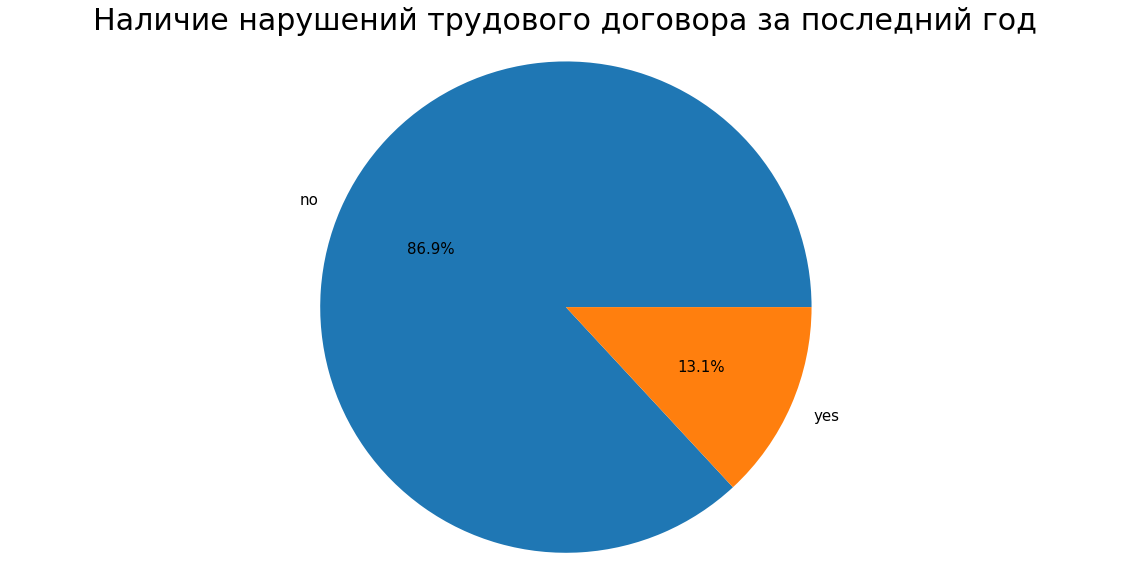

In [ ]:
# визуализируем повышения
test_features['last_year_violations'].value_counts().plot(kind = 'pie', grid = True,\
                                     figsize = (20,10), fontsize=15, autopct='%1.1f%%')

plt.title('Наличие нарушений трудового договора за последний год', fontsize=30)
plt.axis('equal')
plt.ylabel('', fontsize=13)

plt.show()

Распределение данных категориальных столбцов у тестовой выборки также очень близко к таковым у тренировочной. Что говорит о высоком качестве разбиения на выборки.

Взглянем также на целевой признак тренировочной выборки.

#### `'test_target_job_satisfaction_rate'`

Единственное, на что мы можем взглянуть - статистическое описание целевого признака, и также сравнить с его характеристиками у тренировочной выборки.

In [ ]:
# доля удовлетворенности
test_target_job_satisfaction_rate['job_satisfaction_rate'].describe() # общее описание

count    2000.00000
mean        0.54878
std         0.22011
min         0.03000
25%         0.38000
50%         0.58000
75%         0.72000
max         1.00000
Name: job_satisfaction_rate, dtype: float64

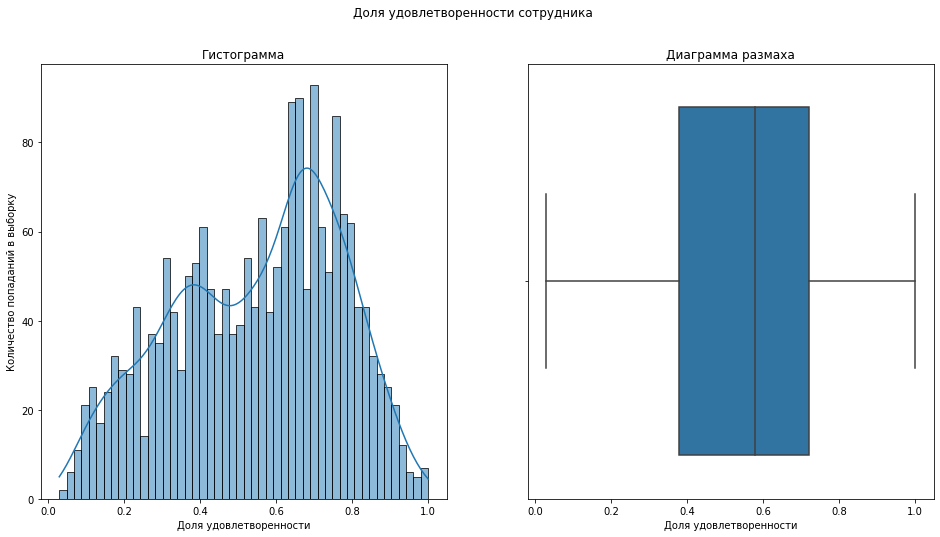

In [ ]:
# доля удовлетворенности, диаграмма размаха и гистограмма
fig, axs = plt.subplots(nrows= 1 , ncols= 2, figsize = (16,8))
sns.histplot(data = test_target_job_satisfaction_rate, x = 'job_satisfaction_rate', ax=axs[0], bins = 50, kde=True)
axs[0].set_xlabel('Доля удовлетворенности')
axs[0].set_ylabel('Количество попаданий в выборку')
axs[0].set_title('Гистограмма')
sns.boxplot(data = test_target_job_satisfaction_rate, x = 'job_satisfaction_rate', ax=axs[1])
axs[1].set_xlabel('Доля удовлетворенности')
axs[1].set_title('Диаграмма размаха')
fig.suptitle('Доля удовлетворенности сотрудника')
plt.show()

Распределение целевого признака в тестовых данных очень близко к таковому у тренировочных, что еще раз говорит о хорошем качестве разбиения на выборки.

***Выводы***

Распределение признаков в тестовых данных очень близко к таковым у тренировочных, что говорит о высоком качестве разбиения на выборки.

**Выводы**

1. Данные числовых признаков (в том числе и целевой) полученных датасетов измеряются в разных порядках (единицы, тысячи, доли единицы), поэтому им требуется дальнейшая стандартизация для работы с моделью.

2. Часть категориальных данных являются ранговыми, что требует использования нескольких типов кодировщиков в зависимости от типа категории параметра.

3. Изучение числовых признаков датасета с тренировочными данными выявило аномальные значения некоторых параметров, которые оказались настоящими данными (причем, важных групп), которые мы не можем исключить из исследования без потери качества работы модели.

4. Распределение признаков в тестовых данных очень близко к таковым у тренировочных, что говорит о высоком качестве разбиения на выборки.

5. Проведение корреляционного анализа с помощью матрицы phik выявило, что:

- Наибольший коэфициент корреляции (0.79) мы получили между ежемесячной зарплатой (`'salary'`) и уровнем загруженности сотрудника (`workload`), то есть в компfнии ценят затрачиваемые сотрудником усилия. Но такого коэфициента также недостаточно для мультиколлениарности. Также высокую тесноту связи (коэфициент корреляции 0.72) зарплата проявила с уровнем должности (`'level'`).

- С целевым признаком "уровень удовлетворенности работой"(`'job_satisfaction_rate'`) высокую тесноту связи показал оценка работника руководителем (`'supervisor_evaluation'`, коэфициент корреляции 0.76), заметную - наличие нарушений за последний год (`'last_year_violations'`, 0.56), умеренную - длительность работы в компании (`'employment_years'`, 0.33), слабую - наличие повышения за последний год (`'last_year_promo'`, 0.19) и среднемесячная зарплата (` 'salary'`, 0.17).

- Остальные признаки не выявили связи с целевым, но имеют связи с частью других. Поэтому удалять их (по крайней мере, самостоятельно) не будем.

### Подготовка данных

Прежде чем работать непосредственно с моделью, необходимо подготовить данные.

#### Объединение и разбиение

Для начала объединим датасеты с данными тренировочной выборки, чтобы порядок сотрудников при работе модели в X_test и y_test был одинаков. К тому же полученный таким образом датасет может нам еще пригодиться в будущем.

In [ ]:
data_test_first = test_features.merge(test_target_job_satisfaction_rate, on='id', how='inner') # объединение

In [ ]:
data_test_first.head() # проверка 1

,id,dept,level,workload,employment_years,last_year_promo,last_year_violations,supervisor_evaluation,salary,job_satisfaction_rate
0,485046,marketing,junior,medium,2,no,no,5,28800,0.79
1,686555,hr,junior,medium,1,no,no,4,30000,0.72
2,467458,sales,middle,low,5,no,no,4,19200,0.64
3,418655,sales,middle,low,6,no,no,4,19200,0.60
4,789145,hr,middle,medium,5,no,no,5,40800,0.75


In [ ]:
data_test_first.info() # проверка 2

<class 'pandas.core.frame.DataFrame'>
Int64Index: 2000 entries, 0 to 1999
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   id                     2000 non-null   int64  
 1   dept                   1997 non-null   object 
 2   level                  1999 non-null   object 
 3   workload               1999 non-null   object 
 4   employment_years       2000 non-null   int64  
 5   last_year_promo        2000 non-null   object 
 6   last_year_violations   2000 non-null   object 
 7   supervisor_evaluation  2000 non-null   int64  
 8   salary                 2000 non-null   int64  
 9   job_satisfaction_rate  2000 non-null   float64
dtypes: float64(1), int64(4), object(5)
memory usage: 171.9+ KB


Объединение прошло успешно.

Теперь разобъем наши датасеты на группы данных для работы с моделью.

In [ ]:
target_lev = 'job_satisfaction_rate' # задаем целевой признак

In [ ]:
# отделяем параметры тренировочных данных
X_train_first = train_job_satisfaction_rate.drop(['id', target_lev], axis=1)

In [ ]:
X_train_first.head() # проверка

,dept,level,workload,employment_years,last_year_promo,last_year_violations,supervisor_evaluation,salary
0,sales,junior,medium,2,no,no,1,24000
1,hr,junior,high,2,no,no,5,38400
2,sales,junior,low,1,no,no,2,12000
3,technology,junior,low,4,no,no,2,18000
4,hr,junior,medium,1,no,no,3,22800


In [ ]:
# отделяем целевой признак тренировочных данных
y_train_first = train_job_satisfaction_rate[target_lev]

In [ ]:
y_train_first.head() # проверка

0    0.58
1    0.76
2    0.11
3    0.37
4    0.20
Name: job_satisfaction_rate, dtype: float64

In [ ]:
# отделяем параметры тестовых данных
X_test_first = data_test_first.drop(['id', target_lev], axis=1)

In [ ]:
X_test_first.head() # проверка

,dept,level,workload,employment_years,last_year_promo,last_year_violations,supervisor_evaluation,salary
0,marketing,junior,medium,2,no,no,5,28800
1,hr,junior,medium,1,no,no,4,30000
2,sales,middle,low,5,no,no,4,19200
3,sales,middle,low,6,no,no,4,19200
4,hr,middle,medium,5,no,no,5,40800


In [ ]:
# отделяем целевой признак тестовых данных
y_test_first = data_test_first[target_lev]

In [ ]:
y_test_first.head() # проверка

0    0.79
1    0.72
2    0.64
3    0.60
4    0.75
Name: job_satisfaction_rate, dtype: float64

Разбиение данных прошло успешно. Можно переходить к преобразованиям.

#### Преобразование данных: начало

Прежде чем передать данные модели на обучение, их необходимо подготовить. Чтобы облегчить себе задачу, подготавливать их будем с помощью пайплайна.

Для начала составим списки параметров.

In [ ]:
# кодирование, номинальные
ohe_columns = [
    'dept',
    'last_year_promo',
    'last_year_violations'
    ]

In [ ]:
# кодирование, порядковые
ord_columns = [
    'level',
    'workload'
    ]

In [ ]:
# масштабирование, числовые
num_columns = [
    'employment_years',
    'supervisor_evaluation',
    'salary'
    ]

Теперь можно приступать к сбору пайплайна для подготовки данных.

Сначала добавляем  в пайплайн OHE-кодирование, не забывая о наших ранее выявленных пропусках.

In [ ]:
# SimpleImputer + OHE
ohe_pipe = Pipeline(
    [
        # Если в данных есть пропуски, заполним их самым часто встречающимся значением с помощью SimpleImputer
        (
            'simpleImputer_ohe',
            SimpleImputer(missing_values=np.nan, strategy='most_frequent')
        ),
        # Кодируем данные с помощью OneHotEncoder, избегая дамми-ловушки, игнорируя неизвестные значения,
        # и чтобы результаты кодирования можно было визуально увидеть - не сохраняем его в sparce-формате
        (
            'ohe',
            OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False) # _output для версии sklearn 1.5.2
        )
    ]
)

Аналогично добавляем Ordinal-кодирование в пайплайн.

In [ ]:
# SimpleImputer + ORD + SimpleImputer

'''
При порядковом кодировании необходимо задать порядок категоризации.
Поэтому в параметре categories последовательно перечислим
уровни категорий для каждого признака из списка ord_columns
'''

ord_pipe = Pipeline(
    [
        # Заполним пропуски самым часто встречающимся значением с помощью SimpleImputer
        (
            'simpleImputer_before_ord',
            SimpleImputer(missing_values=np.nan, strategy='most_frequent')
        ),
        # Проводим Ordinal-кодирование с помощью OrdinalEncoder
        (
            'ord',
            OrdinalEncoder(
                categories=[
                    # перечисляем от меньшего к большему
                    ['junior', 'middle', 'sinior'],
                    ['low', 'medium', 'high']
                ],
                # неизвестные значения превращаем в пропуски
                handle_unknown='use_encoded_value', unknown_value=np.nan
            )
        ),
        # Заполним пропуски, которые появляются после Ordinal-кодирования
        (
            'simpleImputer_after_ord',
            SimpleImputer(missing_values=np.nan, strategy='most_frequent')
        )
    ]
)

Собираем общий пайплайн для подготовки данных.

In [ ]:
# объединяем шаги подготовки, исходный скалер исправили на тот, что лучше себя показал позже
data_preprocessor = ColumnTransformer(
    [
        ('ohe', ohe_pipe, ohe_columns),
        ('ord', ord_pipe, ord_columns),
        ('num', MinMaxScaler(), num_columns) # указываем один скалер из планируемых, далее будем их уточнять
    ],
    remainder='passthrough' # позволяет не трогать данные, не вошедшие в списки выше
)

Заготовки для преобразования данных готовы. Можно переходить к следующему шагу.

### Итоговый пайплайн: подготовка данных и модель: первые попытки

Теперь мы можем собрать итоговый пайплайн, включив туда подготовку данных и использование моделей, а затем (уже отдельно) дополнительно уточнить варианты применяемого к данным масштабирования и варианты моделей и их параметров.

In [ ]:
# создаём итоговый пайплайн: подготовка данных и модель
pipe_final = Pipeline(
    [
        ('preprocessor', data_preprocessor),
        # указываем любую модель из планируемых, так как далее будем их уточнять
        ('models', LinearRegression())
    ]
)

In [ ]:
# создаем список скелеров
skel = [StandardScaler(), MinMaxScaler(), RobustScaler(), 'passthrough']

Для решения задачи регрессии попробуем использовать модели с разной логикой: Линейную регрессию и Дерево решений.

In [ ]:
# описание моделей и их гиперпараметров
param_grid = [
    # словарь для модели DecisionTreeRegressor()
    {
        'models': [DecisionTreeRegressor(random_state=RANDOM_STATE)],
        'models__max_depth': range(2, 10), # максимальная глубина
        'models__min_samples_split': range(2, 10), # минимальное число объектов, при котором они делятся на "ветви"
        'models__max_features': range(2, 8),
        'preprocessor__num': skel
    },

    # словарь для модели LinearRegression()
    {
        'models': [LinearRegression()],
        'preprocessor__num': skel
    },
]

#### Метрика

Для того, чтобы выбрать лучшую модель и проверьте её качество необходимо использовать новую метрики — SMAPE (англ. symmetric mean absolute percentage error, «симметричное среднее абсолютное процентное отклонение», используется для измерения прогностической точности моделей), критерий успеха для нашей задачи согласно указаниям заказчика: SMAPE ≤15 на тестовой выборке.

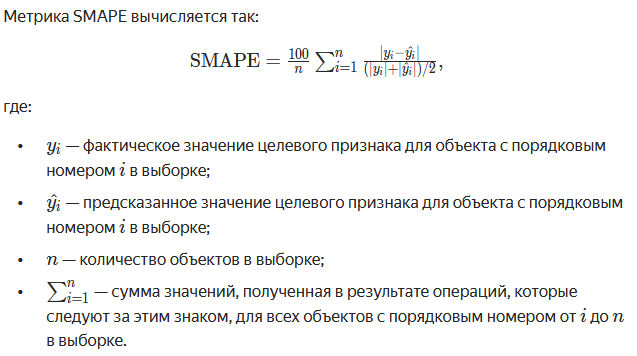

Или упрощенно:

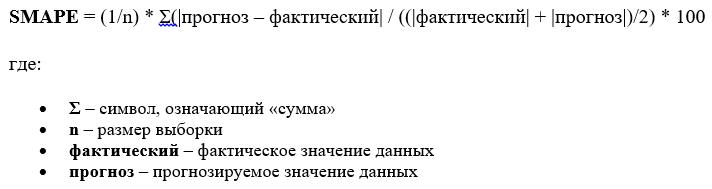

Данной метрики нет в "пакете по умолчанию", а значит предстоит написать функцию для ее вычисления.

In [ ]:
# функция для вычисления SMAPE для массивов NumPy, где:
# y_true - фактические значения,
# y_pred - предсказанные.
# np.abs - вычисление модуль числа, возвращает число с плавающей точкой.

def smape_score(y_true, y_pred):
 return 100/ len (y_true) * np.sum (2 * np.abs (y_pred-y_true) / (np.abs (y_true) + np.abs (y_pred)))

In [ ]:
def smape_score(y_true, y_pred):
    return 100/len(y_true) * np.sum(np.abs(y_true-y_pred)/((np.abs(y_true) + np.abs(y_pred))/2))

smape_scorer = make_scorer(smape_score, greater_is_better = False)

In [ ]:
smape_scorer = make_scorer(smape_score, greater_is_better = False)

Функция метрики подготовлена, можно переходить к обучению моделей.

#### Поиск лучшей модели

Для удобства (возможность использования пайплайна) без особой потери качества (случайный перебор дает хороший результат, хоть не столь идеальный, как по сетке) и увеличения скорости получения результатов (случайный перебор наход ооптимальные параметры быстрее, чем перебор по сетке, а данных у нас много) попробуем использовать RandomizedSearchCV.

In [ ]:
# перебор параметров случайный
randomized_search = RandomizedSearchCV(
    pipe_final,
    param_grid,
    cv=5,
    scoring=smape_scorer,
    random_state=RANDOM_STATE,
    n_iter=50,
    n_jobs=-1
)

In [ ]:
randomized_search.fit(X_train_first, y_train_first) # тренируем модель

RandomizedSearchCV(cv=5,
                   estimator=Pipeline(steps=[('preprocessor',
                                              ColumnTransformer(remainder='passthrough',
                                                                transformers=[('ohe',
                                                                               Pipeline(steps=[('simpleImputer_ohe',
                                                                                                SimpleImputer(strategy='most_frequent')),
                                                                                               ('ohe',
                                                                                                OneHotEncoder(drop='first',
                                                                                                              handle_unknown='ignore',
                                                                                                              sparse_output=False))]),
                                                                               ['dept',
                                                                                'last_year_promo',
                                                                                'last_year_violations']),
                                                                              ('ord',
                                                                               Pip...
                                         'models__max_features': range(2, 8),
                                         'models__min_samples_split': range(2, 10),
                                         'preprocessor__num': [StandardScaler(),
                                                               MinMaxScaler(),
                                                               RobustScaler(),
                                                               'passthrough']},
                                        {'models': [LinearRegression()],
                                         'preprocessor__num': [StandardScaler(),
                                                               MinMaxScaler(),
                                                               RobustScaler(),
                                                               'passthrough']}],
                   random_state=42,
                   scoring=make_scorer(smape_score, greater_is_better=False, response_method='predict'))

In [ ]:
# результаты обучения всех моделей
#pd.set_option('display.max_rows', None) # если захотим увидеть действительно все
pd.DataFrame(randomized_search.cv_results_).sort_values(by='rank_test_score', ascending=True)

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_preprocessor__num,param_models__min_samples_split,param_models__max_features,param_models__max_depth,param_models,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
6,0.026700,0.003074,0.010032,0.001303,MinMaxScaler(),3,7,9,DecisionTreeRegressor(random_state=42),"{'preprocessor__num': MinMaxScaler(), 'models_...",-16.087921,-15.997164,-15.802462,-16.438395,-15.647840,-15.994756,0.269380,1
10,0.025517,0.000499,0.009728,0.000252,RobustScaler(),6,6,9,DecisionTreeRegressor(random_state=42),"{'preprocessor__num': RobustScaler(), 'models_...",-17.756187,-16.433138,-16.745500,-17.036023,-16.408934,-16.875956,0.496315,2
20,0.025149,0.001350,0.009840,0.000276,StandardScaler(),2,7,7,DecisionTreeRegressor(random_state=42),"{'preprocessor__num': StandardScaler(), 'model...",-17.610477,-17.708920,-17.659189,-17.866510,-17.414284,-17.651876,0.146655,3
45,0.020666,0.000377,0.008337,0.000266,passthrough,3,3,9,DecisionTreeRegressor(random_state=42),"{'preprocessor__num': 'passthrough', 'models__...",-18.117681,-17.967948,-17.869437,-18.244680,-18.543484,-18.148646,0.235239,4
7,0.024493,0.000531,0.009433,0.000343,RobustScaler(),9,4,9,DecisionTreeRegressor(random_state=42),"{'preprocessor__num': RobustScaler(), 'models_...",-18.322812,-18.984208,-17.201105,-18.445137,-17.824030,-18.155458,0.603222,5
12,0.027308,0.003472,0.010918,0.002369,RobustScaler(),8,6,7,DecisionTreeRegressor(random_state=42),"{'preprocessor__num': RobustScaler(), 'models_...",-18.985447,-17.403372,-18.116011,-19.171941,-17.768770,-18.289108,0.685496,6
1,0.023099,0.000632,0.009384,0.000201,MinMaxScaler(),9,6,7,DecisionTreeRegressor(random_state=42),"{'preprocessor__num': MinMaxScaler(), 'models_...",-19.133816,-17.521096,-18.347488,-19.111683,-17.771127,-18.377042,0.665290,7
46,0.021158,0.000305,0.008329,0.000337,passthrough,2,6,7,DecisionTreeRegressor(random_state=42),"{'preprocessor__num': 'passthrough', 'models__...",-18.946050,-18.110458,-19.479926,-18.818737,-18.303010,-18.731636,0.486432,8
25,0.023832,0.000484,0.010157,0.001044,StandardScaler(),2,4,8,DecisionTreeRegressor(random_state=42),"{'preprocessor__num': StandardScaler(), 'model...",-18.975774,-18.057496,-19.357816,-18.882794,-18.686436,-18.792063,0.427271,9
14,0.020882,0.000455,0.008670,0.000213,passthrough,2,3,9,DecisionTreeRegressor(random_state=42),"{'preprocessor__num': 'passthrough', 'models__...",-19.373424,-18.435125,-18.917745,-20.382192,-17.890910,-18.999879,0.849215,10


In [ ]:
# лучшая модель и ее параметры
print('Параметры лучшей модели для RandomizedSearchCV():\n', randomized_search.best_estimator_)
# лучшее значение метрики
print('\nМетрика SMAPE лучшей модели на тренировочной выборке:', randomized_search.best_score_*-1)
# метрика на тестовой выборке
print(f'\nМетрика SMAPE на тестовой выборке: {smape_score(y_test_first, randomized_search.predict(X_test_first))}')

Параметры лучшей модели для RandomizedSearchCV():
 Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('ohe',
                                                  Pipeline(steps=[('simpleImputer_ohe',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('ohe',
                                                                   OneHotEncoder(drop='first',
                                                                                 handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['dept', 'last_year_promo',
                                                   'last_year_violations']),
                                                 ('ord',
         

Хорошо, но недостаточно. Попробуем применить перебор по сетке.

In [ ]:
# перебор параметров по сетке
grid = GridSearchCV(
    pipe_final,
    param_grid=param_grid,
    cv=5,
    # задаем метрику
    scoring=smape_scorer,
    n_jobs=-1
)

In [ ]:
grid.fit(X_train_first, y_train_first) # тренируем модель

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(remainder='passthrough',
                                                          transformers=[('ohe',
                                                                         Pipeline(steps=[('simpleImputer_ohe',
                                                                                          SimpleImputer(strategy='most_frequent')),
                                                                                         ('ohe',
                                                                                          OneHotEncoder(drop='first',
                                                                                                        handle_unknown='ignore',
                                                                                                        sparse_output=False))]),
                                                                         ['dept',
                                                                          'last_year_promo',
                                                                          'last_year_violations']),
                                                                        ('ord',
                                                                         Pipeline(...
                          'models__max_features': range(2, 8),
                          'models__min_samples_split': range(2, 10),
                          'preprocessor__num': [StandardScaler(),
                                                MinMaxScaler(), RobustScaler(),
                                                'passthrough']},
                         {'models': [LinearRegression()],
                          'preprocessor__num': [StandardScaler(),
                                                MinMaxScaler(), RobustScaler(),
                                                'passthrough']}],
             scoring=make_scorer(smape_score, greater_is_better=False, response_method='predict'))

In [ ]:
# параметры лучшей модели
print('Параметры лучшей модели для GridSearchCV():\n', grid.best_estimator_)
# лучшее значение метрики
print('\nМетрика SMAPE лучшей модели на тренировочной выборке:', grid.best_score_*-1)
# метрика на тестовой выборке
print(f'\nМетрика SMAPE на тестовой выборке: {smape_score(y_test_first, grid.predict(X_test_first))}')

Параметры лучшей модели для GridSearchCV():
 Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('ohe',
                                                  Pipeline(steps=[('simpleImputer_ohe',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('ohe',
                                                                   OneHotEncoder(drop='first',
                                                                                 handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['dept', 'last_year_promo',
                                                   'last_year_violations']),
                                                 ('ord',
               

In [ ]:
# результаты обучения всех моделей
#pd.set_option('display.max_rows', None) # если захотим увидеть действительно все
pd.DataFrame(grid.cv_results_).sort_values(by='rank_test_score', ascending=True)

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_models,param_models__max_depth,param_models__max_features,param_models__min_samples_split,param_preprocessor__num,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
1511,0.024074,0.002772,0.009324,0.001528,DecisionTreeRegressor(random_state=42),9.0,7.0,3.0,passthrough,{'models': DecisionTreeRegressor(random_state=...,-16.087921,-15.997164,-15.762914,-16.438395,-15.663486,-15.989976,0.271617,1
1509,0.026016,0.002239,0.010501,0.001342,DecisionTreeRegressor(random_state=42),9.0,7.0,3.0,MinMaxScaler(),{'models': DecisionTreeRegressor(random_state=...,-16.087921,-15.997164,-15.802462,-16.438395,-15.647840,-15.994756,0.269380,2
1510,0.026019,0.002295,0.009478,0.000524,DecisionTreeRegressor(random_state=42),9.0,7.0,3.0,RobustScaler(),{'models': DecisionTreeRegressor(random_state=...,-16.044859,-16.025736,-15.838177,-16.422181,-15.688161,-16.003823,0.246686,3
1508,0.027522,0.002294,0.011041,0.001552,DecisionTreeRegressor(random_state=42),9.0,7.0,3.0,StandardScaler(),{'models': DecisionTreeRegressor(random_state=...,-16.087921,-15.997164,-15.868213,-16.427925,-15.657196,-16.007684,0.255125,4
1523,0.024653,0.003191,0.008542,0.000198,DecisionTreeRegressor(random_state=42),9.0,7.0,6.0,passthrough,{'models': DecisionTreeRegressor(random_state=...,-16.165260,-15.440010,-16.135243,-16.956450,-16.407909,-16.220974,0.489127,5
1521,0.031111,0.003893,0.011591,0.001555,DecisionTreeRegressor(random_state=42),9.0,7.0,6.0,MinMaxScaler(),{'models': DecisionTreeRegressor(random_state=...,-16.165260,-15.444200,-16.169077,-16.956450,-16.407909,-16.228579,0.486776,6
1522,0.031886,0.003819,0.012263,0.001142,DecisionTreeRegressor(random_state=42),9.0,7.0,6.0,RobustScaler(),{'models': DecisionTreeRegressor(random_state=...,-16.165260,-15.444200,-16.169077,-16.956450,-16.407909,-16.228579,0.486776,6
1524,0.026878,0.002762,0.010643,0.001091,DecisionTreeRegressor(random_state=42),9.0,7.0,7.0,StandardScaler(),{'models': DecisionTreeRegressor(random_state=...,-16.754957,-16.087092,-16.329506,-16.422621,-15.550050,-16.228845,0.401331,8
1525,0.026322,0.002278,0.010682,0.000975,DecisionTreeRegressor(random_state=42),9.0,7.0,7.0,MinMaxScaler(),{'models': DecisionTreeRegressor(random_state=...,-16.754957,-16.101621,-16.368344,-16.432899,-15.511148,-16.233794,0.416904,9
1527,0.027100,0.005875,0.010569,0.001912,DecisionTreeRegressor(random_state=42),9.0,7.0,7.0,passthrough,{'models': DecisionTreeRegressor(random_state=...,-16.754957,-16.087092,-16.368344,-16.422621,-15.550050,-16.236613,0.403573,10


Стало лишь ненамного лучше. И похоже линейная регрессия нам в любом случае не поможет, а вот с деревом решений можно попробовать эксперементировать дальше.

Чтобы сэкономить время, но при этом оптимизировать процесс перебора, попробуем применить OptunaSearchCV.

Для начала преобразуем наши выборки.

In [ ]:
model = DecisionTreeRegressor(random_state=RANDOM_STATE) # инициализируем модель

In [ ]:
# задаем параметры
param_opt = {
        'max_depth': distributions.IntDistribution(2, 10),
        'min_samples_split': distributions.IntDistribution(1, 10),
        'max_leaf_nodes': distributions.IntDistribution(1, 10)
}

In [ ]:
# перебор параметров с байесовской оптимизацией
oscv = OptunaSearchCV(
    model,
    param_opt,
    scoring=smape_scorer,
    cv=5,
    n_trials=50,
    random_state=RANDOM_STATE
)

/tmp/ipykernel_198/1738132452.py:2: ExperimentalWarning: OptunaSearchCV is experimental (supported from v0.17.0). The interface can change in the future.
  oscv = OptunaSearchCV(


In [ ]:
#oscv.fit(X_train_first, y_train_first)

Не сработало.

Попробуем преобразовать наши данные. Используем тот же пайплайн подготовки, что мы использовали и для других моделей.

In [ ]:
data_preprocessor # смотрим наш пайплайн подготовки

ColumnTransformer(remainder='passthrough',
                  transformers=[('ohe',
                                 Pipeline(steps=[('simpleImputer_ohe',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('ohe',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore',
                                                                sparse_output=False))]),
                                 ['dept', 'last_year_promo',
                                  'last_year_violations']),
                                ('ord',
                                 Pipeline(steps=[('simpleImputer_before_ord',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('ord',
                                                  OrdinalEncoder(categories=[['junior',
                                                                              'middle',
                                                                              'sinior'],
                                                                             ['low',
                                                                              'medium',
                                                                              'high']],
                                                                 handle_unknown='use_encoded_value',
                                                                 unknown_value=nan)),
                                                 ('simpleImputer_after_ord',
                                                  SimpleImputer(strategy='most_frequent'))]),
                                 ['level', 'workload']),
                                ('num', MinMaxScaler(),
                                 ['employment_years', 'supervisor_evaluation',
                                  'salary'])])

По-умолчанию у нас установлен MinMaxScaler(), который и стал скалером-победителем у модели RandomizedSearchCV(). Модель GridSearchCV() вовсе не использовала скалер и ее метрика качества была лишь ненамного лучше той, что была лучшей у случайного перебора. Поэтому, хотя и дерево решений не требует масштабирования, чтобы воспользоваться уже готовым пайплайном, мы вполне можем использовать скалер-победитель случайного перебора.

In [ ]:
# трансформируем с обучением X_train препроцессором
X_train_opt = pd.DataFrame(
    data_preprocessor.fit_transform(X_train_first),
    # вытаскиваем имена столбцов через get_feature_names_out()
    columns=data_preprocessor.transformers_[0][1][1].get_feature_names_out().tolist() + num_columns + ord_columns
)

In [ ]:
X_train_opt.head() # проверка

,x0_marketing,x0_purchasing,x0_sales,x0_technology,x1_yes,x2_yes,employment_years,supervisor_evaluation,salary,level,workload
0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.111111,0.00,0.138889
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,0.111111,1.00,0.305556
2,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.25,0.000000
3,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.333333,0.25,0.069444
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.000000,0.50,0.125000


In [ ]:
# аналогично преобразуем X_test
X_test_opt = pd.DataFrame(
    data_preprocessor.transform(X_test_first),
    columns=data_preprocessor.transformers_[0][1][1].get_feature_names_out().tolist() + num_columns + ord_columns
)

In [ ]:
X_test_opt.head() # проверка

,x0_marketing,x0_purchasing,x0_sales,x0_technology,x1_yes,x2_yes,employment_years,supervisor_evaluation,salary,level,workload
0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.111111,1.00,0.194444
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.000000,0.75,0.208333
2,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.444444,0.75,0.083333
3,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.555556,0.75,0.083333
4,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.444444,1.00,0.333333


In [ ]:
oscv.fit(X_train_opt, y_train_first) # тренируем нашу модель

[I 2024-10-05 20:33:06,412] A new study created in memory with name: no-name-7f215141-6848-4635-8eb3-34bf61f3ab07
/opt/conda/lib/python3.9/site-packages/optuna_integration/sklearn/sklearn.py:384: RuntimeWarning: Mean of empty slice
  trial.set_user_attr("mean_{}".format(name), np.nanmean(array))
/opt/conda/lib/python3.9/site-packages/numpy/lib/nanfunctions.py:1670: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
[W 2024-10-05 20:33:06,426] Trial 0 failed with parameters: {'max_depth': 6, 'min_samples_split': 9, 'max_leaf_nodes': 1} because of the following error: The value nan is not acceptable.
[W 2024-10-05 20:33:06,426] Trial 0 failed with value nan.
[I 2024-10-05 20:33:06,487] Trial 1 finished with value: -24.05944101979629 and parameters: {'max_depth': 4, 'min_samples_split': 5, 'max_leaf_nodes': 3}. Best is trial 1 with value: -24.05944101979629.
[I 2024-10-05 20:33:06,520] Trial 2 finished with value: -25.381450219

OptunaSearchCV(cv=5, estimator=DecisionTreeRegressor(random_state=42), n_jobs=1,
               n_trials=50,
               param_distributions={'max_depth': IntDistribution(high=10, log=False, low=2, step=1),
                                    'max_leaf_nodes': IntDistribution(high=10, log=False, low=1, step=1),
                                    'min_samples_split': IntDistribution(high=10, log=False, low=1, step=1)},
               random_state=42,
               scoring=make_scorer(smape_score, greater_is_better=False, response_method='predict'))

Что-то получилось. Посмотрим, что именно.

In [ ]:
# параметры лучшей модели
print('Параметры лучшей модели для OptunaSearchCV:\n', oscv.best_params_)
# лучшее значение метрики
print('\nМетрика SMAPE лучшей модели на тренировочной выборке:', oscv.best_score_*-1)
# метрика на тестовой выборке
print(f'\nМетрика SMAPE на тестовой выборке: {smape_score(y_test_first, oscv.predict(X_test_opt))}')

Параметры лучшей модели для OptunaSearchCV:
 {'max_depth': 6, 'min_samples_split': 9, 'max_leaf_nodes': 10}

Метрика SMAPE лучшей модели на тренировочной выборке: 21.2079351965124

Метрика SMAPE на тестовой выборке: 20.36305744204246


Лучше не стало. Напротив, качество модели упало.

Попробуем добавить вариантов параметров и увеличить количество переборов.

In [ ]:
# задаем параметры
param_opt = {
        'max_depth': distributions.IntDistribution(2, 10), # максимальная глубина
         # минимальное число объектов, при котором они делятся на "ветви"
        'min_samples_split': distributions.IntDistribution(1, 10),
         # ограничение листовых узлов
        'max_leaf_nodes': distributions.IntDistribution(1, 50),
        'max_features': distributions.IntDistribution(2, 8) # количество признаков
}

In [ ]:
# перебор параметров с байесовской оптимизацией
oscv = OptunaSearchCV(
    model,
    param_opt,
    scoring=smape_scorer,
    cv=5,
    n_trials=200,
    random_state=RANDOM_STATE
)

/tmp/ipykernel_198/2994026982.py:2: ExperimentalWarning: OptunaSearchCV is experimental (supported from v0.17.0). The interface can change in the future.
  oscv = OptunaSearchCV(


In [ ]:
oscv.fit(X_train_opt, y_train_first) # тренируем нашу модель

[I 2024-10-05 20:33:08,700] A new study created in memory with name: no-name-967ec29d-3b59-4fec-93af-c092bc31e009
[I 2024-10-05 20:33:08,738] Trial 0 finished with value: -23.8135703489554 and parameters: {'max_depth': 6, 'min_samples_split': 9, 'max_leaf_nodes': 4, 'max_features': 4}. Best is trial 0 with value: -23.8135703489554.
[I 2024-10-05 20:33:08,777] Trial 1 finished with value: -21.73539151986227 and parameters: {'max_depth': 6, 'min_samples_split': 3, 'max_leaf_nodes': 11, 'max_features': 3}. Best is trial 1 with value: -21.73539151986227.
[I 2024-10-05 20:33:08,813] Trial 2 finished with value: -22.80393515190688 and parameters: {'max_depth': 3, 'min_samples_split': 4, 'max_leaf_nodes': 18, 'max_features': 8}. Best is trial 1 with value: -21.73539151986227.
[I 2024-10-05 20:33:08,847] Trial 3 finished with value: -21.507082176970208 and parameters: {'max_depth': 6, 'min_samples_split': 3, 'max_leaf_nodes': 20, 'max_features': 5}. Best is trial 3 with value: -21.507082176970

OptunaSearchCV(cv=5, estimator=DecisionTreeRegressor(random_state=42), n_jobs=1,
               n_trials=200,
               param_distributions={'max_depth': IntDistribution(high=10, log=False, low=2, step=1),
                                    'max_features': IntDistribution(high=8, log=False, low=2, step=1),
                                    'max_leaf_nodes': IntDistribution(high=50, log=False, low=1, step=1),
                                    'min_samples_split': IntDistribution(high=10, log=False, low=1, step=1)},
               random_state=42,
               scoring=make_scorer(smape_score, greater_is_better=False, response_method='predict'))

In [ ]:
# параметры лучшей модели
print('Параметры лучшей модели для OptunaSearchCV:\n', oscv.best_params_)
# лучшее значение метрики
print('\nМетрика SMAPE лучшей модели на тренировочной выборке:', oscv.best_score_*-1)
# метрика на тестовой выборке
print(f'\nМетрика SMAPE на тестовой выборке: {smape_score(y_test_first, oscv.predict(X_test_opt))}')

Параметры лучшей модели для OptunaSearchCV:
 {'max_depth': 9, 'min_samples_split': 3, 'max_leaf_nodes': 44, 'max_features': 8}

Метрика SMAPE лучшей модели на тренировочной выборке: 18.000852736525665

Метрика SMAPE на тестовой выборке: 17.272855988474788


Ситуация улучшилась. Подкорректируем параметры и добавим еще больше иттераций.

In [ ]:
# задаем параметры
param_opt = {
        'max_depth': distributions.IntDistribution(6, 50), # максимальная глубина
         # минимальное число объектов, при котором они делятся на "ветви"
        'min_samples_split': distributions.IntDistribution(3, 10),
         # ограничение листовых узлов
        'max_leaf_nodes': distributions.IntDistribution(1, 100),
}

In [ ]:
# перебор параметров с байесовской оптимизацией
oscv = OptunaSearchCV(
    model,
    param_opt,
    scoring=smape_scorer,
    cv=5,
    n_trials=300,
    random_state=RANDOM_STATE
)

/tmp/ipykernel_198/676593914.py:2: ExperimentalWarning: OptunaSearchCV is experimental (supported from v0.17.0). The interface can change in the future.
  oscv = OptunaSearchCV(


In [ ]:
oscv.fit(X_train_opt, y_train_first) # тренируем нашу модель

[I 2024-10-05 20:33:17,582] A new study created in memory with name: no-name-1c36f9f8-4520-4c37-852f-87955e6c2b75
[I 2024-10-05 20:33:17,632] Trial 0 finished with value: -22.413421743991695 and parameters: {'max_depth': 26, 'min_samples_split': 9, 'max_leaf_nodes': 7}. Best is trial 0 with value: -22.413421743991695.
[I 2024-10-05 20:33:17,686] Trial 1 finished with value: -19.314882387803276 and parameters: {'max_depth': 20, 'min_samples_split': 6, 'max_leaf_nodes': 30}. Best is trial 1 with value: -19.314882387803276.
[I 2024-10-05 20:33:17,728] Trial 2 finished with value: -20.218069698358693 and parameters: {'max_depth': 15, 'min_samples_split': 4, 'max_leaf_nodes': 18}. Best is trial 1 with value: -19.314882387803276.
[I 2024-10-05 20:33:17,782] Trial 3 finished with value: -16.08232818875498 and parameters: {'max_depth': 20, 'min_samples_split': 5, 'max_leaf_nodes': 100}. Best is trial 3 with value: -16.08232818875498.
[I 2024-10-05 20:33:17,827] Trial 4 finished with value: -18

OptunaSearchCV(cv=5, estimator=DecisionTreeRegressor(random_state=42), n_jobs=1,
               n_trials=300,
               param_distributions={'max_depth': IntDistribution(high=50, log=False, low=6, step=1),
                                    'max_leaf_nodes': IntDistribution(high=100, log=False, low=1, step=1),
                                    'min_samples_split': IntDistribution(high=10, log=False, low=3, step=1)},
               random_state=42,
               scoring=make_scorer(smape_score, greater_is_better=False, response_method='predict'))

In [ ]:
# параметры лучшей модели
print('Параметры лучшей модели для OptunaSearchCV:\n', oscv.best_params_)
# лучшее значение метрики
print('\nМетрика SMAPE лучшей модели на тренировочной выборке:', oscv.best_score_*-1)
# метрика на тестовой выборке
print(f'\nМетрика SMAPE на тестовой выборке: {smape_score(y_test_first, oscv.predict(X_test_opt))}')

Параметры лучшей модели для OptunaSearchCV:
 {'max_depth': 34, 'min_samples_split': 4, 'max_leaf_nodes': 100}

Метрика SMAPE лучшей модели на тренировочной выборке: 16.07204819443922

Метрика SMAPE на тестовой выборке: 14.991444075456702


Стало лучше, а на тренировочной выборке и вовсе достигло желаемого.

Еще раз изменим параметры.

In [ ]:
# задаем параметры
param_opt = {
        'max_depth': distributions.IntDistribution(1, 60), # максимальная глубина
         # минимальное число объектов, при котором они делятся на "ветви"
        'min_samples_split': distributions.IntDistribution(1, 10),
         # ограничение листовых узлов
        'max_leaf_nodes': distributions.IntDistribution(1, 150),
}

In [ ]:
# перебор параметров с байесовской оптимизацией
oscv = OptunaSearchCV(
    model,
    param_opt,
    scoring=smape_scorer,
    cv=5,
    n_trials=300,
    random_state=RANDOM_STATE
)

/tmp/ipykernel_198/676593914.py:2: ExperimentalWarning: OptunaSearchCV is experimental (supported from v0.17.0). The interface can change in the future.
  oscv = OptunaSearchCV(


In [ ]:
oscv.fit(X_train_opt, y_train_first) # тренируем нашу модель

[I 2024-10-05 20:33:40,726] A new study created in memory with name: no-name-cc961dd3-ac84-487f-97f4-3959d1d9b581
[I 2024-10-05 20:33:40,786] Trial 0 finished with value: -20.962064525671504 and parameters: {'max_depth': 28, 'min_samples_split': 9, 'max_leaf_nodes': 11}. Best is trial 0 with value: -20.962064525671504.
[I 2024-10-05 20:33:40,831] Trial 1 finished with value: -17.816703052249913 and parameters: {'max_depth': 20, 'min_samples_split': 5, 'max_leaf_nodes': 45}. Best is trial 1 with value: -17.816703052249913.
[I 2024-10-05 20:33:40,885] Trial 2 finished with value: -19.50315544616867 and parameters: {'max_depth': 13, 'min_samples_split': 2, 'max_leaf_nodes': 27}. Best is trial 1 with value: -17.816703052249913.
[I 2024-10-05 20:33:40,936] Trial 3 finished with value: -15.248980850647992 and parameters: {'max_depth': 20, 'min_samples_split': 4, 'max_leaf_nodes': 150}. Best is trial 3 with value: -15.248980850647992.
[I 2024-10-05 20:33:41,000] Trial 4 finished with value: -

OptunaSearchCV(cv=5, estimator=DecisionTreeRegressor(random_state=42), n_jobs=1,
               n_trials=300,
               param_distributions={'max_depth': IntDistribution(high=60, log=False, low=1, step=1),
                                    'max_leaf_nodes': IntDistribution(high=150, log=False, low=1, step=1),
                                    'min_samples_split': IntDistribution(high=10, log=False, low=1, step=1)},
               random_state=42,
               scoring=make_scorer(smape_score, greater_is_better=False, response_method='predict'))

In [ ]:
# параметры лучшей модели
print('Параметры лучшей модели для OptunaSearchCV:\n', oscv.best_params_)
# лучшее значение метрики
print('\nМетрика SMAPE лучшей модели на тренировочной выборке:', oscv.best_score_*-1)
# метрика на тестовой выборке
print(f'\nМетрика SMAPE на тестовой выборке: {smape_score(y_test_first, oscv.predict(X_test_opt))}')

Параметры лучшей модели для OptunaSearchCV:
 {'max_depth': 25, 'min_samples_split': 9, 'max_leaf_nodes': 150}

Метрика SMAPE лучшей модели на тренировочной выборке: 15.223924408173133

Метрика SMAPE на тестовой выборке: 14.196674767661179


Мы близки к цели - добиться нужной метрики не только на тестовой, но и на тренировочной выборке.

In [ ]:
# задаем параметры
param_opt = {
        'max_depth': distributions.IntDistribution(2, 60), # максимальная глубина
         # минимальное число объектов, при котором они делятся на "ветви"
        'min_samples_split': distributions.IntDistribution(2, 10),
         # ограничение листовых узлов
}

In [ ]:
# перебор параметров с байесовской оптимизацией
oscv = OptunaSearchCV(
    model,
    param_opt,
    scoring=smape_scorer,
    cv=5,
    n_trials=300,
    random_state=RANDOM_STATE
)

/tmp/ipykernel_198/676593914.py:2: ExperimentalWarning: OptunaSearchCV is experimental (supported from v0.17.0). The interface can change in the future.
  oscv = OptunaSearchCV(


In [ ]:
oscv.fit(X_train_opt, y_train_first) # тренируем нашу модель

[I 2024-10-05 20:33:57,009] A new study created in memory with name: no-name-4c6e15b5-9801-4f4f-8118-0f6739195df3
[I 2024-10-05 20:33:57,094] Trial 0 finished with value: -14.791909478930151 and parameters: {'max_depth': 28, 'min_samples_split': 9}. Best is trial 0 with value: -14.791909478930151.
[I 2024-10-05 20:33:57,136] Trial 1 finished with value: -18.617563197501735 and parameters: {'max_depth': 6, 'min_samples_split': 4}. Best is trial 0 with value: -14.791909478930151.
[I 2024-10-05 20:33:57,216] Trial 2 finished with value: -15.057694246221065 and parameters: {'max_depth': 30, 'min_samples_split': 4}. Best is trial 0 with value: -14.791909478930151.
[I 2024-10-05 20:33:57,285] Trial 3 finished with value: -14.93375136311543 and parameters: {'max_depth': 14, 'min_samples_split': 3}. Best is trial 0 with value: -14.791909478930151.
[I 2024-10-05 20:33:57,339] Trial 4 finished with value: -15.13892043430668 and parameters: {'max_depth': 12, 'min_samples_split': 4}. Best is trial

OptunaSearchCV(cv=5, estimator=DecisionTreeRegressor(random_state=42), n_jobs=1,
               n_trials=300,
               param_distributions={'max_depth': IntDistribution(high=60, log=False, low=2, step=1),
                                    'min_samples_split': IntDistribution(high=10, log=False, low=2, step=1)},
               random_state=42,
               scoring=make_scorer(smape_score, greater_is_better=False, response_method='predict'))

In [ ]:
# параметры лучшей модели
print('Параметры лучшей модели для OptunaSearchCV:\n', oscv.best_params_)
# лучшее значение метрики
print('\nМетрика SMAPE лучшей модели на тренировочной выборке:', oscv.best_score_*-1)
# метрика на тестовой выборке
print(f'\nМетрика SMAPE на тестовой выборке: {smape_score(y_test_first, oscv.predict(X_test_opt))}')

Параметры лучшей модели для OptunaSearchCV:
 {'max_depth': 15, 'min_samples_split': 6}

Метрика SMAPE лучшей модели на тренировочной выборке: 14.565487812341118

Метрика SMAPE на тестовой выборке: 13.937799347161258


Отличный результат! Мы получили SMAPE меньше 15 и на тренировочной, и на тестовой выборках, причем числа, характеризующие гиперпараметры, получились не слишком большие.

Деревья решений не требовательны к данным и их подготовке. Попробуем проверить, что получится, если не использовать пайплайн подготовки.

In [ ]:
# задаем параметры
param_opt = {
        'max_depth': distributions.IntDistribution(2, 60), # максимальная глубина
         # минимальное число объектов, при котором они делятся на "ветви"
        'min_samples_split': distributions.IntDistribution(2, 10),
         # ограничение листовых узлов
}

In [ ]:
# перебор параметров с байесовской оптимизацией
oscv_first = OptunaSearchCV(
    model,
    param_opt,
    scoring=smape_scorer,
    cv=5,
    n_trials=300,
    random_state=RANDOM_STATE
)

/tmp/ipykernel_198/18530712.py:2: ExperimentalWarning: OptunaSearchCV is experimental (supported from v0.17.0). The interface can change in the future.
  oscv_first = OptunaSearchCV(


In [ ]:
# oscv_first.fit(X_train_first, y_train_first) # тренируем нашу модель

Увы, в данном случае, оно так не работает. Пайплан подготовки нам все-таки пригодится.

#### Результат: лучшая модель и ее параметры

После различных экcпериментов мы наконец получили лучшую модель: DecisionTreeRegressor с параметрами {'max_depth': 15, 'min_samples_split': 6} и скалером MinMaxScaler().

Сохраним ее и ее параметры для дальнейшего использования.

In [ ]:
# сохраним лучшую модель
best_model_sat = oscv.best_estimator_

In [ ]:
# сохраним параметры лучшей модели
best_param_sat = oscv.best_params_
best_param_sat

{'max_depth': 15, 'min_samples_split': 6}

Теперь, когда у нас готова модель для предсказаний уровня удовлетворенности, мы можем перходить ко второй задаче, чтобы создать модель, которая будет вычислять работников, которые собираются уволиться.

### Промежуточные выводы

1. С помощью различных методов перебора (RandomizedSearchCV(), GridSearchCV(), OptunaSearchCV()) гиперпараметров была найдена лучшая модель: DecisionTreeRegressor с параметрами {'max_depth': 15, 'min_samples_split': 6}, числовые данные к которой были преобразованы с помощью скалера MinMaxScaler().

Метрика SMAPE на тренировочных данных лучшей из моделей составила 14.57, на тестовой - 13.94 при необходимом уровне 15 и менее.

Данная модель справилась лучше линейной регрессии, так как:

- Деревья решений могут фиксировать нелинейные взаимосвязи между объектами и целевой переменной. В отличие от линейных моделей, деревья решений могут представлять сложные границы принятия решений, что делает их подходящими для наборов данных со сложными шаблонами.

То есть уже даже исходя из ранее видимой из матрицы корреляции картины - дерево решений выглядит как более предпочтительный вариант.

- Деревья решений устойчивы к выбросам в данных. Поскольку пространство объектов разбивается на области на основе значений объектов, выбросы, как правило, оказывают минимальное влияние на общую производительность модели.

То есть наши две аномальные группы: работники с оценкой 1 и топовые специалисты также хорошо оценены, как и остальные "среднестатистические" сотрудники.

Кроме того, Дерево решений дополнительные преимущества:

- Не требуется масштабирование объектов: Деревья решений не чувствительны к масштабу объектов, что означает отсутствие необходимости в масштабировании объектов (например, нормализации или стандартизации), как того требуют некоторые другие алгоритмы, такие как машины опорных векторов или K-ближайших соседей.

То есть мы не обязательно должны преобразовывать числовые данные для использования в модели.

- Дерево решений хорошо работает с большим количеством параметров (а их количество после колирования увеличилось).

2. Замечена интересная закономерность: независимо от параметров и способов пребора метрика SMAPE у тестовой выборки всегда получалась лучше, чем у тренировочной (хотя кажется, что с точки зрения логики должно быть наоборот).

## Задача 2: предсказание увольнения сотрудника из компании

### Загрузка данных

Для данной задачи мы также получили три датасета, один из которых - входные признаки тестовой выборки `'test_features'`уже изучали ранее.

Для начала загрузим остальные и посмотрим на их содержимое.

In [ ]:
# загрузка тренировочной выборки
# ссылки сделаны неработоспособными в рамках этичности работы с предоставляемыми данными
try:
    train_quit = pd.read_csv('/datasets/train_quit.csv')
except:
    train_quit = pd.read_csv('https://адрес_удален/datasets/train_quit.csv')

In [ ]:
train_quit.head(20) # содержимое

,id,dept,level,workload,employment_years,last_year_promo,last_year_violations,supervisor_evaluation,salary,quit
0,723290,sales,middle,high,2,no,no,4,54000,no
1,814010,sales,junior,medium,2,no,no,4,27600,no
2,155091,purchasing,middle,medium,5,no,no,1,37200,no
3,257132,sales,junior,medium,2,no,yes,3,24000,yes
4,910140,marketing,junior,medium,2,no,no,5,25200,no
5,699916,sales,junior,low,1,no,yes,3,18000,yes
6,417070,technology,middle,medium,8,no,no,2,44400,no
7,165489,sales,middle,low,4,no,no,5,19200,no
8,996399,marketing,middle,low,7,no,no,4,25200,no
9,613206,technology,middle,medium,2,no,no,3,45600,yes


In [ ]:
train_quit.shape # размер

(4000, 10)

Датасет `'train_quit'` имеет размер в 10 столбцов и 4000 строк. Содержимое соответствует описанию.

Данный датасет выглядит похожим на тот, что использовался для тренировки предыдущей модели, но с иным целевым признаком, который также придется отделять для работы с моделью.

In [ ]:
# загрузка целевого признака тестовой выборки
# ссылки сделаны неработоспособными в рамках этичности работы с предоставляемыми данными
try:
    test_target_quit = pd.read_csv('/datasets/test_target_quit.csv')
except:
    test_target_quit = pd.read_csv('https://адрес_удален/datasets/test_target_quit.csv')

In [ ]:
test_target_quit.head(20) # содержимое

,id,quit
0,999029,yes
1,372846,no
2,726767,no
3,490105,no
4,416898,yes
5,223063,no
6,810370,no
7,998900,no
8,578329,no
9,648850,no


In [ ]:
test_target_quit.shape # размер

(2000, 2)

Размер датасета `'test_target_quit'` совпадает по количеству строк с  датасетом `'test_features'`, содержащем входные признаки тестовой выборки, а значит можно надется, что при объединение этих датасетов инфомация не утеряется (совпадение "id" мы проверим позже).

**Выводы**

Для исследования было получено три датасета:

- `'train_quit'` - содержит данные о работниках для тренировочной выборки вместе с целевым признаком (увольнение сотрудника);
- `'test_features'` - входные признаки для тестовой выбоки, тот же, что и ранее.
- `'test_target_quit'` - целевой признак тестовой выборки.

Содержимое датасетов соответствует заявленному.

### Предобработка данных

Изучим данные на предмет наличия пропусков и дубликатов, а также корректность типов данных столбцов.

#### Пропуски и типы данных

Посмотрим информацию о наших свежеполученных датасетах. Начнем с `'train_quit'`.

In [ ]:
train_quit.head() # содержимое

,id,dept,level,workload,employment_years,last_year_promo,last_year_violations,supervisor_evaluation,salary,quit
0,723290,sales,middle,high,2,no,no,4,54000,no
1,814010,sales,junior,medium,2,no,no,4,27600,no
2,155091,purchasing,middle,medium,5,no,no,1,37200,no
3,257132,sales,junior,medium,2,no,yes,3,24000,yes
4,910140,marketing,junior,medium,2,no,no,5,25200,no


In [ ]:
train_quit.info() # описание

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   id                     4000 non-null   int64 
 1   dept                   4000 non-null   object
 2   level                  4000 non-null   object
 3   workload               4000 non-null   object
 4   employment_years       4000 non-null   int64 
 5   last_year_promo        4000 non-null   object
 6   last_year_violations   4000 non-null   object
 7   supervisor_evaluation  4000 non-null   int64 
 8   salary                 4000 non-null   int64 
 9   quit                   4000 non-null   object
dtypes: int64(4), object(6)
memory usage: 312.6+ KB


Типы данных столбцов датасета `'train_quit'` соответствуют содержимому. Явных пропусков не обнаружено.

In [ ]:
test_target_quit.head() # содержимое

,id,quit
0,999029,yes
1,372846,no
2,726767,no
3,490105,no
4,416898,yes


In [ ]:
test_target_quit.info() # описание

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   id      2000 non-null   int64 
 1   quit    2000 non-null   object
dtypes: int64(1), object(1)
memory usage: 31.4+ KB


Типы данных датасета `'test_target_quit'` соответствуют содержимому. Явных пропусков не обнаружено.

***Выводы***

Типы данных в свежеполученных датасетах `'train_quit'` и `'test_target_quit'` соответствуют содержимому. Явных пропусков не обнаружено.

#### Неявные пропуски и работа с дубликатами

Теперь посмотрим на содержимое столбцов более внимательно, а особенно - на уникальные значения в столбцах с типом данных object. Пойдем по датасетам в том же порядке.

##### `'train_quit'`

Начнем с дубликатов.

In [ ]:
train_quit.duplicated().sum() # выявление явных дубликатов

0

In [ ]:
train_quit.drop('id', axis=1).duplicated().sum() # выявление скрытых дубликатов

1413

Полные дубликаты отсутствуют. Но есть 1413 комплектов одинаковых данных от разных сотрудников. То есть минимум у каждого 3-го есть коллега-"близнец". Но с учетом размера компании и ограниченности количества параметров, характеризующих сотрудника - такое вполне возможно.

А если убрать еще и целевой признак?

In [ ]:
train_quit.drop(['id', 'quit'], axis=1).duplicated().sum() # выявление скрытых дубликатов

1545

Количество "близнецов" стало больше, но ненамного.

Такое количество "близнецов" может привести к сложностям в обучении модели, однако лишь ненамного увеличившееся количество "близнецов" после удаление целевого признака может говорить о том, что люди со схожими имеющимися параметрами и ведут себя относительно схоже, так что новые парметры, характеризующие работника, тоже могут быть полезны, но не так необходимы, как в предыдущей модели, предсказывающей уровень удовлетворенности работой.

In [ ]:
len(train_quit['id'].unique()) # подсчет уникальных id

4000

Количество id совпадает с таковым у строк, то есть все id уникальны. А есть среди них те, кто попал в тренировочную выборку для первой задачи?

In [ ]:
# проверка совпадений id
if any(x in train_quit['id'].unique().tolist() for x in train_job_satisfaction_rate['id'].unique().tolist()):
    print("Элемент из train_job_satisfaction_rate есть в test_features")
else:
    print("Элементов из train_job_satisfaction_rate нет в test_features")

Элементов из train_job_satisfaction_rate нет в test_features


Совпадений нет.

In [ ]:
train_quit['dept'].unique() # виды отделов

array(['sales', 'purchasing', 'marketing', 'technology', 'hr'],
      dtype=object)

In [ ]:
train_quit['level'].unique() # виды уровней должностей

array(['middle', 'junior', 'sinior'], dtype=object)

Имеем пять разных отделов и три уровня должностей.

In [ ]:
train_quit['workload'].unique() # варианты уровней загруженности работника

array(['high', 'medium', 'low'], dtype=object)

Уровней загруженности работников тоже три.

In [ ]:
sorted(train_quit['employment_years'].unique(), reverse=True) # количество лет стажа в компании

[10, 9, 8, 7, 6, 5, 4, 3, 2, 1]

Стаж работников составляет от 1 до 10 лет.

In [ ]:
train_quit['last_year_promo'].unique() # наличие повышения за последний год

array(['no', 'yes'], dtype=object)

In [ ]:
train_quit['last_year_violations'].unique() # наличие нарушений за последний год

array(['no', 'yes'], dtype=object)

Столбцы, отмечающие наличие или отсутствие повышений и нарушений у работника за последний год имеют лишь два варианта значений.

In [ ]:
# варианты оценки качества работы сотрудника со стороны руководителя
sorted(train_quit['supervisor_evaluation'].unique())

[1, 2, 3, 4, 5]

Оценка происходит по пятибальной шкале.

То есть данный датасет по набору параметров и значений похож на тренировочный датасет для предыдущей модели.

Взглянем на целевой признак.

In [ ]:
# варианты представления целевого признака
train_quit['quit'].unique()

array(['no', 'yes'], dtype=object)

Перейдем к остальным датасетам.

##### `'test_features'`

Мы уже рассматривали в целом данный датасет ранее. Сейчас же мы только проведем его сравнение с текущей тренировочной выборкой.

In [ ]:
# проверка совпадений id
if any(x in train_quit['id'].unique().tolist() for x in test_features['id'].unique().tolist()):
    print("Элемент из train_job_satisfaction_rate есть в test_features")
else:
    print("Элементов из train_job_satisfaction_rate нет в test_features")

Элементов из train_job_satisfaction_rate нет в test_features


Совпадающих id нет, а значит мы можем не бояться утечки данных.

In [ ]:
# Преобразует все значения типа float (nan в нашем случае) в строки,
# а затем отсортируем список уникальных значений столбца «dept»,
# чтобы сравнить его у двух датасетов
print(sorted(map(str, test_features['dept'].unique().tolist())) == \
      sorted(map(str, train_quit['dept'].unique().tolist())))

False


Списки со значениями отделов не совпали. Взглянем на них по-отдельности.

In [ ]:
train_quit['dept'].unique() # тренировочная выборка

array(['sales', 'purchasing', 'marketing', 'technology', 'hr'],
      dtype=object)

In [ ]:
test_features['dept'].unique() # тестовая выборка

array(['marketing', 'hr', 'sales', 'purchasing', 'technology', nan],
      dtype=object)

Похоже, что проблема несовпадения вызвана наличием пропусков в тестовой выборке, а на самом деле все в порядке.

In [ ]:
# сравниваем варианты уровней должностей у двух датасетов
print(sorted(map(str, test_features['level'].unique().tolist())) == \
      sorted(map(str, train_quit['level'].unique().tolist())))

False


In [ ]:
train_quit['level'].unique() # тренировочная выборка

array(['middle', 'junior', 'sinior'], dtype=object)

In [ ]:
test_features['level'].unique() # тестовая выборка

array(['junior', 'middle', 'sinior', nan], dtype=object)

Аналогичное ложное несовпадение по той же причине.

In [ ]:
# сравниваем варианты уровней загрузки двух датасетов
print(sorted(map(str, test_features['workload'].unique().tolist())) == \
      sorted(map(str, train_quit['workload'].unique().tolist())))

False


In [ ]:
train_quit['workload'].unique() # тренировочная выборка

array(['high', 'medium', 'low'], dtype=object)

In [ ]:
test_features['workload'].unique() # тестовая выборка

array(['medium', 'low', 'high', nan], dtype=object)

И тут тоже.

Перейдем к датасету с целевым признаком тестовой выборки.

##### `'test_target_quit'`

In [ ]:
len(test_target_quit['id'].unique()) # подсчет уникальных id

2000

Количество id совпадает с таковым у строк, то есть все id уникальны.

In [ ]:
# сравнение id датасетов с тестовыми данными
print(sorted(test_target_quit['id'].unique()) == sorted(test_features['id'].unique()))

True


Сами id у двух датасетов с тренировочными данными также совпадают, а значит при их объединении мы не потеряем информацию.

In [ ]:
# сравнение вариантов представления целевого признака
print(sorted(map(str, test_target_quit['quit'].unique().tolist())) == \
      sorted(map(str, train_quit['quit'].unique().tolist())))

True


Целевые призанки в тренировочном и тестовом датасете также имеют одинаковые варианты.

***Выводы***

В ходе изучения вновь полученных датасетов явные дубли не обнаружены. Однако в `'train_quit'` обнаружены скрытые. С учетом размера компании и ограниченности количества параметров, характеризующих сотрудника - такое вполне возможно, и на самом деле это разные сотрудники.

Такое количество "близнецов" может привести к сложностям в обучении модели, однако лишь ненамного увеличившееся количество "близнецов" после удаление целевого признака может говорить о том, что люди со схожими имеющимися параметрами и ведут себя относительно схоже, так что новые парметры, характеризующие работника, тоже могут быть полезны, но не так необходимы, как в предыдущей модели, предсказывающей уровень удовлетворенности работой.

Написание одних и тех же параметров у `'train_quit'` и `'test_features'` совпадают, при этом одинаковых id в обоих датасетах не обнаружено. Зато id из `'test_features'` полностью совпадают с таковыми у `'test_target_quit'`, что говорит о том, что мы не потеряем данные при объединении этих двух датасетов.

Одник и тех же сотрудников, попавших в тренировочные данные для первой и второй задачи не имеется.

**Выводы**

1. Типы данных вновь полученных датасетов соответствуют содержимому.

2. В датасете `'train_quit'` пропусков не имеется.

3. В ходе изучения трех датасетов явные дубли не обнаружены. Однако в `'train_quit'` обнаружены скрытые. С учетом размера компании и ограниченности количества параметров, характеризующих сотрудника - такое вполне возможно, и на самам деле это разные сотрудники. Такое количество "близнецов" может привести к сложностям в обучении модели, однако лишь ненамного увеличившееся количество "близнецов" после удаление целевого признака может говорить о том, что люди со схожими имеющимися параметрами и ведут себя относительно схоже, так что новые параметры, характеризующие работника, тоже могут быть полезны, но не так необходимы, как в предыдущей модели, предсказывающей уровень удовлетворенности работой.

4. Написание одних и тех же параметров у `'train_quit'` и `'test_features'` совпадают, при этом одинаковых id в обоих датасетах не обнаружено. Зато id из `'test_features'` полностью совпадают с таковыми у `'test_target_quit'`, что говорит о том, что мы не потеряем данные при объединении этих двух датасетов.

5. Одник и тех же сотрудников, попавших в тренировочные данные для первой и второй задачи не имеется.

### Исследовательский анализ данных

Теперь изучим данные не по форме, а по содержанию.

Датасет с тренировочными входными признаками мы уже видели ранее.

#### `'test_target_quit'`

Начнем с датасета с новым целевым признаком, так как  они требует меньше всего работы.

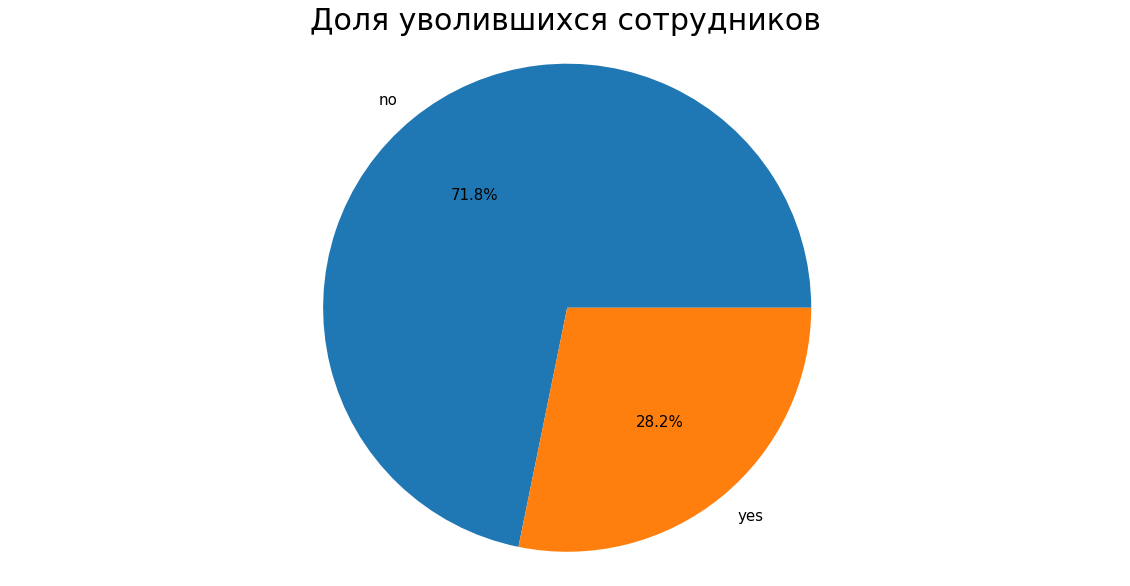

In [ ]:
# визуализируем увольнение
test_target_quit['quit'].value_counts().plot(kind = 'pie', grid = True,\
                                     figsize = (20,10), fontsize=15, autopct='%1.1f%%')

plt.title('Доля уволившихся сотрудников', fontsize=30)
plt.axis('equal')
plt.ylabel('', fontsize=13)

plt.show()

Доля уволившихся сотрудников составляет больше четверти от всех. Это объясняет заинтересованность заказчика в результатах исследования.

#### `'train_quit'`

##### Числовые данные

Для начала взглянем на числовые данные датасета с тренировочной выборкой, чтобы сразу обнаружить яркую аномалию. А также сравнить данные (их порядки) между собой.

In [ ]:
train_quit.drop(['id'], axis = 1).describe() # общее описание

,employment_years,supervisor_evaluation,salary
count,4000.000000,4000.000000,4000.000000
mean,3.701500,3.474750,33805.800000
std,2.541852,1.004049,15152.415163
min,1.000000,1.000000,12000.000000
25%,2.000000,3.000000,22800.000000
50%,3.000000,4.000000,30000.000000
75%,6.000000,4.000000,43200.000000
max,10.000000,5.000000,96000.000000


Числовые данные также измеряются в разных порядках: единицах и сотнях. Следовательно, перед тем, как передавать их модели, потребуется стандартизация.

Ярких аномалий на данном этапе не выявлено.

In [ ]:
# длительность работы в компании
train_quit['employment_years'].describe() # общее описание

count    4000.000000
mean        3.701500
std         2.541852
min         1.000000
25%         2.000000
50%         3.000000
75%         6.000000
max        10.000000
Name: employment_years, dtype: float64

Среднее и медиана не слишком близки, что вместе с большим стандартным отклонением говорит о неравномерности выборки.

Максимальная длительность работы сотрудниками компании составил 10 лет, минимальная - год. Нормальными значениями можно считать от 2 до 6.

In [ ]:
# длительность работы в компании, диаграмма размаха и гистограмма - не подходит для дискретного признака
#fig, axs = plt.subplots(nrows= 1 , ncols= 2, figsize = (16,8))
#sns.histplot(data = train_quit, x = 'employment_years', ax=axs[0], bins = 50, kde=True)
#axs[0].set_xlabel('Годы')
#axs[0].set_ylabel('Количество попаданий в выборку')
#axs[0].set_title('Гистограмма')
#sns.boxplot(data = train_quit, x = 'employment_years', ax=axs[1])
#axs[1].set_xlabel('Годы')
#axs[1].set_title('Диаграмма размаха')
#fig.suptitle('Длительность работы представленных сотрудников в компании (в годах)')
#plt.show()

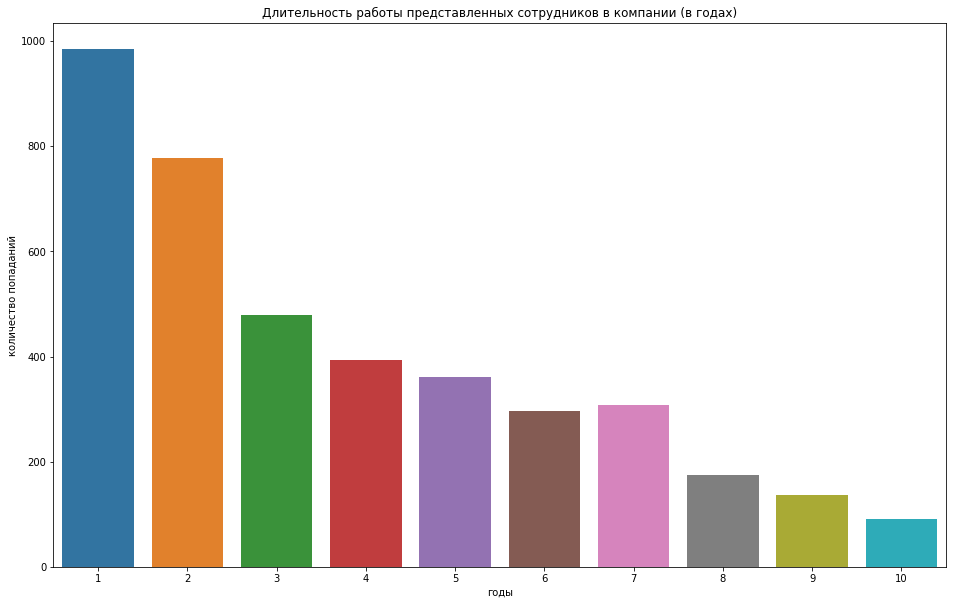

In [ ]:
# график для дискретного признака (на каждое уникальные значение признака строит свою корзину)
plt.figure(figsize=(16,10))

sns.countplot(x=train_quit['employment_years'])

plt.title('Длительность работы представленных сотрудников в компании (в годах)')
plt.xlabel('годы')
plt.ylabel('количество попаданий')

plt.show()

Распределение в выборке не является нормальным: сотрудников с большим стажем меньше, чем с меньшим. Либо сотрудники сотрудники чаще предпочитают увольняться после определенного времени работы, либо переодически происходит расширение штата и набор новых сотрудников, либо все вместе.

В целом, поведение данного параметра повторяет аналогичное у тренировочнных данных из предыдущей задачи.

In [ ]:
# оценка качества работы сотрудника от руководителя
train_quit['supervisor_evaluation'].describe() # общее описание

count    4000.000000
mean        3.474750
std         1.004049
min         1.000000
25%         3.000000
50%         4.000000
75%         4.000000
max         5.000000
Name: supervisor_evaluation, dtype: float64

Среднее и медиана не слишком близки, что вместе с большим стандартным отклонением говорит о неравномерности выборки.

Максимальная оценка качества работы сотрудника от руководителя составила 5, минимальная - 1. Нормальными значениями можно считать от 3 до 4.

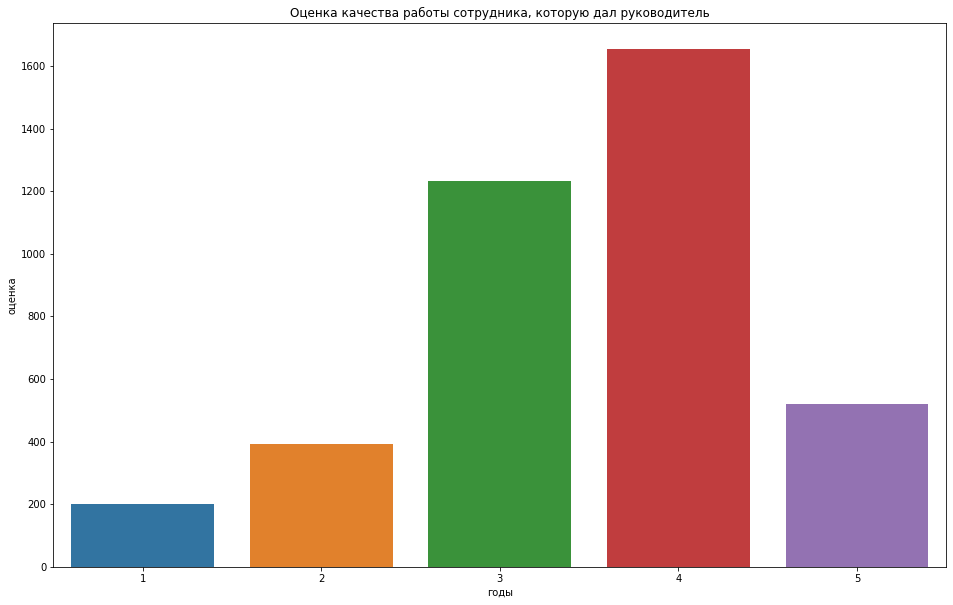

In [ ]:
# график для дискретного признака (на каждое уникальные значение признака строит свою корзину)
plt.figure(figsize=(16,10))

sns.countplot(x=train_quit['supervisor_evaluation'])

plt.title('Оценка качества работы сотрудника, которую дал руководитель')
plt.xlabel('годы')
plt.ylabel('оценка')

plt.show()

Гистограмма стремится (на сколько это возможно) к нормальному распределению.

Посмотрим на строки с работниками, получившими единицу.

In [ ]:
len(train_quit[train_quit['supervisor_evaluation']==1]) # считатем

202

In [ ]:
train_quit[train_quit['supervisor_evaluation']==1] # смотрим

,id,dept,level,workload,employment_years,last_year_promo,last_year_violations,supervisor_evaluation,salary,quit
2,155091,purchasing,middle,medium,5,no,no,1,37200,no
13,672533,marketing,middle,medium,3,yes,yes,1,44400,no
50,821568,sales,junior,medium,2,no,no,1,24000,no
58,512380,purchasing,junior,medium,2,no,yes,1,24000,yes
79,431612,sales,junior,medium,4,no,no,1,24000,no
85,361924,sales,junior,high,2,no,yes,1,32400,yes
89,983352,sales,junior,medium,3,no,no,1,26400,no
95,430622,marketing,middle,medium,5,no,no,1,39600,no
102,208186,hr,middle,medium,6,no,no,1,33600,no
158,572684,hr,junior,medium,4,no,no,1,21600,no


202 работника с большим разнообразием в параметрах.

Посмотрим, сколько их них уволилось

In [ ]:
train_quit[(train_quit['supervisor_evaluation'] == 1)&\
                            (train_quit['quit'] == 'yes')]

,id,dept,level,workload,employment_years,last_year_promo,last_year_violations,supervisor_evaluation,salary,quit
58,512380,purchasing,junior,medium,2,no,yes,1,24000,yes
85,361924,sales,junior,high,2,no,yes,1,32400,yes
177,221429,sales,junior,medium,1,no,no,1,20400,yes
232,316018,hr,junior,low,2,no,no,1,15600,yes
313,273400,technology,junior,medium,1,no,no,1,25200,yes
363,976652,hr,junior,medium,1,no,no,1,22800,yes
372,417561,technology,junior,low,3,no,no,1,14400,yes
449,102639,purchasing,junior,low,1,no,no,1,15600,yes
604,458329,sales,junior,low,1,no,no,1,12000,yes
653,867838,purchasing,junior,high,1,no,no,1,33600,yes


Из них 95 (что составляет почти половину) уволилось, то есть таких работников можно считать уязвимой группой.

В целом поведение данного параметра (`'supervisor_evaluation'`) в датасете `'train_quit'` повторяет аналогичное у датасетата `'train_job_satisfaction_rate'`.

In [ ]:
# зарплата сотрудника
train_quit['salary'].describe() # общее описание

count     4000.000000
mean     33805.800000
std      15152.415163
min      12000.000000
25%      22800.000000
50%      30000.000000
75%      43200.000000
max      96000.000000
Name: salary, dtype: float64

Среднее и медиана относительно близки, однако большое стандартное отклонение говорит о неравномерности выборки. Возможно, есть влияние какой-то категорий.

Максимальная зарплата в компании составила 96000 неизвестных единиц, минимальная - 12000 (то есть разница более чем в 8 раз!). Нормальными значениями можно считать от 22800 до 43200 неизвестных единиц.

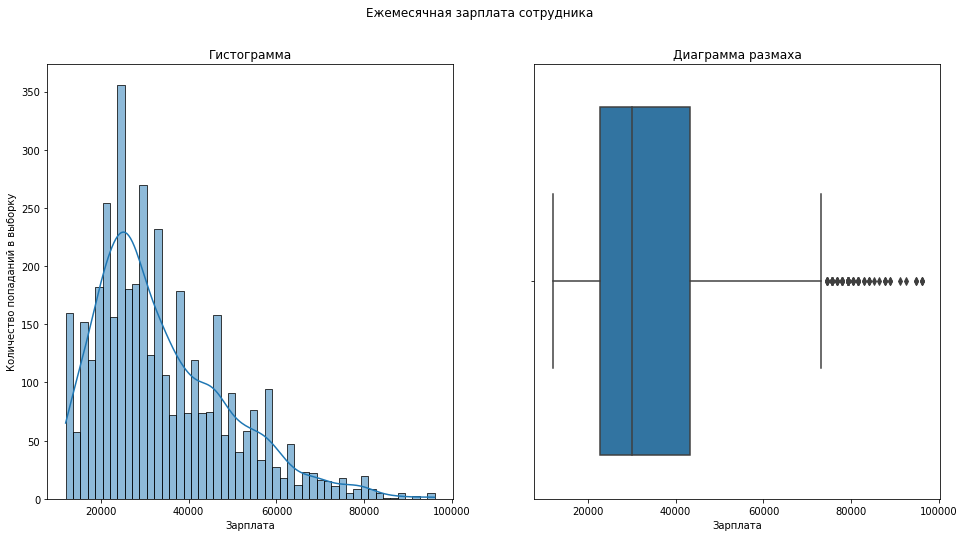

In [ ]:
# зарплата сотрудника, диаграмма размаха и гистограмма
fig, axs = plt.subplots(nrows= 1 , ncols= 2, figsize = (16,8))
sns.histplot(data = train_quit, x = 'salary', ax=axs[0], bins = 50, kde=True)
axs[0].set_xlabel('Зарплата')
axs[0].set_ylabel('Количество попаданий в выборку')
axs[0].set_title('Гистограмма')
sns.boxplot(data = train_quit, x = 'salary', ax=axs[1])
axs[1].set_xlabel('Зарплата')
axs[1].set_title('Диаграмма размаха')
fig.suptitle('Ежемесячная зарплата сотрудника')
plt.show()

Распределение стремится к нормальному со смещением влево и хвостом справа.

Диаграмма размаха демонтрирует ряд выбросов после приблизительно 77000 неизвестных единиц. Вероятно, это топ-менеджмент компании, как и в датасете ранее

Взглянем на них.

In [ ]:
len(train_quit[train_quit['salary'] >77000]) # считаем

55

In [ ]:
train_quit[train_quit['salary'] >77000] # смотрим

,id,dept,level,workload,employment_years,last_year_promo,last_year_violations,supervisor_evaluation,salary,quit
16,113657,technology,sinior,high,5,yes,no,3,82800,no
100,540780,sales,sinior,high,7,no,yes,3,78000,no
179,208223,technology,sinior,high,7,no,no,3,94800,no
185,694599,technology,sinior,high,1,no,no,4,96000,no
198,646839,sales,sinior,high,5,no,no,4,79200,no
246,169650,sales,sinior,high,10,no,no,4,79200,no
286,638931,technology,sinior,high,10,no,no,4,88800,no
316,429914,sales,sinior,high,3,no,no,4,78000,no
323,740852,technology,sinior,high,8,no,no,4,96000,no
349,828211,technology,sinior,high,3,no,no,3,78000,no


55 сотрудника на высоких должностях и с высокой нагрузкой - то есть их столь высокая зарплата вполне объяснима. И также мы не можем их исключать из исследования, чтобы модель научилась делать правильные прогнозы для всех работников.

Ради интереса вглянем, как много из них уволилось.

In [ ]:
train_quit[(train_quit['salary'] >77000)&\
        (train_quit['quit'] == 'yes')]

,id,dept,level,workload,employment_years,last_year_promo,last_year_violations,supervisor_evaluation,salary,quit
848,633488,technology,sinior,high,6,no,no,4,79200,yes
1728,205905,technology,sinior,high,9,no,no,4,79200,yes


Лишь два топовых специалиста решило уволиться.

В любом случае, исключать из исследования мы их не можем, ведь увольнение даже одного специалиста такого уровня может нанести серьезный вред компании.

В целом поведение данного параметра (`'salary'`) в датасете `'train_quit'` повторяет аналогичное у датасетата `'train_job_satisfaction_rate'`.

##### Категориальные данные

Перейдем на категориальные данные.

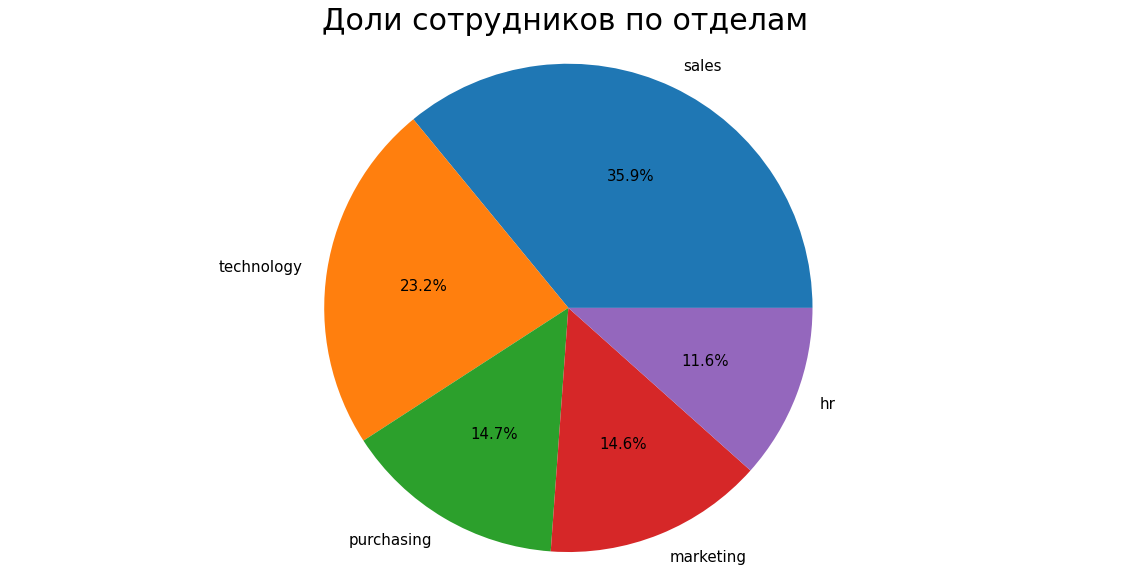

In [ ]:
# визуализируем отделы
train_quit['dept'].value_counts().plot(kind = 'pie', grid = True,\
                                     figsize = (20,10), fontsize=15, autopct='%1.1f%%')

plt.title('Доли сотрудников по отделам', fontsize=30)
plt.axis('equal')
plt.ylabel('', fontsize=13)

plt.show()

Больше всего сотрудников занято в продажах ("sales", 1е место с отрывом), технологиях ("technology", 2е), меньше - в закупках ("purchasing"), маркетинге и кадрах("hr").

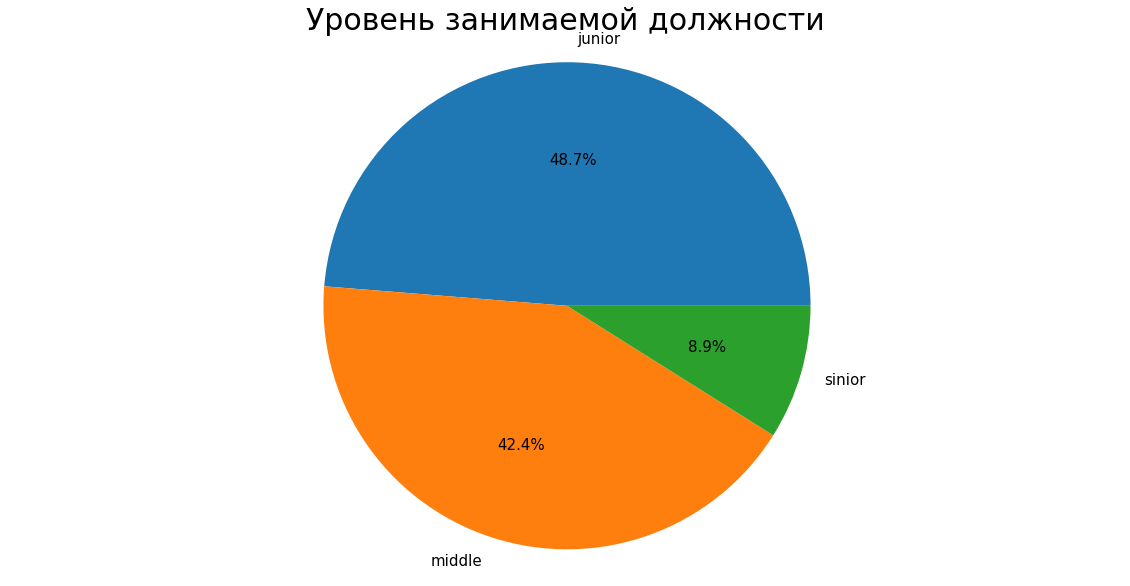

In [ ]:
# визуализируем должности
train_quit['level'].value_counts().plot(kind = 'pie', grid = True,\
                                     figsize = (20,10), fontsize=15, autopct='%1.1f%%')

plt.title('Уровень занимаемой должности', fontsize=30)
plt.axis('equal')
plt.ylabel('', fontsize=13)

plt.show()

Доли сотрудников уровня "junior" и "middle" относительно близки (но первых все-таки больше), а вот "sinior" ожидаемо гораздо меньше.

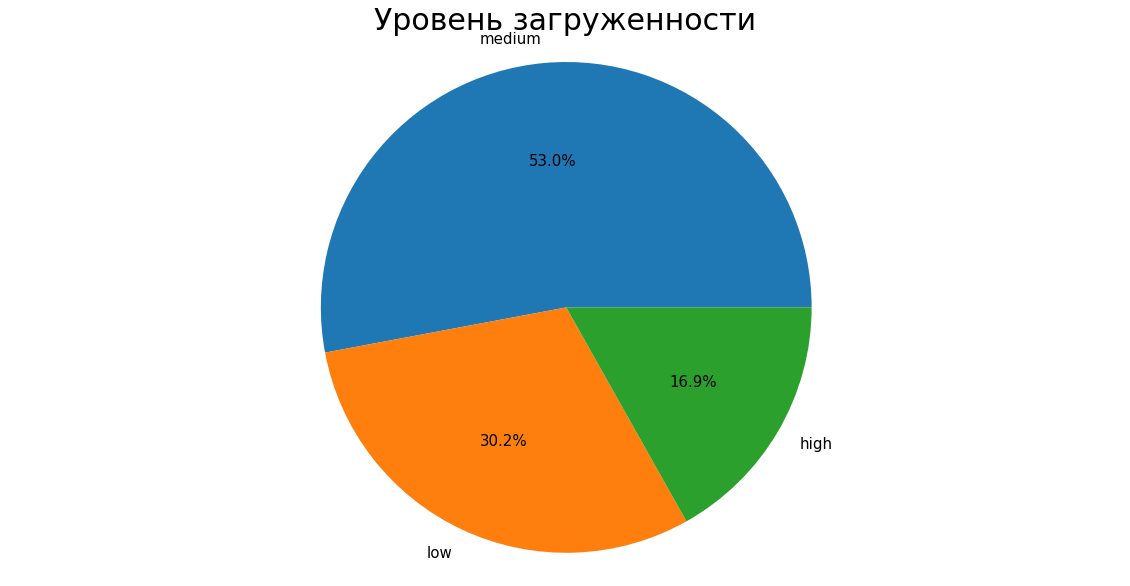

In [ ]:
# визуализируем уровень загруженности
train_quit['workload'].value_counts().plot(kind = 'pie', grid = True,\
                                     figsize = (20,10), fontsize=15, autopct='%1.1f%%')

plt.title('Уровень загруженности', fontsize=30)
plt.axis('equal')
plt.ylabel('', fontsize=13)

plt.show()

Средний уровень нагрузки занимает самую большую долю (что логично), а тяжелый - меньше всех.

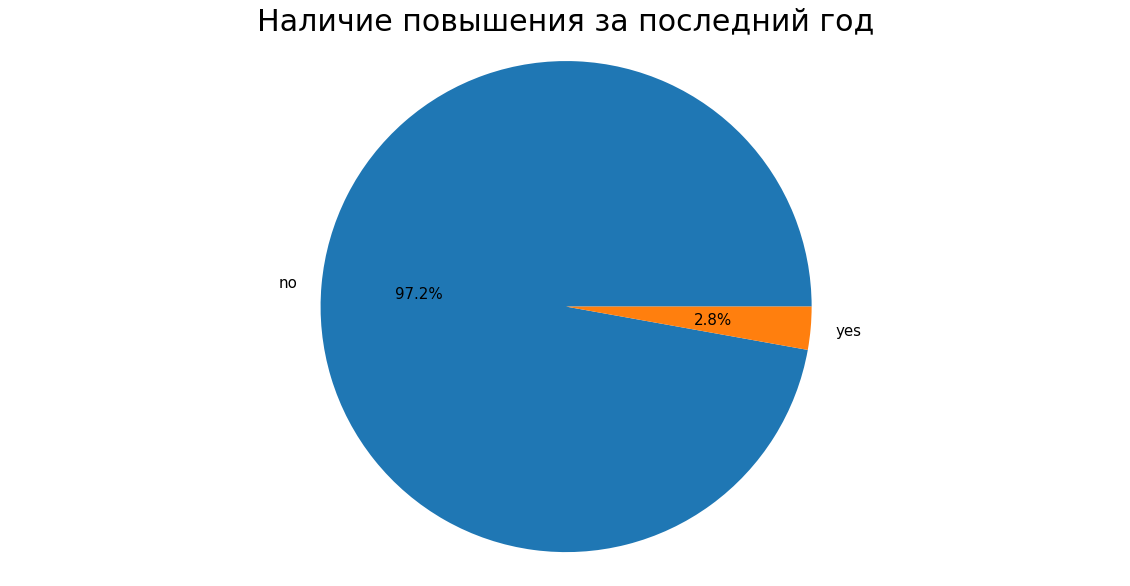

In [ ]:
# визуализируем повышения
train_quit['last_year_promo'].value_counts().plot(kind = 'pie', grid = True,\
                                     figsize = (20,10), fontsize=15, autopct='%1.1f%%')

plt.title('Наличие повышения за последний год', fontsize=30)
plt.axis('equal')
plt.ylabel('', fontsize=13)

plt.show()

Повышения выдают не так часто: лишь почти 3% сотрудников получили его за последний год. Это выглядит логичным: достойных сотрудников может быть много, а свободных вакансий - мало.

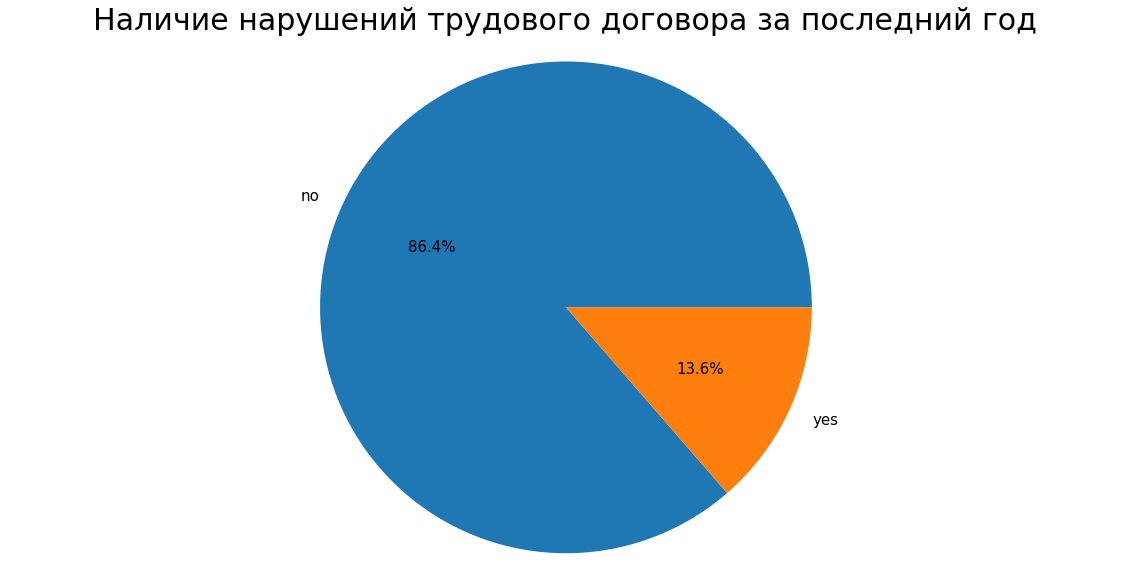

In [ ]:
# визуализируем повышения
train_quit['last_year_violations'].value_counts().plot(kind = 'pie', grid = True,\
                                     figsize = (20,10), fontsize=15, autopct='%1.1f%%')

plt.title('Наличие нарушений трудового договора за последний год', fontsize=30)
plt.axis('equal')
plt.ylabel('', fontsize=13)

plt.show()

Почти 14% сотрудников имели нарушения за прошлый год (по крайней мере, заффиксированные. Мы не знаем, сколько их было у каждого из нарушивших, и были ли какие-то упущены и не зафиксированы). С одной стороны - выглядит кажется немного. А с другой - каждый 7й сотрудний является нарушителем! Все-таки лучше выяснить, в чем именно состоят эти нарушения: опоздания ли это из-за нарушающего расписания автобуса или непредвиденных погодных условий, нежелание следовать дресс-коду, разовая неявка на частые совещания или что-то еще? И ввиду этого следует пересмотреть внутренний регламент, сделать его более гибким и комфортным не в ущерб рабочему процессу?

Посмотрим, как часто увольнялись нарушители.

In [ ]:
len(train_quit[train_quit['last_year_violations'] == 'yes']) # считаем нарушителей

545

In [ ]:
# смотрим, кто из них уволился
train_quit[(train_quit['last_year_violations'] == 'yes')&\
                            (train_quit['quit'] == 'yes')]

,id,dept,level,workload,employment_years,last_year_promo,last_year_violations,supervisor_evaluation,salary,quit
3,257132,sales,junior,medium,2,no,yes,3,24000,yes
5,699916,sales,junior,low,1,no,yes,3,18000,yes
39,411906,technology,junior,low,2,no,yes,4,22800,yes
58,512380,purchasing,junior,medium,2,no,yes,1,24000,yes
85,361924,sales,junior,high,2,no,yes,1,32400,yes
106,318373,sales,junior,low,1,no,yes,2,12000,yes
137,948157,sales,junior,medium,2,no,yes,3,20400,yes
139,219281,sales,junior,low,1,no,yes,3,12000,yes
192,886091,hr,junior,medium,2,no,yes,2,22800,yes
210,182385,technology,junior,low,1,no,yes,4,19200,yes


Оказывается, довольно часто. Интересно, что первично: нарушение, выговор за который простимулировало желание уволиться, или желание уволиться, которое вылилось в пренебрежение правилами?

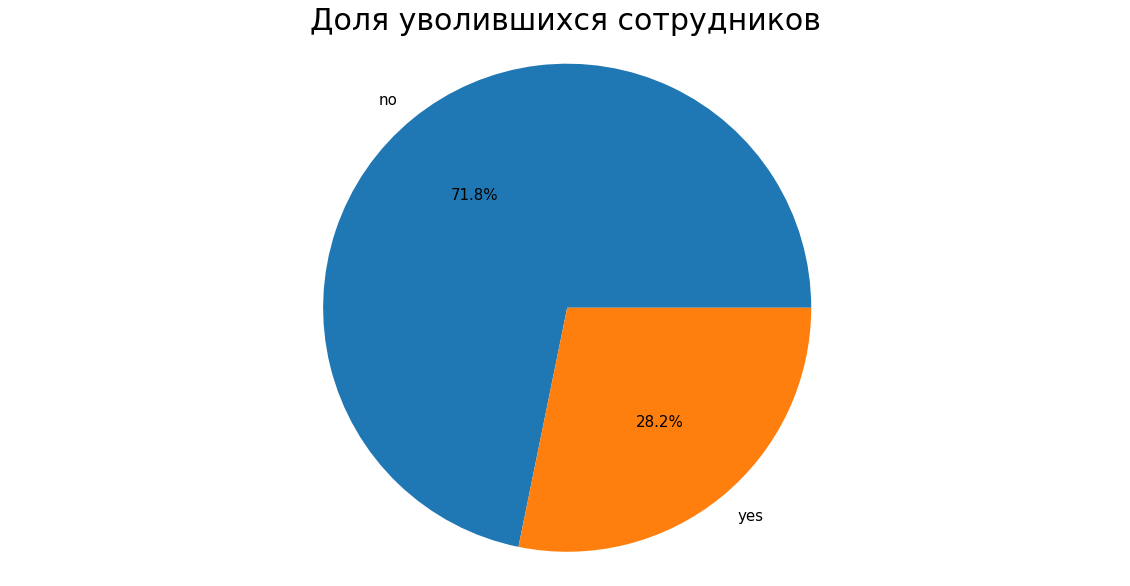

In [ ]:
# визуализируем увольнение
train_quit['quit'].value_counts().plot(kind = 'pie', grid = True,\
                                     figsize = (20,10), fontsize=15, autopct='%1.1f%%')

plt.title('Доля уволившихся сотрудников', fontsize=30)
plt.axis('equal')
plt.ylabel('', fontsize=13)

plt.show()

Количество уволившихся составляет несколько больше четверти выборки. И совпадает с аналогичной в тестовой выборке целевого признака.

##### Диаграммы рассеяния и портрет уволившегося сотрудника

Теперь попробуем взглянуть на некоторые диаграммы рассеяния для этих признаков с учетом целевого, чтобы составить примерный портрет уволившегося сотрудника.

Диаграмма рассеивания уволившихся (yes) и оставшихся (no) сотрудников в зависимости от отдела и нагрузки


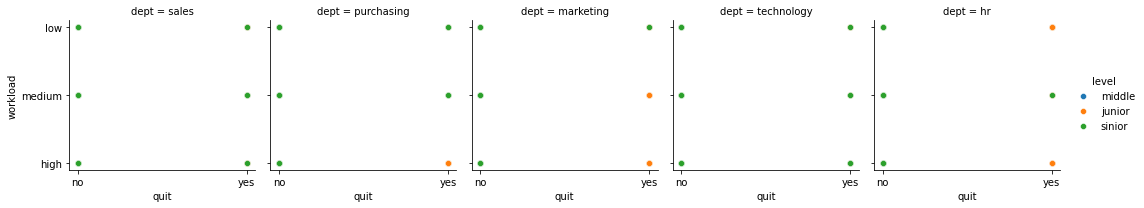

In [ ]:
# диаграмма рассеяния, вариант 2

sns.FacetGrid(train_quit, col='dept', hue='level', col_wrap=5)\
.map(sns.scatterplot,  'quit', 'workload')\
.add_legend();
print('Диаграмма рассеивания уволившихся (yes) и оставшихся (no) сотрудников в зависимости от отдела и нагрузки')
plt.show()

Похоже желание уволится не зависит от отдела или нагрузки. А вот от должности - вполне: к увольнению похоже чаще склонны сотрудники уровня "middle" (хотя по общему количеству в компании они почти сопоставимы с "junior"). Это вполне логично: "junior" стремяться набрать опыта и навыков для повышения своей квалификации и ценности как специалиста, поэтому стараются закрепиться на месте, к тому же им есть, куда расти; "middle" - уже более опытный сотрудник, который теперь может позволить себе "смотреть по сторонам" в поисках иного, более првлекательного ему по каким-либо причинам места, тем более, что дальнейший рост по уровню должности внутри компании ограничен (количество позиций "sinior" ограничено, и увольняются оттуда неохотно).

Но попробуем немного упростить график, быть может там появятся еще какие-то интересные закономерности?

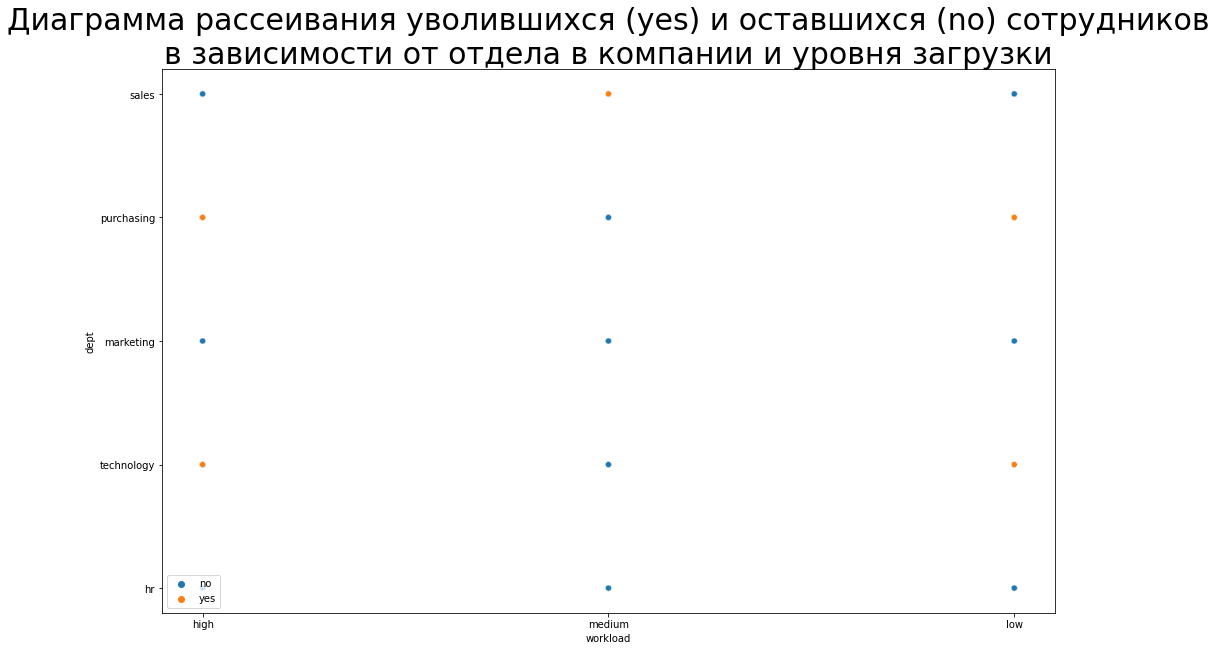

In [ ]:
# диаграмма рассеяния, вариант 1
plt.figure(figsize=(16,10))

sns.scatterplot(data=train_quit, hue='quit', x='workload', y='dept')
plt.legend(loc='best')
plt.title('Диаграмма рассеивания уволившихся (yes) и оставшихся (no) сотрудников\n\
в зависимости от отдела в компании и уровня загрузки', fontsize=30)

plt.show()

Чаще склонны увольняться сотрудники из отделов технологии и поддержки (но они и по количеству сотрудников занимают 2 и 3 место) с высокой или низкой нагрузкой, а также из отдела продаж - со средней (как мы помним - первое место по количеству сотрудников). То есть чем больше отдел - тем больше оттуда людей увольняется, и это в принципе логично. А уровень загрузки средний к тому же самый распространенный сам по себе.

То есть чаще увольняются сотрудники из больших отделов, а вот уровень загрузки связан уже с профилем отдела.

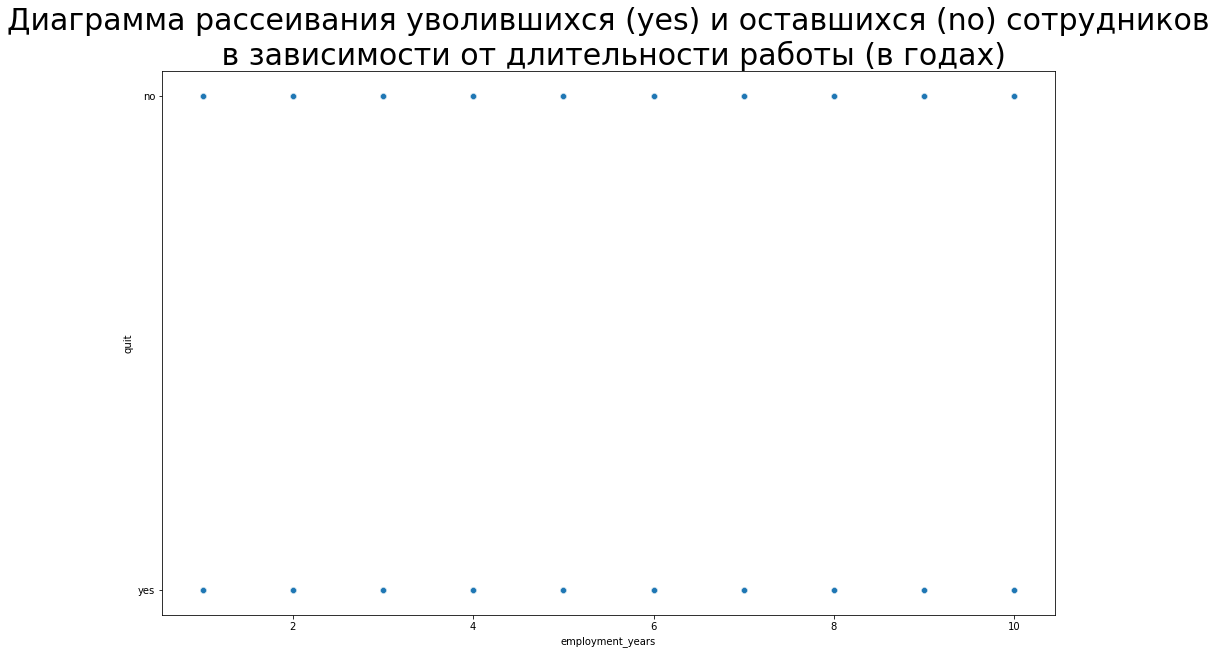

In [ ]:
# диаграмма рассеяния, вариант 3
plt.figure(figsize=(16,10))

sns.scatterplot(data=train_quit, x='employment_years', y='quit')

plt.title('Диаграмма рассеивания уволившихся (yes) и оставшихся (no) сотрудников\n\
 в зависимости от длительности работы (в годах)', fontsize=30)

plt.show()

Желание уволиться от стажа как будто не зависит. А если еще добавить фактор зарплаты?

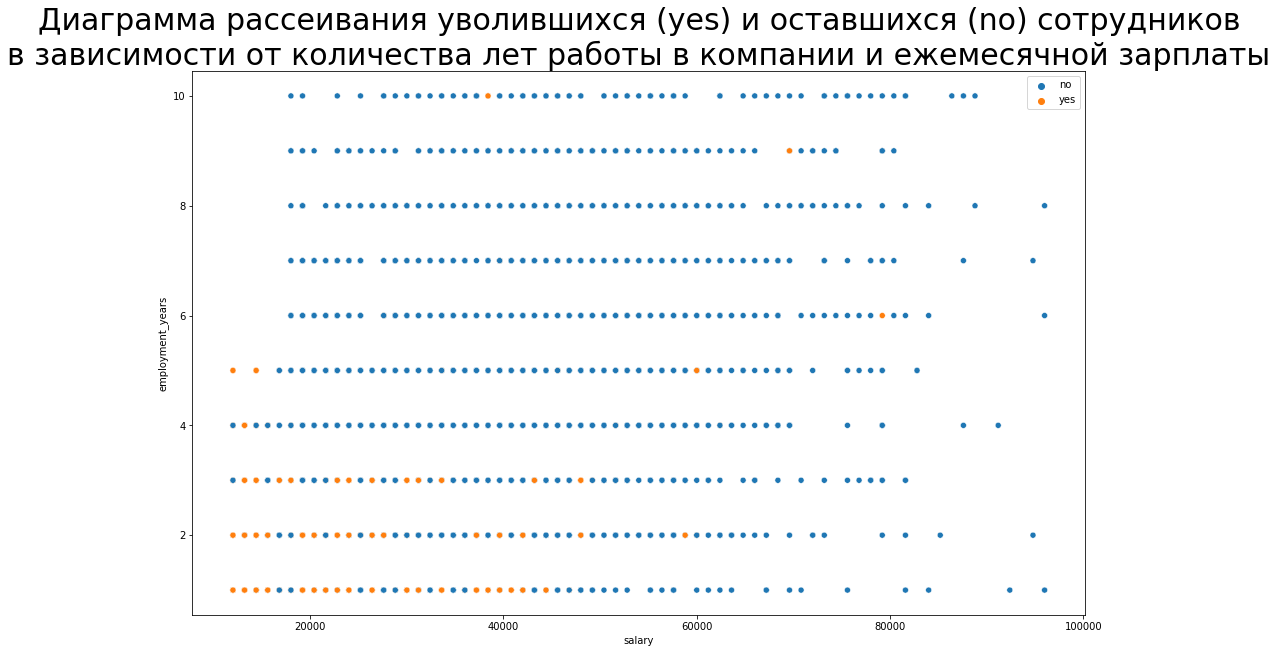

In [ ]:
# диаграмма рассеяния, вариант 1
plt.figure(figsize=(16,10))

sns.scatterplot(data=train_quit, hue='quit', x='salary', y='employment_years')
plt.legend(loc='best')
plt.title('Диаграмма рассеивания уволившихся (yes) и оставшихся (no) сотрудников\n\
в зависимости от количества лет работы в компании и ежемесячной зарплаты', fontsize=30)

plt.show()

А вот тут ситуация уже интереснее: чаще склонны увольняться работники с небольшим стажем (от 1 до 3 лет) с зарплатой менее 50000 (при том, что средняя составляет около 33 тыс, а медианная - около 30 тыс), и чем меньше зарплата и стаж - тем выше это желание.

Попробуем еще построить круговые диаграммы в разрезе факторов, а также гистограммы для числовых. Возможно, они будут все-таки более информативны.

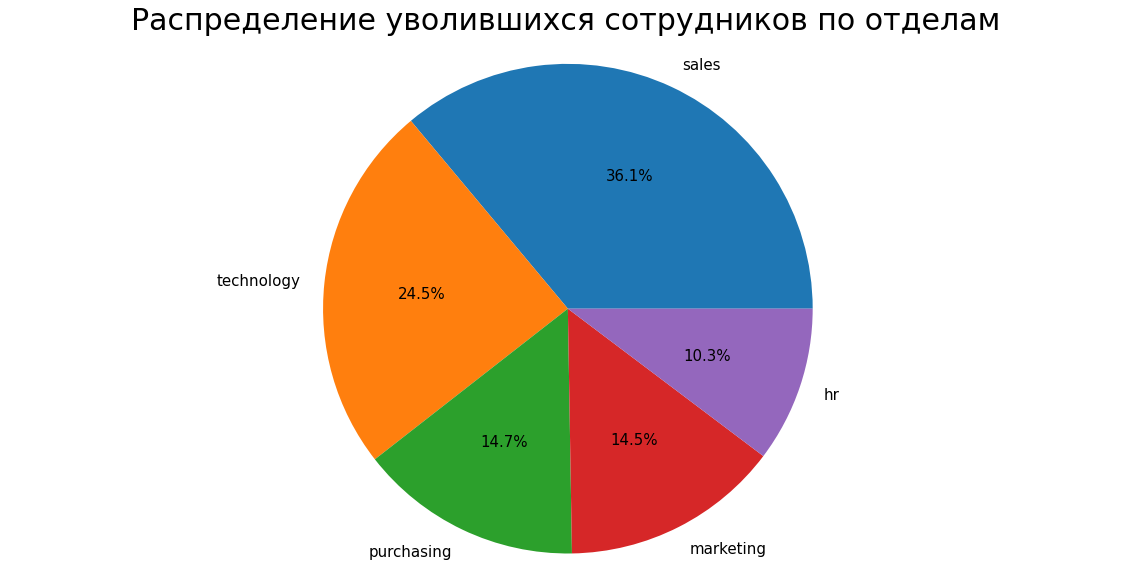

In [ ]:
# визуализируем увольнение
train_quit.query('quit == "yes"')['dept'].value_counts().plot(kind = 'pie', grid = True,\
                                     figsize = (20,10), fontsize=15, autopct='%1.1f%%')

plt.title('Распределение уволившихся сотрудников по отделам', fontsize=30)
plt.axis('equal')
plt.ylabel('', fontsize=13)

plt.show()

Как мы уже раньше видели - чем больше отдел, тем больше людей из него увольняется, что естественно. То есть желание уволиться не зависит от отдела.

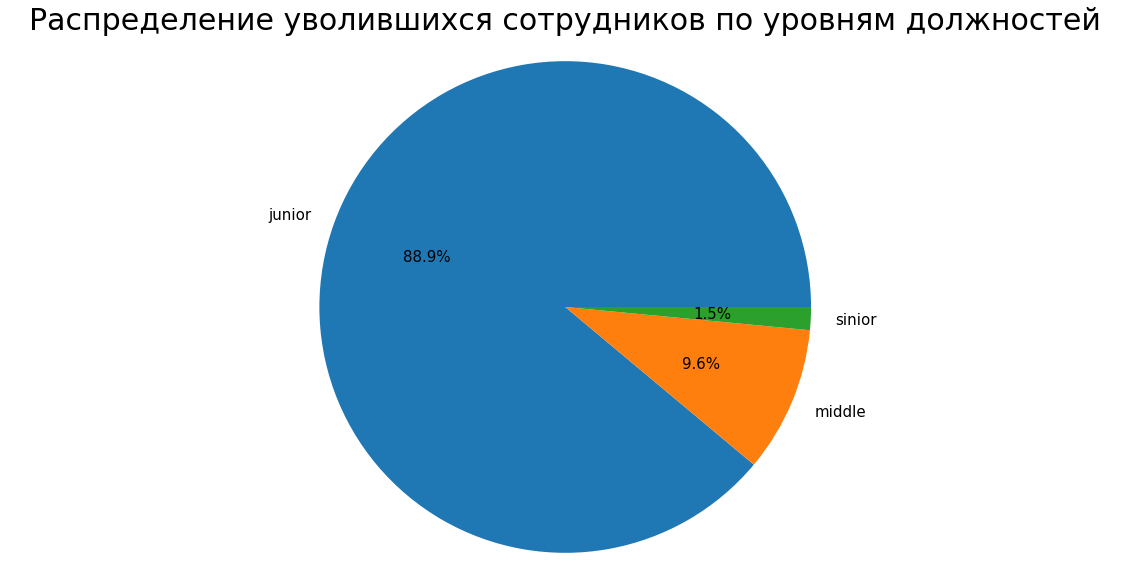

In [ ]:
# визуализируем увольнение
train_quit.query('quit == "yes"')['level'].value_counts().plot(kind = 'pie', grid = True,\
                                     figsize = (20,10), fontsize=15, autopct='%1.1f%%')

plt.title('Распределение уволившихся сотрудников по уровням должностей', fontsize=30)
plt.axis('equal')
plt.ylabel('', fontsize=13)

plt.show()

А вот тут мы видим, что все-таки чаще всего увольняются сотрудники уровня "junior". Причем увольняются они гораздо чаще, чем сотрудники уровня "middle" которые хоть и уступают "junior" по общему количеству, но не слишком на много.

Возможно, это объясняется тем, что не все из них проходят испытательный срок, оказываются недостаточно компетентны, или обнаруживают желание двигаться дальше, но в другом месте.

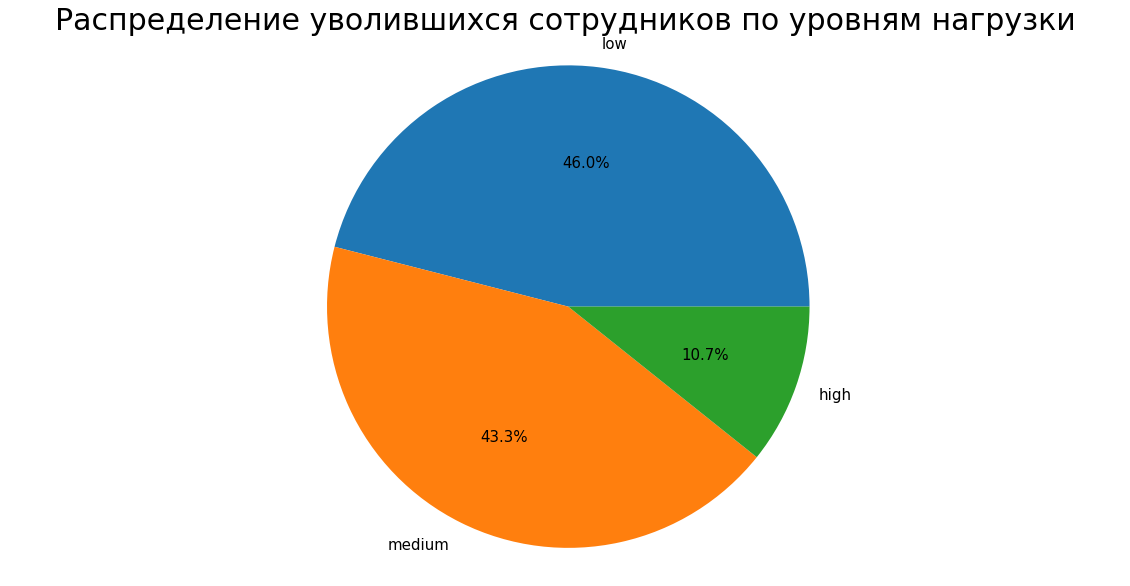

In [ ]:
# визуализируем увольнение
train_quit.query('quit == "yes"')['workload'].value_counts().plot(kind = 'pie', grid = True,\
                                     figsize = (20,10), fontsize=15, autopct='%1.1f%%')

plt.title('Распределение уволившихся сотрудников по уровням нагрузки', fontsize=30)
plt.axis('equal')
plt.ylabel('', fontsize=13)

plt.show()

Чаще увольняются сотрудники с низким уровнем нагрузки, чем со средним, хотя по общему количеству сотрудников с уровнем загрузки "medium" было больше, чем с уровнем "low". То есть уровень нагрузки имеет значение.

Возможно, такие работники ощущают себя недостаточно востребованными здесь (и даже могут испытывать скуку), и ищут иное место для самореализации.

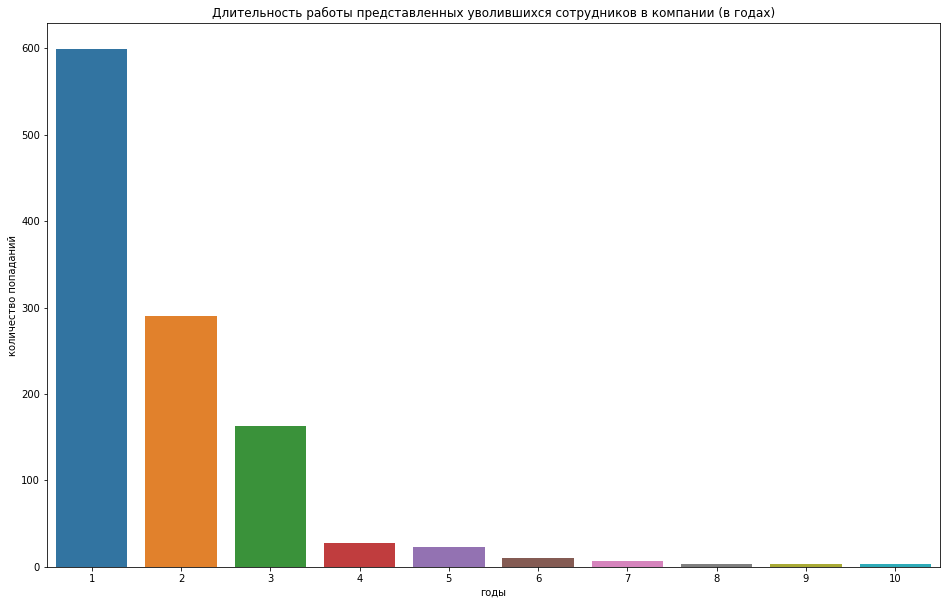

In [ ]:
# график для дискретного признака (на каждое уникальные значение признака строит свою корзину)
plt.figure(figsize=(16,10))

sns.countplot(x=train_quit.query('quit == "yes"')['employment_years'])

plt.title('Длительность работы представленных уволившихся сотрудников в компании (в годах)')
plt.xlabel('годы')
plt.ylabel('количество попаданий')

plt.show()

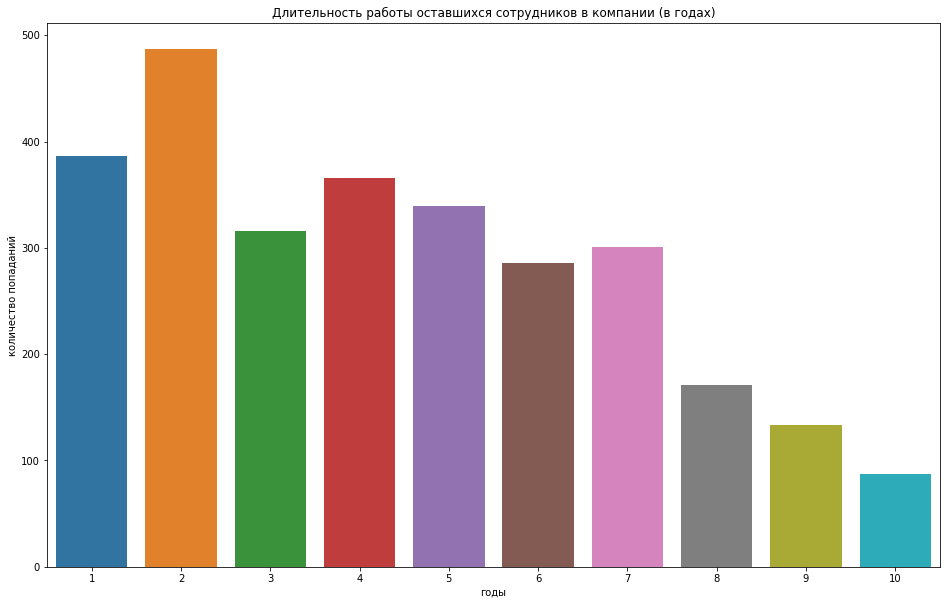

In [ ]:
# график для дискретного признака (на каждое уникальные значение признака строит свою корзину)
plt.figure(figsize=(16,10))

sns.countplot(x=train_quit.query('quit != "yes"')['employment_years'])

plt.title('Длительность работы оставшихся сотрудников в компании (в годах)')
plt.xlabel('годы')
plt.ylabel('количество попаданий')

plt.show()

Чаще увольняются сотрудники с меньшей длительностью работы в компании, основная масса работала 3 и менее лет.

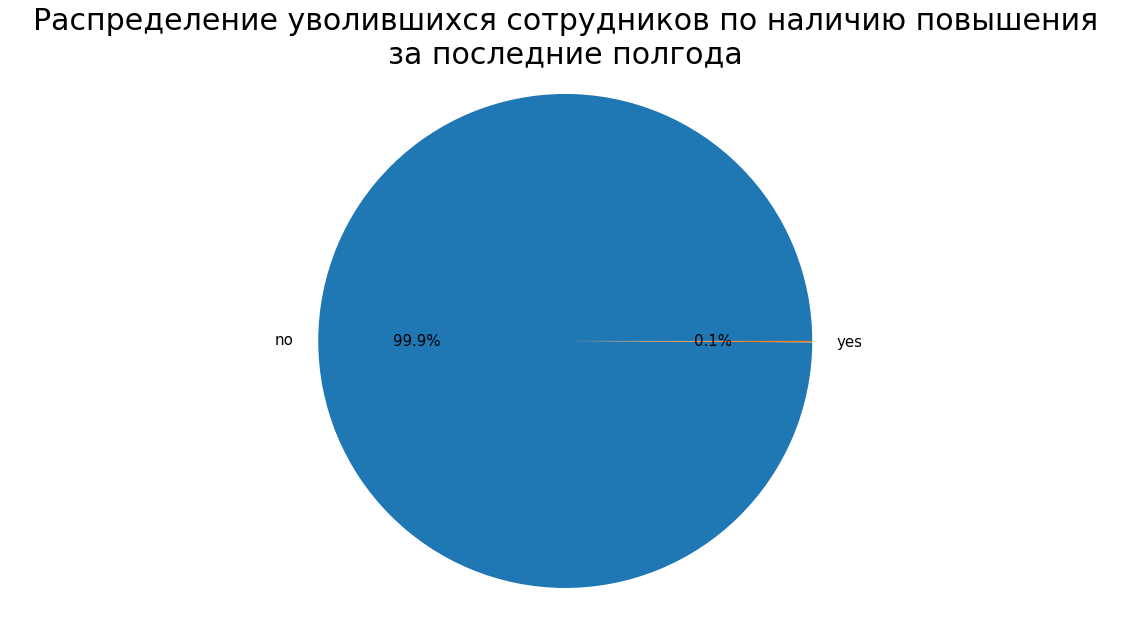

In [ ]:
# визуализируем увольнение
train_quit.query('quit == "yes"')['last_year_promo'].value_counts().plot(kind = 'pie', grid = True,\
                                     figsize = (20,10), fontsize=15, autopct='%1.1f%%')

plt.title('Распределение уволившихся сотрудников по наличию повышения\n\
за последние полгода', fontsize=30)
plt.axis('equal')
plt.ylabel('', fontsize=13)

plt.show()

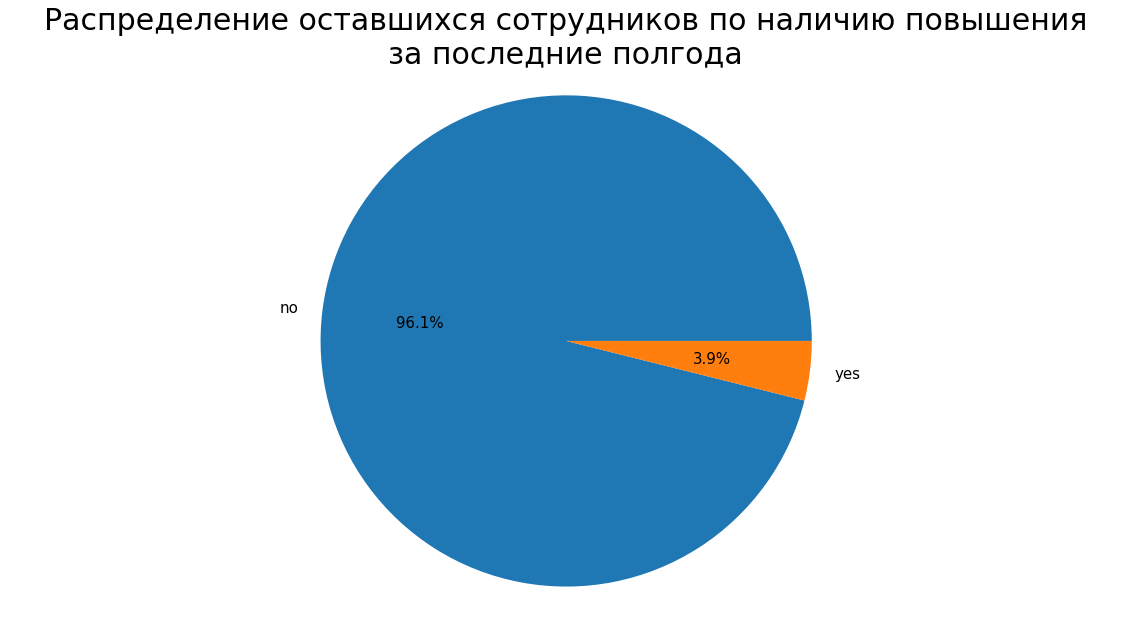

In [ ]:
# визуализируем не-увольнение
train_quit.query('quit != "yes"')['last_year_promo'].value_counts().plot(kind = 'pie', grid = True,\
                                     figsize = (20,10), fontsize=15, autopct='%1.1f%%')

plt.title('Распределение оставшихся сотрудников по наличию повышения\n\
за последние полгода', fontsize=30)
plt.axis('equal')
plt.ylabel('', fontsize=13)

plt.show()

Среди уволившихся почти никто не получил повышения. Однако и в общем количестве повышенных за последние полгода было всего около 3%. Так что если данный параметр и влияет, то не сильно.

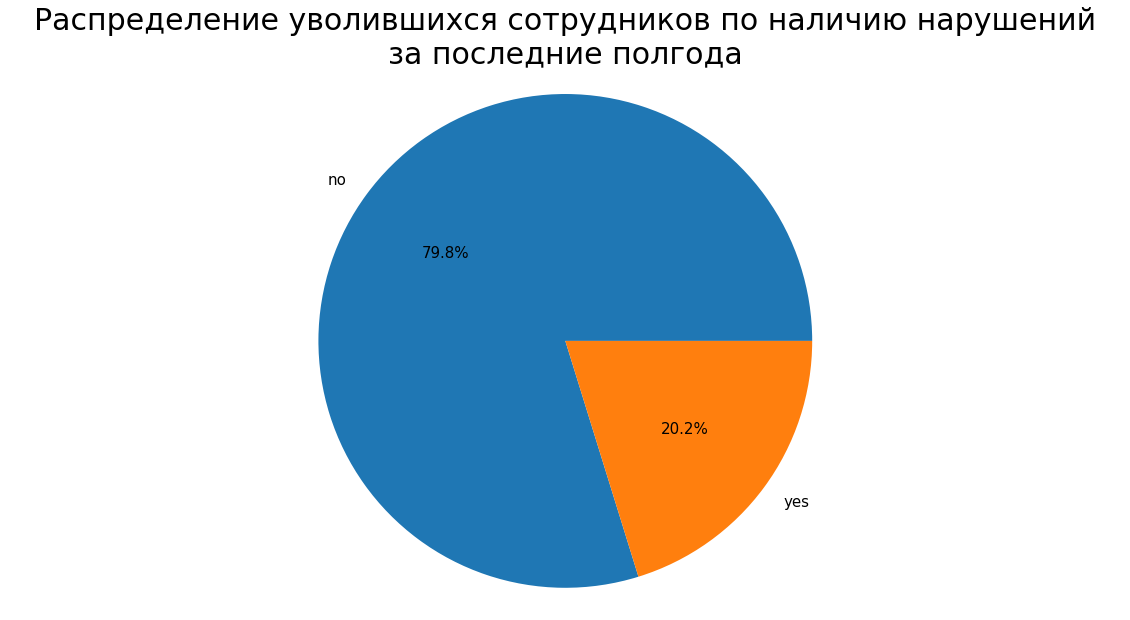

In [ ]:
# визуализируем увольнение
train_quit.query('quit == "yes"')['last_year_violations'].value_counts().plot(kind = 'pie', grid = True,\
                                     figsize = (20,10), fontsize=15, autopct='%1.1f%%')

plt.title('Распределение уволившихся сотрудников по наличию нарушений\n\
за последние полгода', fontsize=30)
plt.axis('equal')
plt.ylabel('', fontsize=13)

plt.show()

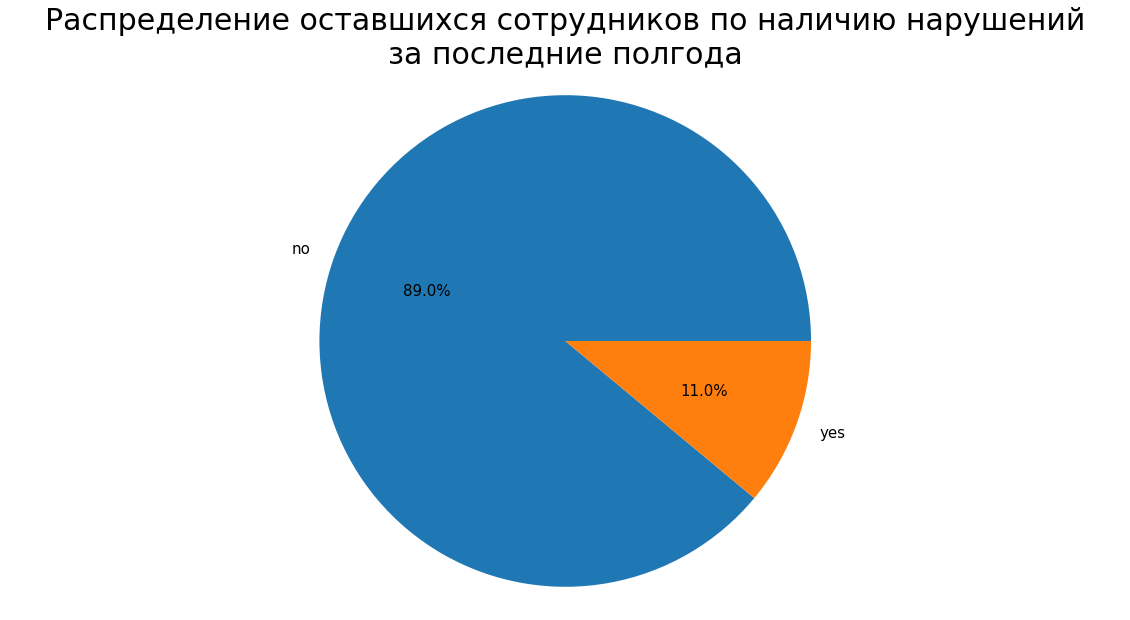

In [ ]:
# визуализируем не-увольнение
train_quit.query('quit != "yes"')['last_year_violations'].value_counts().plot(kind = 'pie', grid = True,\
                                     figsize = (20,10), fontsize=15, autopct='%1.1f%%')

plt.title('Распределение оставшихся сотрудников по наличию нарушений\n\
за последние полгода', fontsize=30)
plt.axis('equal')
plt.ylabel('', fontsize=13)

plt.show()

Большинство сотрудников не имело нарушений (но и доля нарушителей среди них несколько больше, чем "в общей мессе", то есть параметр если и оказывает влияние, то не слишком большое).

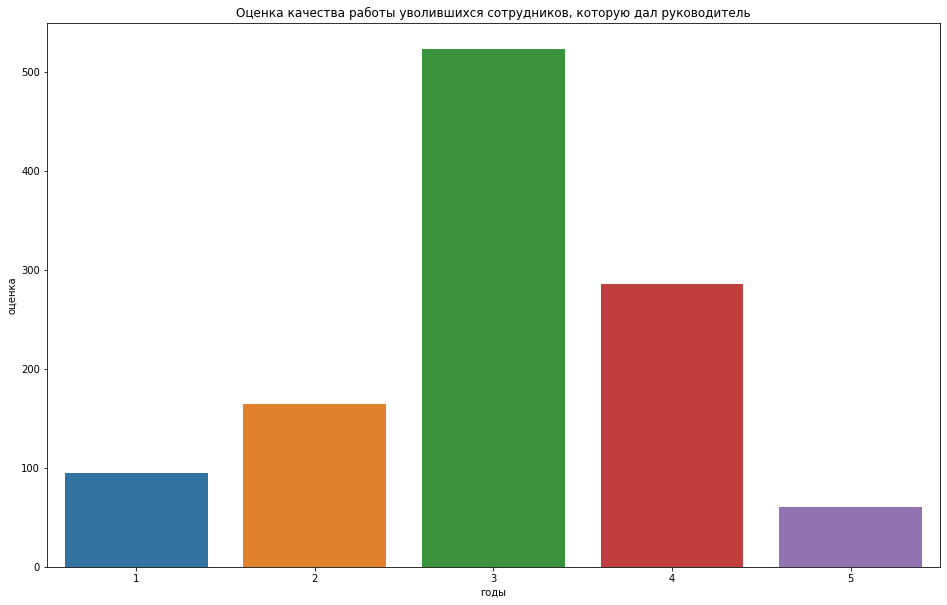

In [ ]:
# график для дискретного признака (на каждое уникальные значение признака строит свою корзину)
plt.figure(figsize=(16,10))

sns.countplot(x=train_quit.query('quit == "yes"')['supervisor_evaluation'])

plt.title('Оценка качества работы уволившихся сотрудников, которую дал руководитель')
plt.xlabel('годы')
plt.ylabel('оценка')

plt.show()

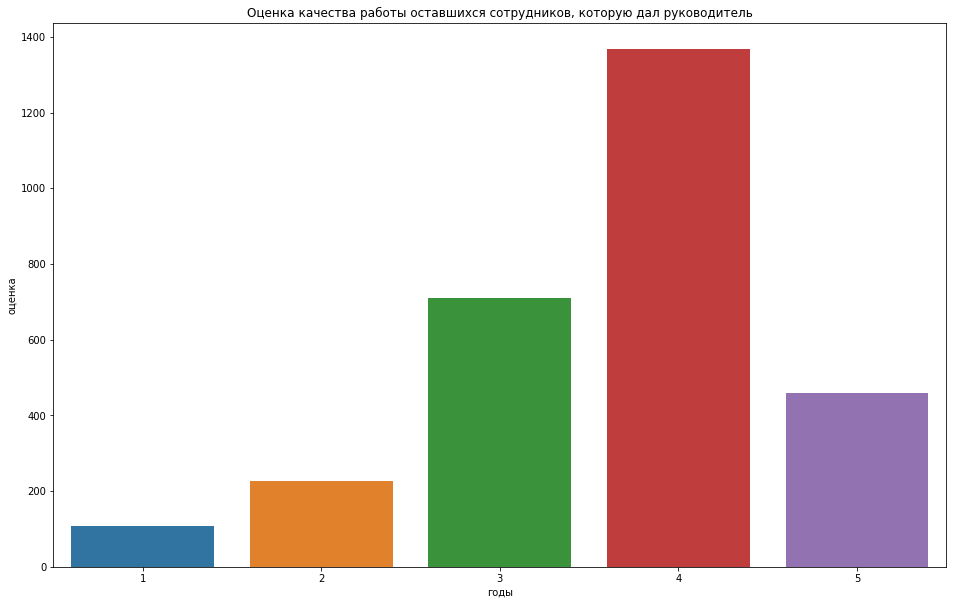

In [ ]:
# график для дискретного признака (на каждое уникальные значение признака строит свою корзину)
plt.figure(figsize=(16,10))

sns.countplot(x=train_quit.query('quit != "yes"')['supervisor_evaluation'])

plt.title('Оценка качества работы оставшихся сотрудников, которую дал руководитель')
plt.xlabel('годы')
plt.ylabel('оценка')

plt.show()

Видим, что уволившиеся работники несколько чаще получали оценку 3, а оставшиеся - 4. Похоже, напрямую данный фактор не оказывает влияния.

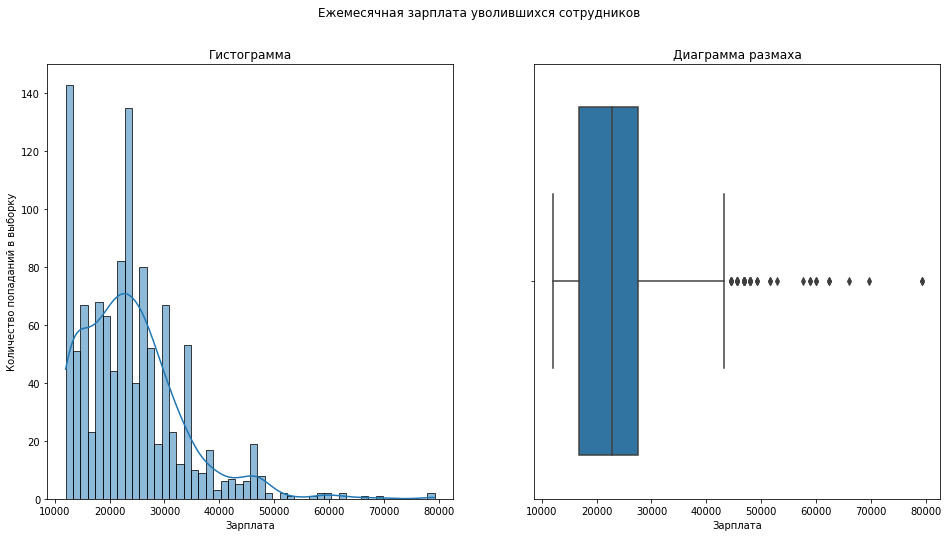

In [ ]:
# зарплата, диаграмма размаха и гистограмма
fig, axs = plt.subplots(nrows= 1 , ncols= 2, figsize = (16,8))
sns.histplot(data = train_quit[train_quit['quit']=='yes'], x = 'salary', ax=axs[0], bins = 50, kde=True)
axs[0].set_xlabel('Зарплата')
axs[0].set_ylabel('Количество попаданий в выборку')
axs[0].set_title('Гистограмма')
sns.boxplot(data = train_quit[train_quit['quit']=='yes'], x = 'salary', ax=axs[1])
axs[1].set_xlabel('Зарплата')
axs[1].set_title('Диаграмма размаха')
fig.suptitle('Ежемесячная зарплата уволившихся сотрудников')
plt.show()

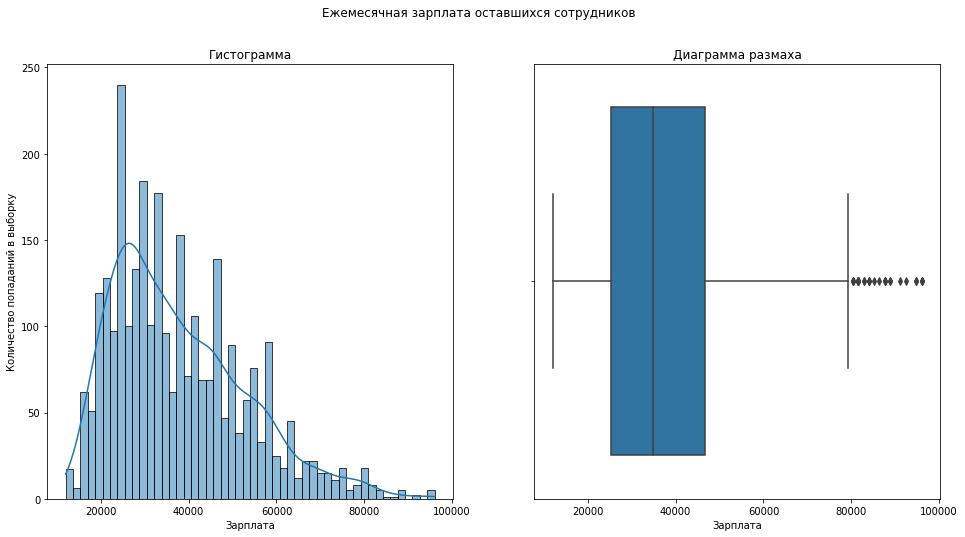

In [ ]:
# зарплата, диаграмма размаха и гистограмма
fig, axs = plt.subplots(nrows= 1 , ncols= 2, figsize = (16,8))
sns.histplot(data = train_quit[train_quit['quit']!='yes'], x = 'salary', ax=axs[0], bins = 50, kde=True)
axs[0].set_xlabel('Зарплата')
axs[0].set_ylabel('Количество попаданий в выборку')
axs[0].set_title('Гистограмма')
sns.boxplot(data = train_quit[train_quit['quit']!='yes'], x = 'salary', ax=axs[1])
axs[1].set_xlabel('Зарплата')
axs[1].set_title('Диаграмма размаха')
fig.suptitle('Ежемесячная зарплата оставшихся сотрудников')
plt.show()

Снова видим картину, подобную на распределение общей массы сотрудников, однако общий уровень зарплаты ниже, чем у оставшихся. То есть зарплата может оказывать влиянее, но не является ключевым фактором отличия.

Сложив все вместе получим общий портрет уволившегося сотрудника:

- работал в отделах "sales" или "technology";
- на позиции "junior";
- с уровнем нагрузки "low";
- работал 3 или менее года;
- повышений не имел;
- нарушений трудового договора тоже не было;
- оценка от руководителя составляла от 3 до 4, *3 получал чаще*;
- зарплата составляла менее 45000.

Но после того, как мы отбросим параметры, близко схожие с распределением таковых у общей массы, оставим только то, что несколько отличает их от не уволившихся работников.

И так, уточненный потрет работника:

- работал на позиции "junior";
- с уровнем нагрузки "low";
- работал 3 или менее года.

##### Матрица корреляции

Построить матрицу корреляции, чтобы увидеть возможные связи между признаками.

Так как целевой признак у нас является категориальным значением, будем сразу строить матрицу phik.

In [ ]:
# считаем корреляции
phik_overview_q = train_quit.drop('id', axis=1).phik_matrix(interval_cols=interval_cols)

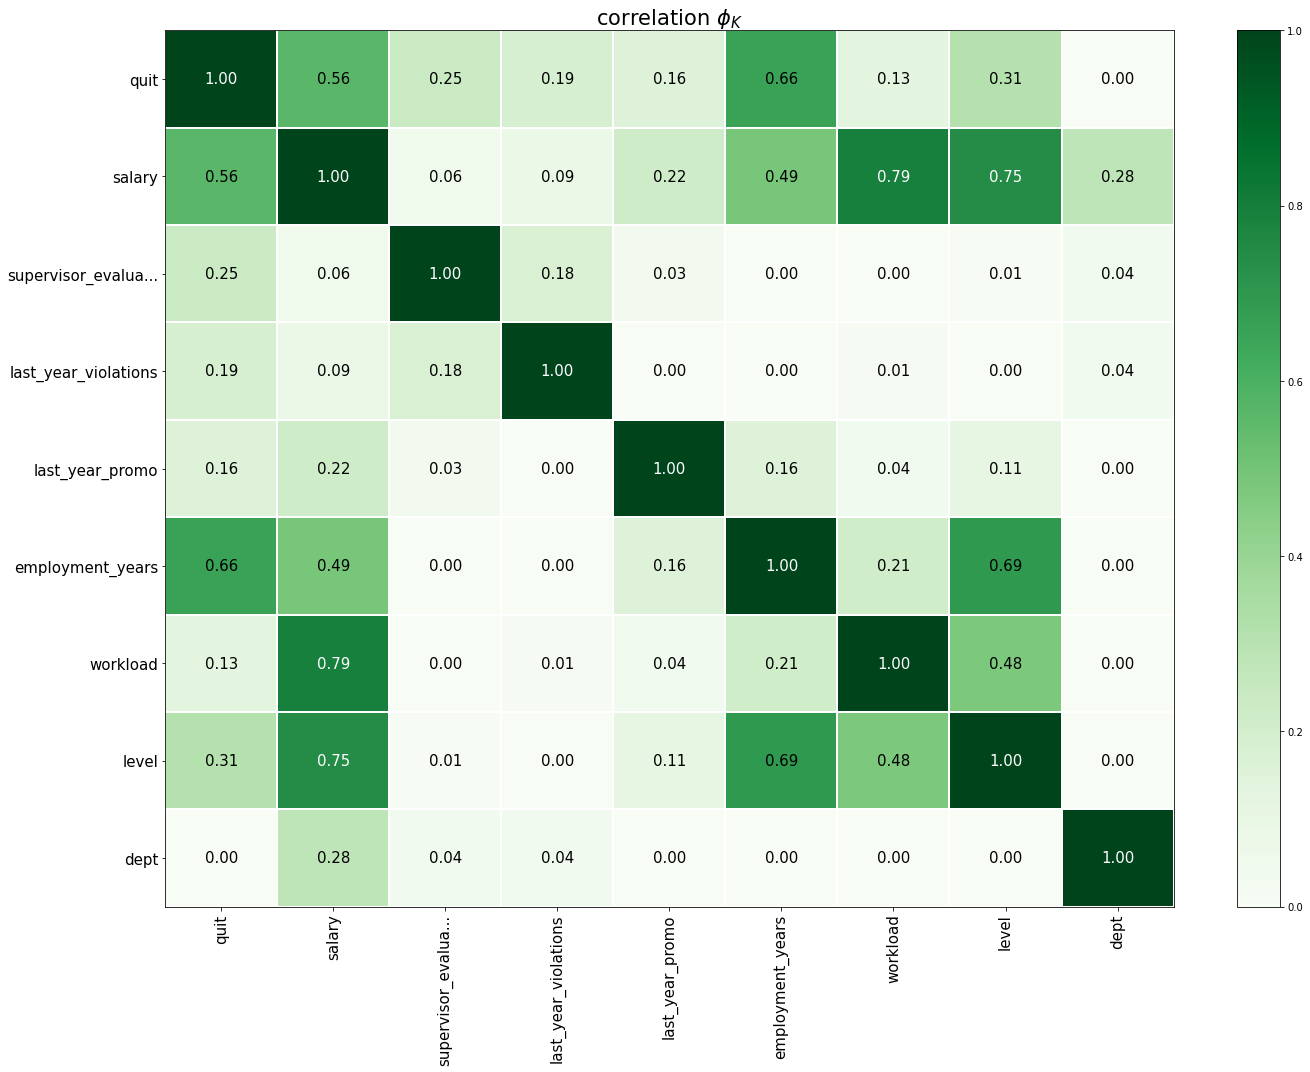

In [ ]:
# матрица корреляции 2
plot_correlation_matrix(
    phik_overview_q.values,
    x_labels=phik_overview_q.columns,
    y_labels=phik_overview_q.index,
    vmin=0, vmax=1, color_map='Greens',
    title=r'correlation $\phi_K$',
    fontsize_factor=1.5,
    figsize=(20, 15)
)

Наибольшую корреляцию (0.79) снова показали между собой признаки `'salary'` и `'workload'`, что недостаточно для того, чтобы говорить о мультиколлинеарности.

С целевым признаком `'quit'` проявили тесноту связи:

- заметную `'employment_years'`(коэфициент корреляции 0.66) и `'salary'`(0.56),

- умеренную `'level'`(0.31),

- слабую `'supervisor_evaluation'`(0.25), `'last_year_violations'`(0.19), `'last_year_promo'`(0.16),`'workload'`(0.13),

- не проявил вовсе `'dept'` (однако он коррелирует с `'salary'`, поэтому лучше его не исключать).
        
В остальном матрица корреляции аналогична таковой для тренировочного датасета из первой задачи.

***Выводы***

1. Поведение числовых и категорийных данных в датасете `'train_quit'` в целом повторяет аналогичные у датасетата `'train_job_satisfaction_rate'`.

2. Портрет уволившегося сотрудника: работал три или менее года и провел их на позиции "junior" с уровнем нагрузки "low".

3. При анализе матрицы корреляции phik обнаружено, что с целевым признаком `'quit'` проявили тесноту связи:

- заметную `'employment_years'`(коэфициент корреляции 0.66) и `'salary'`(0.56),

- умеренную `'level'`(0.31),

- слабую `'supervisor_evaluation'`(0.25), `'last_year_violations'`(0.19), `'last_year_promo'`(0.16),`'workload'`(0.13),

- не проявил вовсе `'dept'` (однако он коррелирует с `'salary'`, поэтому лучше его не исключать).
        
- в остальном матрица корреляции аналогична таковой для тренировочного датасета из первой задачи.

#### Проверка связи цевого признака с уровнем удовлетворенности

Матрица корреляции phik не обнаружила высокой тесноты связей имеющихся параметров с интересующим нас целевым, а это может означать сложности в обучении модели.

Поэтому, возможно будет полезно проверить утверждение аналитиков о том, что желание уволиться зависит от уровня удовлетворенности работников (которое также зависит от имеющихся параметров).

Для проверки этого утверждения построим матрицу корреляции для тестовых данных (так как для одних входящих данных мы имеем два известных целевых признака - для прошлой задачи, который теперь стал интересен как новый параметр, и для текущей, зависимость с которым мы хотим установить)

In [ ]:
# присоединяем к ранее объединенным тестовым данным новый целевой признак
data_test_first = data_test_first.merge(test_target_quit, on='id', how='inner') # объединение

In [ ]:
data_test_first.head()

,id,dept,level,workload,employment_years,last_year_promo,last_year_violations,supervisor_evaluation,salary,job_satisfaction_rate,quit
0,485046,marketing,junior,medium,2,no,no,5,28800,0.79,no
1,686555,hr,junior,medium,1,no,no,4,30000,0.72,no
2,467458,sales,middle,low,5,no,no,4,19200,0.64,no
3,418655,sales,middle,low,6,no,no,4,19200,0.60,no
4,789145,hr,middle,medium,5,no,no,5,40800,0.75,no


In [ ]:
data_test_first.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 2000 entries, 0 to 1999
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   id                     2000 non-null   int64  
 1   dept                   1997 non-null   object 
 2   level                  1999 non-null   object 
 3   workload               1999 non-null   object 
 4   employment_years       2000 non-null   int64  
 5   last_year_promo        2000 non-null   object 
 6   last_year_violations   2000 non-null   object 
 7   supervisor_evaluation  2000 non-null   int64  
 8   salary                 2000 non-null   int64  
 9   job_satisfaction_rate  2000 non-null   float64
 10  quit                   2000 non-null   object 
dtypes: float64(1), int64(4), object(6)
memory usage: 187.5+ KB


Объединение прошло успешно. Теперь построем матрицу корреляции.

In [ ]:
# считаем корреляции
phik_overview_st = data_test_first.drop('id', axis=1).phik_matrix(interval_cols=interval_cols)

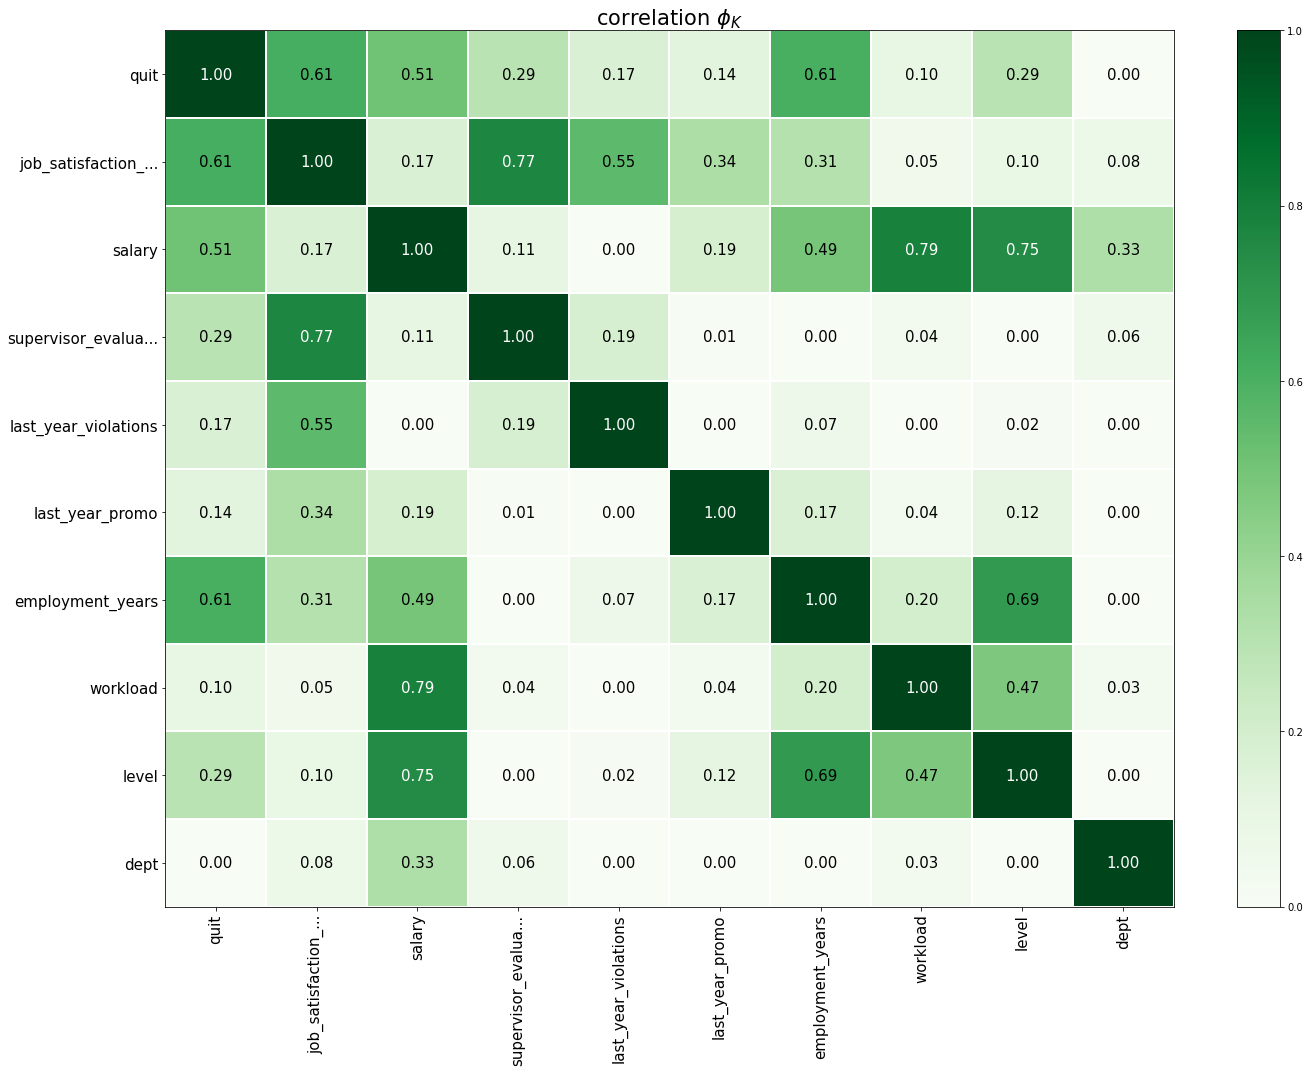

In [ ]:
# матрица корреляции 2
plot_correlation_matrix(
    phik_overview_st.values,
    x_labels=phik_overview_st.columns,
    y_labels=phik_overview_st.index,
    vmin=0, vmax=1, color_map='Greens',
    title=r'correlation $\phi_K$',
    fontsize_factor=1.5,
    figsize=(20, 15)
)

У целевого признака появилась дополнительная связь - коэфициент корреляции `'quit'` с `'job_satisfaction_rate'` составил 0.61, что говорит о заметном уровне тесноты связи.

К тому же новый признак, как мы помним и как можем наблюдать теперь, имеет дополнительные связи с оcтальными параметрами. А значит, с его введением модели должно стать проще предсказывать верный результат.

Взглянем на его распределение для оставшихся и уволившихся сотрудников.

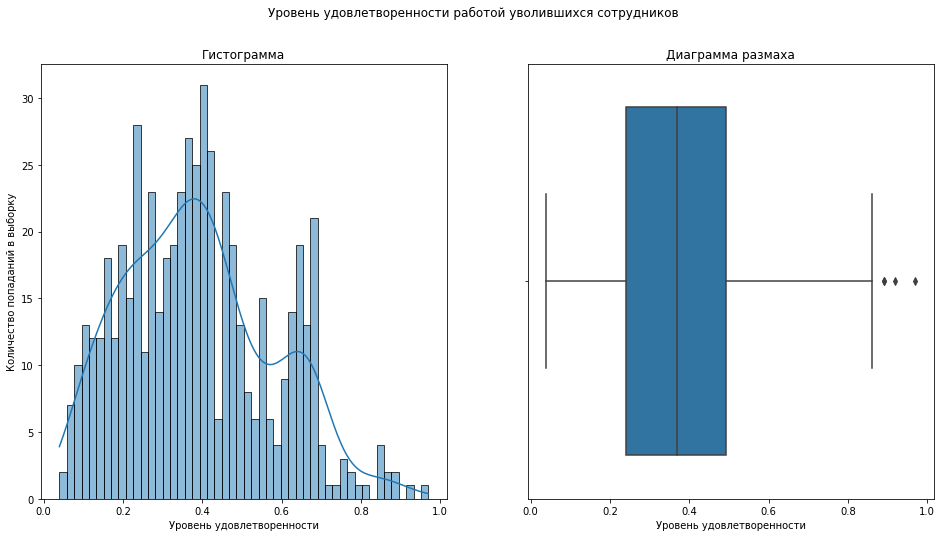

In [ ]:
# уровень удовлетворенности работой в компании, диаграмма размаха и гистограмма
fig, axs = plt.subplots(nrows= 1 , ncols= 2, figsize = (16,8))
sns.histplot(data = data_test_first[data_test_first['quit']=='yes'], x = 'job_satisfaction_rate', ax=axs[0],\
             bins = 50, kde=True)
axs[0].set_xlabel('Уровень удовлетворенности')
axs[0].set_ylabel('Количество попаданий в выборку')
axs[0].set_title('Гистограмма')
sns.boxplot(data = data_test_first[data_test_first['quit']=='yes'], x = 'job_satisfaction_rate', ax=axs[1])
axs[1].set_xlabel('Уровень удовлетворенности')
axs[1].set_title('Диаграмма размаха')
fig.suptitle('Уровень удовлетворенности работой уволившихся сотрудников')
plt.show()

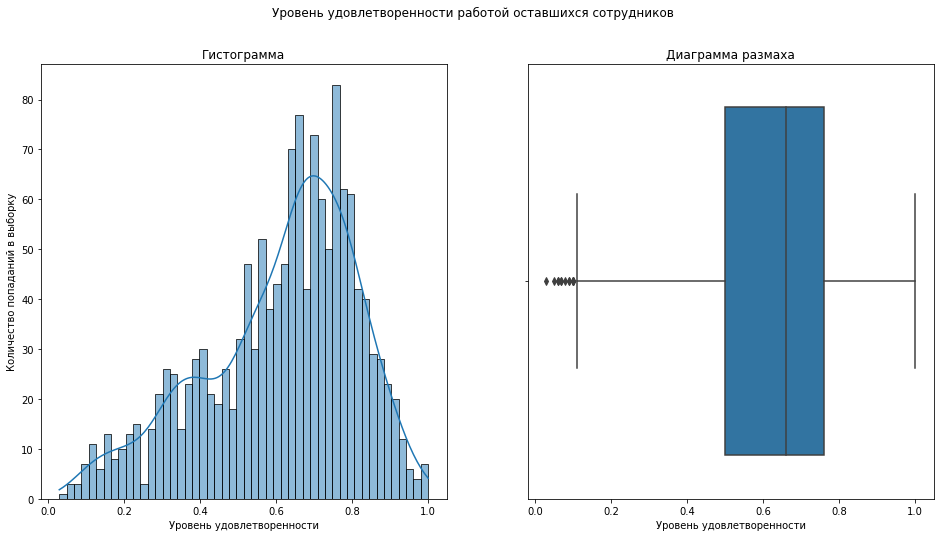

In [ ]:
# уровень удовлетворенности работой в компании, диаграмма размаха и гистограмма
fig, axs = plt.subplots(nrows= 1 , ncols= 2, figsize = (16,8))
sns.histplot(data = data_test_first[data_test_first['quit']!='yes'], x = 'job_satisfaction_rate', ax=axs[0],\
             bins = 50, kde=True)
axs[0].set_xlabel('Уровень удовлетворенности')
axs[0].set_ylabel('Количество попаданий в выборку')
axs[0].set_title('Гистограмма')
sns.boxplot(data = data_test_first[data_test_first['quit']!='yes'], x = 'job_satisfaction_rate', ax=axs[1])
axs[1].set_xlabel('Уровень удовлетворенности')
axs[1].set_title('Диаграмма размаха')
fig.suptitle('Уровень удовлетворенности работой оставшихся сотрудников')
plt.show()

Обе гистограммы (для уволившихся и для оставшихся) имеют два пика. Но главный из них смещен влево (медиана находитися приблизительно на уровне 0.38), а у оставшихся - вправо (медиана приблизительно на 0.65).

То есть можно утверждать, что уровень удовлетворенности работой у уволившихся сотрудников существенно ниже, чем у оставшихся. А значит данный признак будет нам полезен для предсказания.

**Выводы**

1. Доля уволившихся сотрудников составляет больше четверти от всех. Это объясняет заинтересованность заказчика в результатах исследования.

2. Поведение числовых и категорийных данных в датасете `'train_quit'` в целом повторяет аналогичные у датасетата `'train_job_satisfaction_rate'`.

3. Портрет уволившегося сотрудника: работал три или менее года и провел их на позиции "junior" с уровнем нагрузки "low", имел низкий уровень удовлетворенности работой.

4. При анализе матрицы корреляции phik обнаружено, что с целевым признаком `'quit'` проявили тесноту связи:

- заметную `'employment_years'`(коэфициент корреляции 0.66) и `'salary'`(0.56),

- умеренную `'level'`(0.31),

- слабую `'supervisor_evaluation'`(0.25), `'last_year_violations'`(0.19), `'last_year_promo'`(0.16),`'workload'`(0.13),

- не проявил вовсе `'dept'` (однако он коррелирует с `'salary'`, поэтому лучше его не исключать).
        
- в остальном матрица корреляции аналогична таковой для тренировочного датасета из первой задачи.

5. Анализ матрицы корреляции, построенной на основе тестовых данных к обеим задачам, а также распределение данного признака для уволившихся и оставшихся работников выявило подтверждение теории аналитиков о том, что уровень удовлетворенности сотрудника в компании влияет на то, уволится ли сотрудник. В целом уволившиеся работники были гораздо менее удовлетворены своей работой, чем оставшиеся.

### Добавление нового входного признака

Как мы уже выяснили ранее, уровень удовлетворенности работой связан с тем, уволится рабоник или нет. У нас нет данного параметра для текущей тренирововчной выборки, но мы уже научились его предсказывать с высокой точностью ранее на основании имеющихся прараметров.

Для начала подготовим данные `'train_quit'` из для работы с моделью из первой задачи.

In [ ]:
# преобразуем для работы с моделью
train_quit_first = pd.DataFrame(
    data_preprocessor.transform(train_quit),
    columns=data_preprocessor.transformers_[0][1][1].get_feature_names_out().tolist() + num_columns + ord_columns
)

In [ ]:
train_quit_first.head() # проверка

,x0_marketing,x0_purchasing,x0_sales,x0_technology,x1_yes,x2_yes,employment_years,supervisor_evaluation,salary,level,workload
0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,2.0,0.111111,0.75,0.486111
1,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.111111,0.75,0.180556
2,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.444444,0.00,0.291667
3,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.111111,0.50,0.138889
4,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.111111,1.00,0.152778


Теперь передадим его нашей лучшей модели найденной в задаче 1 для получения предсказания, а затем добавим данный признак к нашему тренировочному датасету.

In [ ]:
# создаем новый столбец на основе предсказания
train_quit['job_satisfaction_rate'] = best_model_sat.predict(train_quit_first)

In [ ]:
train_quit.head() # проверка

,id,dept,level,workload,employment_years,last_year_promo,last_year_violations,supervisor_evaluation,salary,quit,job_satisfaction_rate
0,723290,sales,middle,high,2,no,no,4,54000,no,0.63875
1,814010,sales,junior,medium,2,no,no,4,27600,no,0.82450
2,155091,purchasing,middle,medium,5,no,no,1,37200,no,0.34000
3,257132,sales,junior,medium,2,no,yes,3,24000,yes,0.34000
4,910140,marketing,junior,medium,2,no,no,5,25200,no,0.69000


In [ ]:
train_quit.info() # проверка

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   id                     4000 non-null   int64  
 1   dept                   4000 non-null   object 
 2   level                  4000 non-null   object 
 3   workload               4000 non-null   object 
 4   employment_years       4000 non-null   int64  
 5   last_year_promo        4000 non-null   object 
 6   last_year_violations   4000 non-null   object 
 7   supervisor_evaluation  4000 non-null   int64  
 8   salary                 4000 non-null   int64  
 9   quit                   4000 non-null   object 
 10  job_satisfaction_rate  4000 non-null   float64
dtypes: float64(1), int64(4), object(6)
memory usage: 343.9+ KB


Добавление прошло успешно. На всякий случай еще раз взглянем на матрицу корреляции обновленного датасета.

In [ ]:
# считаем корреляции
phik_overview_q = train_quit.drop('id', axis=1).phik_matrix(interval_cols=interval_cols)

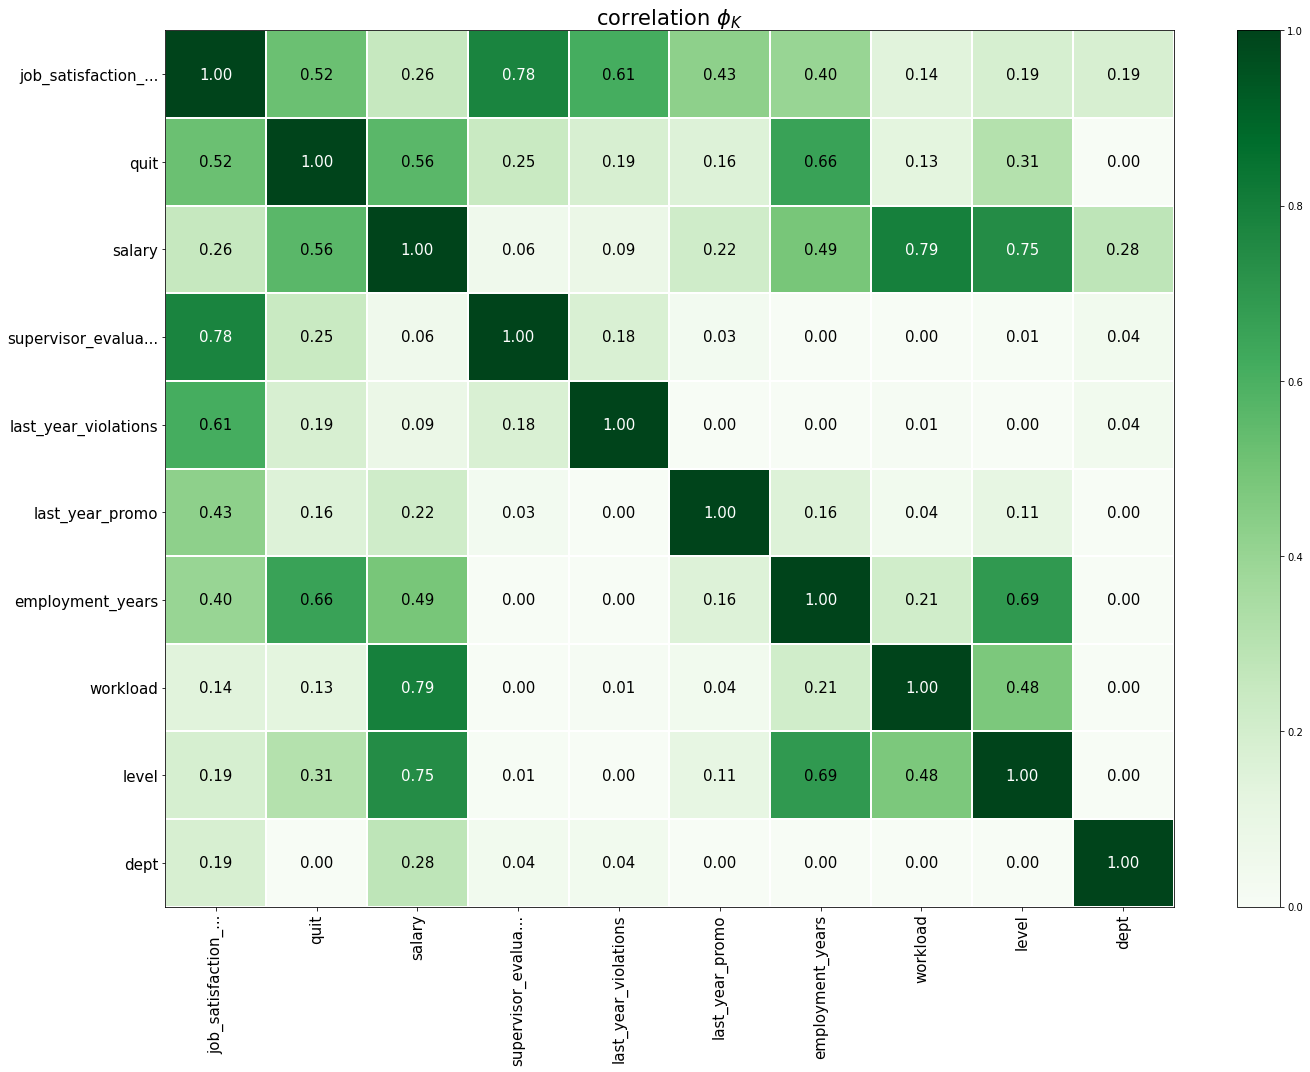

In [ ]:
# матрица корреляции 2
plot_correlation_matrix(
    phik_overview_q.values,
    x_labels=phik_overview_q.columns,
    y_labels=phik_overview_q.index,
    vmin=0, vmax=1, color_map='Greens',
    title=r'correlation $\phi_K$',
    fontsize_factor=1.5,
    figsize=(20, 15)
)

Полученные коэфициенты не совпадают полностью по значениям с тестовой выборкой (что логично, ведь  данные-то другие, плюс предсказывающая модель имеет некоторую погрешность в своих предсказаниях), но в целом достаточно близки (что указывает на их правдоподобность), поэтому полученные таким образом данные признака можно использовать для предсказания увольнения сотрудника.

**Выводы**

Предсказание нового входящего признака `'job_satisfaction_rate'` и присоединение его к датасету с тренировочными данными `'train_quit'` прошло успешно.

### Подготовка данных

Теперь нам предстоит подготовить данные для работы с моделью.

In [ ]:
target_cl = 'quit' # задаем целевой признак

#### Разбиение на выборки

На данный момент у нас есть отдельно выборка с обновленными тестовыми данными и сшитая воедино с целевым признаком тестовая выборка.

Приступим к разделению по признакам.

In [ ]:
X_train_sec = train_quit.drop([target_cl, 'id'], axis=1) # получение входных признаков тренировочной выборки

In [ ]:
X_train_sec.head() # проверка

,dept,level,workload,employment_years,last_year_promo,last_year_violations,supervisor_evaluation,salary,job_satisfaction_rate
0,sales,middle,high,2,no,no,4,54000,0.63875
1,sales,junior,medium,2,no,no,4,27600,0.82450
2,purchasing,middle,medium,5,no,no,1,37200,0.34000
3,sales,junior,medium,2,no,yes,3,24000,0.34000
4,marketing,junior,medium,2,no,no,5,25200,0.69000


In [ ]:
y_train_sec = train_quit[target_cl] # отделение целевого признака тестовой выборки

In [ ]:
y_train_sec.head() # проверка

0     no
1     no
2     no
3    yes
4     no
Name: quit, dtype: object

In [ ]:
X_test_sec = data_test_first.drop([target_cl, 'id'], axis=1) # получение входных признаков тестовой выборки

In [ ]:
X_test_sec.head() # проверка

,dept,level,workload,employment_years,last_year_promo,last_year_violations,supervisor_evaluation,salary,job_satisfaction_rate
0,marketing,junior,medium,2,no,no,5,28800,0.79
1,hr,junior,medium,1,no,no,4,30000,0.72
2,sales,middle,low,5,no,no,4,19200,0.64
3,sales,middle,low,6,no,no,4,19200,0.60
4,hr,middle,medium,5,no,no,5,40800,0.75


In [ ]:
y_test_sec = data_test_first[target_cl] # отделение целевого признака тестовой выборки

In [ ]:
y_test_sec.head() # проверка

0    no
1    no
2    no
3    no
4    no
Name: quit, dtype: object

***Выводы***

Отделение входящих признаков от целевого для тренировочных и тестовых данных прошло успешно.

#### Кодировка целевого признака

В отличие от первой, наш целевой признак в текущей задаче является классом. А значит, для работы с моделью его нужно закодировать.

Зделаем это с помощью LabelEncoder, присвоив увольнению ([`'quit'`]=='yes') 1 как более волнующему нас признаку, а не-увольнению ([`'quit'`]=='no') присвоим 0.

In [ ]:
y_train_sec.value_counts() # подсчет значений для проверки

no     2872
yes    1128
Name: quit, dtype: int64

In [ ]:
# задаем классы в правильном порядке, чтобы yes стал равен 1, no - 0
original_classes = ['yes', 'no']

In [ ]:
# создаем экземпляр класса LabelEncoder для кодирования целевого признака
label_encoder = LabelEncoder()

In [ ]:
# передаем классы энкодеру
label_encoder.classes = np.array(original_classes)

In [ ]:
# обучаем модель и трансформируем тренировочную выборку
y_train_sec = label_encoder.fit_transform(y_train_sec)

In [ ]:
pd.DataFrame(y_train_sec).value_counts() # подсчет значений заново

0    2872
1    1128
dtype: int64

Количество единиц совпало со количеством значения 'yes' ранее, а значит кодировка прошла успешно.

Повторим на тестовой выборке.

In [ ]:
# трансформируем тестовую выборку
y_test_sec = label_encoder.transform(y_test_sec)

***Выводы***

Кодирование целевого признака прошло успешно.

#### Преобразование данных: начало

Для подготовки данных мы можем использовать тот же пайплайн, что и ранее, лишь исправив список столбцов ввиду появления нового входного признака, который ранее был целевым.

А чтобы не нарушать работу предыдущего пайплана, поправим связанные с данным изменением шаги.

In [ ]:
# масштабирование, числовые
num_columns_new = [
    'employment_years',
    'supervisor_evaluation',
    'salary',
    'job_satisfaction_rate'
    ]

In [ ]:
# объединяем шаги подготовки, исходный скалер исправили на тот, что лучше себя показал позже
data_preprocessor_sec = ColumnTransformer(
    [
        ('ohe', ohe_pipe, ohe_columns),
        ('ord', ord_pipe, ord_columns),
        ('num', RobustScaler(), num_columns_new) # указываем один скалер из планируемых, далее будем их уточнять
    ],
    remainder='passthrough' # позволяет не трогать данные, не вошедшие в списки выше
)

***Выводы***

Пайплан подготовки данных успешно изменен.

### Итоговый пайплайн: подготовка данных и модель

Теперь мы можем собрать итоговый пайплайн, включив туда подготовку данных и использование моделей, а затем (уже отдельно) дополнительно уточнить варианты применяемого к данным масштабирования и варианты моделей и их параметров.

In [ ]:
# создаём итоговый пайплайн: подготовка данных и модель
pipe_final_sec = Pipeline(
    [
        ('preprocessor', data_preprocessor_sec),
        # указываем любую модель из планируемых, так как далее будем их уточнять
        ('models', DecisionTreeClassifier(random_state=RANDOM_STATE))
    ]
)

Для решения задачи регрессии попробуем использовать модели с разной логикой: Линейные (Логистическую регрессию и Метод опорных векторов), а также Дерево решений и k-ближайших соседей.

Список скелеров оставим прежним.

In [ ]:
# описание моделей и их гиперпараметров
param_grid_cl = [
    # словарь для модели DecisionTreeClassifier()
    {
        'models': [DecisionTreeClassifier(random_state=RANDOM_STATE)],
        'models__max_depth': range(2, 12),
        'models__max_features': range(2, 12),
        'preprocessor__num': skel
    },

    # словарь для модели KNeighborsClassifier()
    {
        'models': [KNeighborsClassifier()],
        'models__n_neighbors': range(2, 10),
        'preprocessor__num': skel
    },

    # словарь для модели SVC(), probability=True нужно для возможности получать вероятность (напр. для pedict_proba и SHAP)
    {
        'models': [SVC(random_state=RANDOM_STATE, probability=True)],
        'models__kernel': ['linear', 'rbf', 'sigmoid'], # варианты ядер
        'models__C': range(1, 10), # сложность модели
        'preprocessor__num': skel
    },

    # словарь для модели LogisticRegression()
    {
        'models': [LogisticRegression(
            random_state=RANDOM_STATE,
            penalty='elasticnet', # регуляризация, смешанный вариант штрафов
            solver='saga' # saga - для l1 и elasticnet
        )],
        'models__C': range(1, 10), # сложность модели
        'preprocessor__num': skel
    }
]

Метрикой, на которую мы будем ориентироваться, будет `'ROC-AUC'`: площадь под ROC-кривой, которая показывает зависимость TPR(доля верно классифицированных объектов класса 1) и FPR (доля неверно классифицированных объектов класса 0). Она не зависит от дисбаланса классов и выбранного порога вероятности (оценивает качество решений модели в наиболее общем виде, учитывая все возможные пороговые значения) и применима к разным моделям. Поэтому именно данная метрика позволит правильно оценить качество работы разных моделей как на имеющихся данных, так и на будущих.

Видимо именно поэтому ее и выбрал заказчик. Критерием успеха, согласно требованию, будет ROC-AUC ≥0.91 на тестовой выборке.

Для экономии времени будем использовать случайный перебор RandomizedSearchCV().

In [ ]:
# перебор параметров случайный
randomized_search_cl = RandomizedSearchCV(
    pipe_final_sec,
    param_grid_cl,
    cv=5,
    scoring='roc_auc',
    random_state=RANDOM_STATE,
    n_jobs=-1
)

In [ ]:
randomized_search_cl.fit(X_train_sec, y_train_sec) # тренируем модель

RandomizedSearchCV(cv=5,
                   estimator=Pipeline(steps=[('preprocessor',
                                              ColumnTransformer(remainder='passthrough',
                                                                transformers=[('ohe',
                                                                               Pipeline(steps=[('simpleImputer_ohe',
                                                                                                SimpleImputer(strategy='most_frequent')),
                                                                                               ('ohe',
                                                                                                OneHotEncoder(drop='first',
                                                                                                              handle_unknown='ignore',
                                                                                                              sparse_output=False))]),
                                                                               ['dept',
                                                                                'last_year_promo',
                                                                                'last_year_violations']),
                                                                              ('ord',
                                                                               Pip...
                                         'models__kernel': ['linear', 'rbf',
                                                            'sigmoid'],
                                         'preprocessor__num': [StandardScaler(),
                                                               MinMaxScaler(),
                                                               RobustScaler(),
                                                               'passthrough']},
                                        {'models': [LogisticRegression(penalty='elasticnet',
                                                                       random_state=42,
                                                                       solver='saga')],
                                         'models__C': range(1, 10),
                                         'preprocessor__num': [StandardScaler(),
                                                               MinMaxScaler(),
                                                               RobustScaler(),
                                                               'passthrough']}],
                   random_state=42, scoring='roc_auc')

In [ ]:
# параметры лучшей модели
print('Параметры лучшей модели для RandomizedSearchCV:\n', randomized_search_cl.best_params_)
# лучшее значение метрики
print('\nМетрика ROC-AUC лучшей модели на тренировочной выборке:', randomized_search_cl.best_score_)
# метрика на тестовой выборке
print(f'\nМетрика ROC-AUC на тестовой выборке:\
{roc_auc_score(y_test_sec, randomized_search_cl.predict_proba(X_test_sec)[:,1])}')

Параметры лучшей модели для RandomizedSearchCV:
 {'preprocessor__num': RobustScaler(), 'models__kernel': 'rbf', 'models__C': 6, 'models': SVC(probability=True, random_state=42)}

Метрика ROC-AUC лучшей модели на тренировочной выборке: 0.9260097385917959

Метрика ROC-AUC на тестовой выборке:0.9314536043778028


In [ ]:
# результаты обучения всех моделей
pd.set_option('display.max_rows', None) # если захотим увидеть действительно все
pd.DataFrame(randomized_search_cl.cv_results_).sort_values(by='rank_test_score', ascending=True)

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_preprocessor__num,param_models__max_features,param_models__max_depth,param_models,param_models__kernel,param_models__C,param_models__n_neighbors,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
3,0.818291,0.019326,0.048889,0.004895,RobustScaler(),NaN,NaN,"SVC(probability=True, random_state=42)",rbf,6.0,NaN,"{'preprocessor__num': RobustScaler(), 'models_...",0.911648,0.924846,0.925658,0.928814,0.939082,0.926010,0.008792,1
1,0.029838,0.003919,0.012232,0.002210,RobustScaler(),11.0,4.0,DecisionTreeClassifier(random_state=42),NaN,NaN,NaN,"{'preprocessor__num': RobustScaler(), 'models_...",0.922783,0.914238,0.930032,0.916638,0.925496,0.921837,0.005766,2
0,0.029167,0.003617,0.011213,0.001073,RobustScaler(),10.0,7.0,DecisionTreeClassifier(random_state=42),NaN,NaN,NaN,"{'preprocessor__num': RobustScaler(), 'models_...",0.908885,0.916719,0.914341,0.923133,0.933860,0.919388,0.008560,3
6,0.024529,0.003356,0.009295,0.000419,passthrough,6.0,8.0,DecisionTreeClassifier(random_state=42),NaN,NaN,NaN,"{'preprocessor__num': 'passthrough', 'models__...",0.905689,0.912286,0.915085,0.904181,0.930479,0.913544,0.009382,4
2,0.028106,0.001554,0.010936,0.000400,RobustScaler(),8.0,10.0,DecisionTreeClassifier(random_state=42),NaN,NaN,NaN,"{'preprocessor__num': RobustScaler(), 'models_...",0.868545,0.903065,0.893944,0.889396,0.923819,0.895754,0.018028,5
4,0.028600,0.002663,0.020403,0.000454,RobustScaler(),NaN,NaN,KNeighborsClassifier(),NaN,NaN,2.0,"{'preprocessor__num': RobustScaler(), 'models_...",0.881585,0.891915,0.882955,0.879745,0.889789,0.885198,0.004775,6
9,0.026783,0.001807,0.010847,0.000894,StandardScaler(),7.0,11.0,DecisionTreeClassifier(random_state=42),NaN,NaN,NaN,"{'preprocessor__num': StandardScaler(), 'model...",0.881476,0.911729,0.868174,0.862782,0.896835,0.884199,0.018114,7
5,0.026161,0.002665,0.019393,0.002494,StandardScaler(),NaN,NaN,KNeighborsClassifier(),NaN,NaN,2.0,"{'preprocessor__num': StandardScaler(), 'model...",0.873086,0.895409,0.871689,0.862524,0.899895,0.880520,0.014520,8
7,0.023790,0.002293,0.010076,0.000817,MinMaxScaler(),9.0,2.0,DecisionTreeClassifier(random_state=42),NaN,NaN,NaN,"{'preprocessor__num': MinMaxScaler(), 'models_...",0.853662,0.860939,0.873747,0.845996,0.878365,0.862542,0.012092,9
8,0.023907,0.001602,0.011170,0.001363,RobustScaler(),2.0,4.0,DecisionTreeClassifier(random_state=42),NaN,NaN,NaN,"{'preprocessor__num': RobustScaler(), 'models_...",0.810238,0.828201,0.856838,0.821429,0.837894,0.830920,0.015784,10


Результат хорош с первой попытки - 0.9314 на тестовой при желаемом 0.91 и более. Но - не идеален.

SVM заняло первое место, однако дерево решений и kNN чаще показывают лучший результат (и к тому же SVM не самая удобная модель для интерпритации и в приницпе в работе с иными методами).

Учтем это и попробуем немного поработать с признаками, чтобы улучшить модель. Как мы помним, признак отдела практически ни с чем (тем более - с целевым признакам) не коррелировал (выдавая слабые связи лишь с уровнем удовлетворенности и зарплатой).

Попробуем его удалить и скормить предварительно лучшей модели - SVM(). Для данного перебора, как и ранее, попробуем использовать OptunaSearchCV().

Но сначала сохраним лучшую модель из полученного, на всякий случай.

In [ ]:
# сохраняем лучшую модель данной попытки
best_model_class_first = randomized_search_cl.best_estimator_

Начнем с подготовки данных.

In [ ]:
X_train_sec_n = X_train_sec.drop('dept', axis = 1) # удаляем малозначимый признак у тренировочной выборки

In [ ]:
X_train_sec_n.head() # проверка 1

,level,workload,employment_years,last_year_promo,last_year_violations,supervisor_evaluation,salary,job_satisfaction_rate
0,middle,high,2,no,no,4,54000,0.63875
1,junior,medium,2,no,no,4,27600,0.82450
2,middle,medium,5,no,no,1,37200,0.34000
3,junior,medium,2,no,yes,3,24000,0.34000
4,junior,medium,2,no,no,5,25200,0.69000


In [ ]:
X_train_sec_n.shape # проверка 2

(4000, 8)

In [ ]:
X_test_sec_n = X_test_sec.drop('dept', axis = 1) # удаляем малозначимый признак у тестовой выборки

In [ ]:
X_test_sec_n.head() # проверка 1

,level,workload,employment_years,last_year_promo,last_year_violations,supervisor_evaluation,salary,job_satisfaction_rate
0,junior,medium,2,no,no,5,28800,0.79
1,junior,medium,1,no,no,4,30000,0.72
2,middle,low,5,no,no,4,19200,0.64
3,middle,low,6,no,no,4,19200,0.60
4,middle,medium,5,no,no,5,40800,0.75


In [ ]:
X_test_sec_n.shape  # проверка 2

(2000, 8)

In [ ]:
data_preprocessor_sec # смотрим наш пайплайн подготовки

ColumnTransformer(remainder='passthrough',
                  transformers=[('ohe',
                                 Pipeline(steps=[('simpleImputer_ohe',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('ohe',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore',
                                                                sparse_output=False))]),
                                 ['dept', 'last_year_promo',
                                  'last_year_violations']),
                                ('ord',
                                 Pipeline(steps=[('simpleImputer_before_ord',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('ord',
                                                  OrdinalEncoder(categories=[['junior',
                                                                              'middle',
                                                                              'sinior'],
                                                                             ['low',
                                                                              'medium',
                                                                              'high']],
                                                                 handle_unknown='use_encoded_value',
                                                                 unknown_value=nan)),
                                                 ('simpleImputer_after_ord',
                                                  SimpleImputer(strategy='most_frequent'))]),
                                 ['level', 'workload']),
                                ('num', RobustScaler(),
                                 ['employment_years', 'supervisor_evaluation',
                                  'salary', 'job_satisfaction_rate'])])

В пайплайне скалером по-умолчанию является RobustScaler(), который хорошо показал себя у предварительно лучшей модели. Поэтому, оставим так.

Только изменим список с подлежащими OHE-кодированию параметрами.

In [ ]:
ohe_columns # вспоминаем содержимое

['dept', 'last_year_promo', 'last_year_violations']

In [ ]:
ohe_columns_new = ['last_year_promo', 'last_year_violations'] # удаляем малозначимый параметр

In [ ]:
ohe_columns_new # проверка

['last_year_promo', 'last_year_violations']

In [ ]:
# обновляем пайплайн
data_preprocessor_sec_opt = ColumnTransformer(
    [
        ('ohe', ohe_pipe, ohe_columns_new),
        ('ord', ord_pipe, ord_columns),
        ('num', RobustScaler(), num_columns_new) # указываем один скалер из планируемых, далее будем их уточнять
    ],
    remainder='passthrough' # позволяет не трогать данные, не вошедшие в списки выше
)

Преобразуем наши входные признаки с помощью пайплайна.

In [ ]:
# трансформируем с обучением X_train препроцессором
X_train_opt_svm = pd.DataFrame(
    data_preprocessor_sec_opt.fit_transform(X_train_sec_n),
    # вытаскиваем имена столбцов через get_feature_names_out()
    columns=data_preprocessor_sec_opt.transformers_[0][1][1].get_feature_names_out().tolist() + num_columns_new + ord_columns
)

In [ ]:
X_train_opt_svm.head() # проверка 1

,x0_yes,x1_yes,employment_years,supervisor_evaluation,salary,job_satisfaction_rate,level,workload
0,0.0,0.0,1.0,2.0,-0.25,0.0,1.176471,0.288143
1,0.0,0.0,0.0,1.0,-0.25,0.0,-0.117647,0.842620
2,0.0,0.0,1.0,1.0,0.50,-3.0,0.352941,-0.603648
3,0.0,1.0,0.0,1.0,-0.25,-1.0,-0.294118,-0.603648
4,0.0,0.0,0.0,1.0,-0.25,1.0,-0.235294,0.441128


In [ ]:
X_train_opt_svm.shape # проверка 2

(4000, 8)

In [ ]:
# аналогично преобразуем X_test
X_test_opt_svm = pd.DataFrame(
    data_preprocessor_sec_opt.transform(X_test_sec_n),
    columns=data_preprocessor_sec_opt.transformers_[0][1][1].get_feature_names_out().tolist() + num_columns_new + ord_columns
)

In [ ]:
X_test_opt.head() # проверка 1

,x0_marketing,x0_purchasing,x0_sales,x0_technology,x1_yes,x2_yes,employment_years,supervisor_evaluation,salary,level,workload
0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.111111,1.00,0.194444
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.000000,0.75,0.208333
2,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.444444,0.75,0.083333
3,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.555556,0.75,0.083333
4,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.444444,1.00,0.333333


In [ ]:
X_test_opt.shape # проверка 2

(2000, 11)

Теперь попробуем передать эти данные для перебора.

In [ ]:
# Задаем функцию для поиска лучших гиперпараметров:
def objective(trial):
    # Определяем гиперпараметры
    C = trial.suggest_loguniform('C', 1, 10)
    kernel = trial.suggest_categorical('kernel', ['linear', 'rbf', 'poly', 'sigmoid'])

    # Создаем модель с выбранными гиперпараметрами
    clf = SVC(C=C, kernel=kernel, random_state=RANDOM_STATE, probability=True)
    clf.fit(X_train_opt_svm, y_train_sec)

    # Оцениваем модель на тестовой выборке
    preds_prob = clf.predict_proba(X_test_opt_svm)
    roc_auc = roc_auc_score(y_test_sec, preds_prob[:, 1])

    return roc_auc

In [ ]:
# Создаем объект исследования Optuna:
study = optuna.create_study(direction='maximize')

[I 2024-10-05 20:34:47,242] A new study created in memory with name: no-name-38c74187-9102-40b1-9508-a217629f5727


In [ ]:
# Запускаем процесс оптимизации:
study.optimize(objective, n_trials=100)

[I 2024-10-05 20:34:48,354] Trial 0 finished with value: 0.9302448191390585 and parameters: {'C': 2.4852279307054213, 'kernel': 'rbf'}. Best is trial 0 with value: 0.9302448191390585.
[I 2024-10-05 20:34:50,232] Trial 1 finished with value: 0.9072766648886783 and parameters: {'C': 6.177290712533965, 'kernel': 'linear'}. Best is trial 0 with value: 0.9302448191390585.
[I 2024-10-05 20:34:51,555] Trial 2 finished with value: 0.9072741954602026 and parameters: {'C': 1.5845134355675372, 'kernel': 'linear'}. Best is trial 0 with value: 0.9302448191390585.
[I 2024-10-05 20:34:53,192] Trial 3 finished with value: 0.7646968035717814 and parameters: {'C': 6.253135475627796, 'kernel': 'sigmoid'}. Best is trial 0 with value: 0.9302448191390585.
[I 2024-10-05 20:34:54,653] Trial 4 finished with value: 0.9072643177463008 and parameters: {'C': 2.2177953102334422, 'kernel': 'linear'}. Best is trial 0 with value: 0.9302448191390585.
[I 2024-10-05 20:34:55,741] Trial 5 finished with value: 0.9295354758

In [ ]:
# Выводим лучшие параметры
print('Параметры лучшей модели для Optuna:\n', study.best_params)

Параметры лучшей модели для Optuna:
 {'C': 3.2450058801811332, 'kernel': 'rbf'}


In [ ]:
# создаем модель на основе лучших параметров
optimised_regr = SVC(kernel=study.best_params['kernel'], C=study.best_params['C'],\
                     random_state=RANDOM_STATE, probability=True)

In [ ]:
# тренируем ее
optimised_regr.fit(X_train_opt_svm, y_train_sec)

SVC(C=3.2450058801811332, probability=True, random_state=42)

In [ ]:
# лучшее значение метрики
print('\nМетрика ROC-AUC лучшей модели на тренировочной выборке:',\
      {roc_auc_score(y_train_sec, optimised_regr.predict_proba(X_train_opt_svm)[:,1])})


Метрика ROC-AUC лучшей модели на тренировочной выборке: {0.9390549682431498}


In [ ]:
# метрика на тестовой выборке
print(f'\nМетрика ROC-AUC на тестовой выборке:\
{roc_auc_score(y_test_sec, optimised_regr.predict_proba(X_test_opt_svm)[:,1])}')


Метрика ROC-AUC на тестовой выборке:0.9305436199845907


Метрика неплоха, но сама модель SVC не очень дружелюбна. Поэтому попытаем счастья с другими, более удобными моделями.

Теперь вернемся к нашим пайплайнам.

Обновим его с учетом удаления признаков и удалим модель  LogisticRegression()так как в предыдущем испытаниях она вовсе не попала в топ (что логично, ведь она плохо улавливает сложные зависимости).

In [ ]:
# кодирование, номинальные
ohe_columns_new = [
    'last_year_promo',
    'last_year_violations'
    ]

In [ ]:
# масштабирование, числовые
num_columns_new = [
    'employment_years',
    'supervisor_evaluation',
    'salary',
    'job_satisfaction_rate'
    ]

In [ ]:
# объединяем шаги подготовки, исходный скалер исправили на тот, что лучше себя показал позже
data_preprocessor_new = ColumnTransformer(
    [
        ('ohe', ohe_pipe, ohe_columns_new),
        ('ord', ord_pipe, ord_columns),
        ('num', MinMaxScaler(), num_columns_new) # указываем один скалер из планируемых, далее будем их уточнять
    ],
    remainder='passthrough' # позволяет не трогать данные, не вошедшие в списки выше
)

In [ ]:
# создаём итоговый пайплайн: подготовка данных и модель
pipe_final_new = Pipeline(
    [
        ('preprocessor', data_preprocessor_new),
        # указываем любую модель из планируемых, так как далее будем их уточнять
        ('models', LinearRegression())
    ]
)

In [ ]:
# описание моделей и их гиперпараметров
param_grid_cl_new = [
    # словарь для модели DecisionTreeClassifier()
    {
        'models': [DecisionTreeClassifier(random_state=RANDOM_STATE)],
        'models__max_depth': range(2, 12),
        'models__max_features': range(2, 12),
        'preprocessor__num': skel
    },

    # словарь для модели KNeighborsClassifier()
    {
        'models': [KNeighborsClassifier()],
        'models__n_neighbors': range(2, 10),
        'preprocessor__num': skel
    },

    # словарь для модели SVC(), probability=True нужно для возможности получать вероятность (напр. для pedict_proba и SHAP)
    {
        'models': [SVC(random_state=RANDOM_STATE, probability=True)],
        'models__kernel': ['linear', 'rbf', 'sigmoid'], # варианты ядер
        'models__C': range(1, 15), # сложность модели
        'preprocessor__num': skel
    },

]

In [ ]:
# перебор параметров случайный
randomized_search_cl_new = RandomizedSearchCV(
    pipe_final_new,
    param_grid_cl_new,
    cv=5,
    scoring='roc_auc',
    random_state=RANDOM_STATE,
    n_jobs=-1
)

In [ ]:
randomized_search_cl_new.fit(X_train_sec_n, y_train_sec) # тренируем модель

RandomizedSearchCV(cv=5,
                   estimator=Pipeline(steps=[('preprocessor',
                                              ColumnTransformer(remainder='passthrough',
                                                                transformers=[('ohe',
                                                                               Pipeline(steps=[('simpleImputer_ohe',
                                                                                                SimpleImputer(strategy='most_frequent')),
                                                                                               ('ohe',
                                                                                                OneHotEncoder(drop='first',
                                                                                                              handle_unknown='ignore',
                                                                                                              sparse_output=False))]),
                                                                               ['last_year_promo',
                                                                                'last_year_violations']),
                                                                              ('ord',
                                                                               Pipeline(s...
                                         'models__n_neighbors': range(2, 10),
                                         'preprocessor__num': [StandardScaler(),
                                                               MinMaxScaler(),
                                                               RobustScaler(),
                                                               'passthrough']},
                                        {'models': [SVC(probability=True,
                                                        random_state=42)],
                                         'models__C': range(1, 15),
                                         'models__kernel': ['linear', 'rbf',
                                                            'sigmoid'],
                                         'preprocessor__num': [StandardScaler(),
                                                               MinMaxScaler(),
                                                               RobustScaler(),
                                                               'passthrough']}],
                   random_state=42, scoring='roc_auc')

In [ ]:
# параметры лучшей модели
print('Параметры лучшей модели для RandomizedSearchCV:\n', randomized_search_cl_new.best_params_)
# лучшее значение метрики
print('\nМетрика ROC-AUC лучшей модели на тренировочной выборке:', randomized_search_cl_new.best_score_)
# метрика на тестовой выборке
print(f'\nМетрика ROC-AUC на тестовой выборке:\
{roc_auc_score(y_test_sec, randomized_search_cl_new.predict_proba(X_test_sec_n)[:,1])}')

Параметры лучшей модели для RandomizedSearchCV:
 {'preprocessor__num': RobustScaler(), 'models__max_features': 9, 'models__max_depth': 4, 'models': DecisionTreeClassifier(random_state=42)}

Метрика ROC-AUC лучшей модели на тренировочной выборке: 0.9224293027394651

Метрика ROC-AUC на тестовой выборке:0.9236236640391948


Снова результат приблительно такой же, даже несколько упал (было 0.93, стало - 0.92).

Вернемся к исходному перебору с исходными гиперпараметрами и исходными же параметрами.

Модель также сохраним: она хоть и дает результаты хуже, но работает по другой логике, это может оказаться удобнее в некоторых случаях.

In [ ]:
# сохраняем лучшую модель данной попытки
best_model_class_second = randomized_search_cl_new.best_params_

Попробуем внести изменения в гиперпараметры (увеличим количество соседей с 10 до 20).  LogisticRegression() также включать не будем.

In [ ]:
# описание моделей и их гиперпараметров
param_grid_cl_cl = [
    # словарь для модели DecisionTreeClassifier()
    {
        'models': [DecisionTreeClassifier(random_state=RANDOM_STATE)],
        'models__max_depth': range(2, 12),
        'models__max_features': range(2, 12),
        'preprocessor__num': skel
    },

    # словарь для модели KNeighborsClassifier()
    {
        'models': [KNeighborsClassifier()],
        'models__n_neighbors': range(2, 20),
        'preprocessor__num': skel
    },

    # словарь для модели SVC(), probability=True нужно для возможности получать вероятность (напр. для pedict_proba и SHAP)
    {
        'models': [SVC(random_state=RANDOM_STATE, probability=True)],
        'models__kernel': ['linear', 'rbf', 'sigmoid'], # варианты ядер
        'models__C': range(1, 10), # сложность модели
        'preprocessor__num': skel
    },

]

In [ ]:
# перебор параметров случайный
randomized_search_cl_cl = RandomizedSearchCV(
    pipe_final_sec,
    param_grid_cl_cl,
    cv=5,
    scoring='roc_auc',
    random_state=RANDOM_STATE,
    n_jobs=-1
)

In [ ]:
randomized_search_cl_cl.fit(X_train_sec, y_train_sec) # тренируем модель

RandomizedSearchCV(cv=5,
                   estimator=Pipeline(steps=[('preprocessor',
                                              ColumnTransformer(remainder='passthrough',
                                                                transformers=[('ohe',
                                                                               Pipeline(steps=[('simpleImputer_ohe',
                                                                                                SimpleImputer(strategy='most_frequent')),
                                                                                               ('ohe',
                                                                                                OneHotEncoder(drop='first',
                                                                                                              handle_unknown='ignore',
                                                                                                              sparse_output=False))]),
                                                                               ['dept',
                                                                                'last_year_promo',
                                                                                'last_year_violations']),
                                                                              ('ord',
                                                                               Pip...
                                         'models__n_neighbors': range(2, 20),
                                         'preprocessor__num': [StandardScaler(),
                                                               MinMaxScaler(),
                                                               RobustScaler(),
                                                               'passthrough']},
                                        {'models': [SVC(probability=True,
                                                        random_state=42)],
                                         'models__C': range(1, 10),
                                         'models__kernel': ['linear', 'rbf',
                                                            'sigmoid'],
                                         'preprocessor__num': [StandardScaler(),
                                                               MinMaxScaler(),
                                                               RobustScaler(),
                                                               'passthrough']}],
                   random_state=42, scoring='roc_auc')

In [ ]:
# параметры лучшей модели
print('Параметры лучшей модели для RandomizedSearchCV:\n', randomized_search_cl_cl.best_params_)
# лучшее значение метрики
print('\nМетрика ROC-AUC лучшей модели на тренировочной выборке:', randomized_search_cl_cl.best_score_)
# метрика на тестовой выборке
print(f'\nМетрика ROC-AUC на тестовой выборке:\
{roc_auc_score(y_test_sec, randomized_search_cl_cl.predict_proba(X_test_sec)[:,1])}')

Параметры лучшей модели для RandomizedSearchCV:
 {'preprocessor__num': StandardScaler(), 'models__n_neighbors': 16, 'models': KNeighborsClassifier()}

Метрика ROC-AUC лучшей модели на тренировочной выборке: 0.9258885670282965

Метрика ROC-AUC на тестовой выборке:0.9189416276496968


Посмотрим на метрики всех моделей.

In [ ]:
# результаты обучения всех моделей
pd.set_option('display.max_rows', None) # если захотим увидеть действительно все
pd.DataFrame(randomized_search_cl_cl.cv_results_).sort_values(by='rank_test_score', ascending=True)

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_preprocessor__num,param_models__kernel,param_models__C,param_models,param_models__max_features,param_models__max_depth,param_models__n_neighbors,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
4,0.026674,0.001959,0.030557,0.002303,StandardScaler(),NaN,NaN,KNeighborsClassifier(),NaN,NaN,16.0,"{'preprocessor__num': StandardScaler(), 'model...",0.921612,0.924642,0.919001,0.929897,0.934291,0.925889,0.005549,1
2,0.026339,0.001975,0.012396,0.001719,StandardScaler(),NaN,NaN,DecisionTreeClassifier(random_state=42),8.0,4.0,NaN,"{'preprocessor__num': StandardScaler(), 'model...",0.916777,0.918110,0.917594,0.917355,0.933409,0.920649,0.006394,2
3,0.026623,0.004826,0.011019,0.001495,MinMaxScaler(),NaN,NaN,DecisionTreeClassifier(random_state=42),6.0,6.0,NaN,"{'preprocessor__num': MinMaxScaler(), 'models_...",0.918203,0.919907,0.915097,0.908371,0.929292,0.918174,0.006815,3
7,0.024333,0.003209,0.016383,0.002058,passthrough,NaN,NaN,KNeighborsClassifier(),NaN,NaN,12.0,"{'preprocessor__num': 'passthrough', 'models__...",0.912850,0.913859,0.910899,0.917209,0.925812,0.916126,0.005257,4
8,0.027168,0.005806,0.012106,0.001786,passthrough,NaN,NaN,DecisionTreeClassifier(random_state=42),3.0,6.0,NaN,"{'preprocessor__num': 'passthrough', 'models__...",0.896576,0.917898,0.916974,0.901252,0.924031,0.911346,0.010541,5
1,0.029081,0.002972,0.012212,0.001281,MinMaxScaler(),NaN,NaN,DecisionTreeClassifier(random_state=42),11.0,8.0,NaN,"{'preprocessor__num': MinMaxScaler(), 'models_...",0.898555,0.911065,0.904397,0.910576,0.930730,0.911064,0.010844,6
9,0.027360,0.004271,0.011527,0.000924,StandardScaler(),NaN,NaN,DecisionTreeClassifier(random_state=42),4.0,8.0,NaN,"{'preprocessor__num': StandardScaler(), 'model...",0.887285,0.918721,0.905893,0.910055,0.902936,0.904978,0.010322,7
5,0.021919,0.001167,0.010556,0.001793,passthrough,NaN,NaN,DecisionTreeClassifier(random_state=42),3.0,9.0,NaN,"{'preprocessor__num': 'passthrough', 'models__...",0.889998,0.910330,0.889635,0.893520,0.897714,0.896239,0.007625,8
6,0.902388,0.133596,0.041757,0.003759,StandardScaler(),sigmoid,5.0,"SVC(probability=True, random_state=42)",NaN,NaN,NaN,"{'preprocessor__num': StandardScaler(), 'model...",0.829716,0.860097,0.826231,0.810609,0.886023,0.842535,0.027015,9
0,1.997258,0.032216,0.074907,0.005702,passthrough,rbf,9.0,"SVC(probability=True, random_state=42)",NaN,NaN,NaN,"{'preprocessor__num': 'passthrough', 'models__...",0.783702,0.729136,0.767576,0.740545,0.739667,0.752125,0.020266,10


Все три типа моделей попадают в топ.

Сохраним и эту модель, а затем соберем пайплайн заново и создадим данные под него тоже, чтобы было меньше шансов ошибиться.

In [ ]:
# сохраняем лучшую модель данной попытки
best_model_class_th = randomized_search_cl_cl.best_params_

***Выводы***

1. Было сделано некоторое количество попыток, в результате которых получались метрики необходимой величины (0.92-0.93 при требуемой ROC-AUC ≥0.91 на тестовой выборке)

2. Все топовые модели относились к разным типам: SVC(), DecisionTreeClassifier(), KNeighborsClassifier(). А вот LogisticRegression() в топ ни разу не вошла.

2. Для попытки улучшить качество моделей соберем новый пайплайн с учетом предыдущего опыта.

### Собираем пайплайн заново

Для данного пайплайна будем использовать наработки предыдущих попыток: не используем LogisticRegression() и параметр `'dept'`.

#### Разбиение на выборки

Отделим от входящих данных необходимые нам.

Целевые признаки мы уже отделяли ранее, поэтому просто пересохраним.

In [ ]:
X_train_super = train_quit.drop([target_cl, 'id', 'dept'], axis=1) # получение входных признаков тренировочной выборки

In [ ]:
X_train_super.head() # проверка 1

,level,workload,employment_years,last_year_promo,last_year_violations,supervisor_evaluation,salary,job_satisfaction_rate
0,middle,high,2,no,no,4,54000,0.63875
1,junior,medium,2,no,no,4,27600,0.82450
2,middle,medium,5,no,no,1,37200,0.34000
3,junior,medium,2,no,yes,3,24000,0.34000
4,junior,medium,2,no,no,5,25200,0.69000


In [ ]:
X_train_super.shape # проверка 2

(4000, 8)

In [ ]:
y_train_super = y_train_sec # пересохранение целевого признака тренировочной выборки

In [ ]:
y_train_super # проверка

array([0, 0, 0, ..., 1, 0, 1])

In [ ]:
X_test_super = data_test_first.drop([target_cl, 'id', 'dept'], axis=1) # получение входных признаков тестовой выборки

In [ ]:
X_test_super.head() # проверка 1

,level,workload,employment_years,last_year_promo,last_year_violations,supervisor_evaluation,salary,job_satisfaction_rate
0,junior,medium,2,no,no,5,28800,0.79
1,junior,medium,1,no,no,4,30000,0.72
2,middle,low,5,no,no,4,19200,0.64
3,middle,low,6,no,no,4,19200,0.60
4,middle,medium,5,no,no,5,40800,0.75


In [ ]:
X_test_super.shape # проверка 2

(2000, 8)

In [ ]:
y_test_super = y_test_sec # пересохранение целевого признака тестовой выборки

In [ ]:
y_test_super # проверка

array([0, 0, 0, ..., 1, 0, 0])

#### Сбор пайплайна подготовки

Поправим списки учетом имеющихся параметров

In [ ]:
# кодирование, номинальные
ohe_columns_super = [
    'last_year_promo',
    'last_year_violations'
    ]

In [ ]:
# кодирование, порядковые
ord_columns_super = [
    'level',
    'workload'
    ]

In [ ]:
# масштабирование, числовые
num_columns_super = [
    'employment_years',
    'supervisor_evaluation',
    'salary',
    'job_satisfaction_rate'
    ]

In [ ]:
# SimpleImputer + OHE
ohe_pipe_super = Pipeline(
    [
        # Если в данных есть пропуски, заполним их самым часто встречающимся значением с помощью SimpleImputer
        (
            'simpleImputer_ohe',
            SimpleImputer(missing_values=np.nan, strategy='most_frequent')
        ),
        # Кодируем данные с помощью OneHotEncoder, избегая дамми-ловушки, игнорируя неизвестные значения,
        # и чтобы результаты кодирования можно было визуально увидеть - не сохраняем его в sparce-формате
        (
            'ohe',
            OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False) # _output для версии sklearn 1.5.2
        )
    ]
)

In [ ]:
# SimpleImputer + ORD + SimpleImputer

'''
При порядковом кодировании необходимо задать порядок категоризации.
Поэтому в параметре categories последовательно перечислим
уровни категорий для каждого признака из списка ord_columns
'''

ord_pipe_super = Pipeline(
    [
        # Заполним пропуски самым часто встречающимся значением с помощью SimpleImputer
        (
            'simpleImputer_before_ord',
            SimpleImputer(missing_values=np.nan, strategy='most_frequent')
        ),
        # Проводим Ordinal-кодирование с помощью OrdinalEncoder
        (
            'ord',
            OrdinalEncoder(
                categories=[
                    # перечисляем от меньшего к большему
                    ['junior', 'middle', 'sinior'],
                    ['low', 'medium', 'high']
                ],
                # неизвестные значения превращаем в пропуски
                handle_unknown='use_encoded_value', unknown_value=np.nan
            )
        ),
        # Заполним пропуски, которые появляются после Ordinal-кодирования
        (
            'simpleImputer_after_ord',
            SimpleImputer(missing_values=np.nan, strategy='most_frequent')
        )
    ]
)

In [ ]:
# объединяем шаги подготовки, исходный скалер исправили на тот, что лучше себя показал позже
data_preprocessor_super = ColumnTransformer(
    [
        ('ohe', ohe_pipe_super, ohe_columns_super),
        ('ord', ord_pipe_super, ord_columns_super),
        ('num', MinMaxScaler(), num_columns_super) # указываем один скалер из планируемых, далее будем их уточнять
    ],
    remainder='passthrough' # позволяет не трогать данные, не вошедшие в списки выше
)

#### Сбор итогового пайплайна

In [ ]:
# создаем список скелеров
skel_super = [StandardScaler(), MinMaxScaler(), RobustScaler(), 'passthrough']

In [ ]:
# создаём итоговый пайплайн: подготовка данных и модель
pipe_final_super = Pipeline(
    [
        ('preprocessor', data_preprocessor_super),
        # указываем любую модель из планируемых, так как далее будем их уточнять
        ('models', DecisionTreeClassifier(random_state=RANDOM_STATE))
    ]
)

In [ ]:
# описание моделей и их гиперпараметров
param_grid_super = [
    # словарь для модели DecisionTreeClassifier()
    {
        'models': [DecisionTreeClassifier(random_state=RANDOM_STATE)],
        'models__max_depth': range(2, 12),
        'models__max_features': range(2, 12),
        'preprocessor__num': skel
    },

    # словарь для модели KNeighborsClassifier()
    {
        'models': [KNeighborsClassifier()],
        'models__n_neighbors': range(2, 20),
        'preprocessor__num': skel
    },

    # словарь для модели SVC(), probability=True нужно для возможности получать вероятность (напр. для pedict_proba и SHAP)
    {
        'models': [SVC(random_state=RANDOM_STATE, probability=True)],
        'models__kernel': ['linear', 'rbf', 'sigmoid'], # варианты ядер
        'models__C': range(1, 10), # сложность модели
        'preprocessor__num': skel
    },
]

In [ ]:
# перебор параметров случайный
randomized_search_super = RandomizedSearchCV(
    pipe_final_super,
    param_grid_super,
    cv=5,
    scoring='roc_auc',
    random_state=RANDOM_STATE,
    n_jobs=-1
)

In [ ]:
randomized_search_super.fit(X_train_super, y_train_super) # тренируем модель

RandomizedSearchCV(cv=5,
                   estimator=Pipeline(steps=[('preprocessor',
                                              ColumnTransformer(remainder='passthrough',
                                                                transformers=[('ohe',
                                                                               Pipeline(steps=[('simpleImputer_ohe',
                                                                                                SimpleImputer(strategy='most_frequent')),
                                                                                               ('ohe',
                                                                                                OneHotEncoder(drop='first',
                                                                                                              handle_unknown='ignore',
                                                                                                              sparse_output=False))]),
                                                                               ['last_year_promo',
                                                                                'last_year_violations']),
                                                                              ('ord',
                                                                               Pipeline(s...
                                         'models__n_neighbors': range(2, 20),
                                         'preprocessor__num': [StandardScaler(),
                                                               MinMaxScaler(),
                                                               RobustScaler(),
                                                               'passthrough']},
                                        {'models': [SVC(probability=True,
                                                        random_state=42)],
                                         'models__C': range(1, 10),
                                         'models__kernel': ['linear', 'rbf',
                                                            'sigmoid'],
                                         'preprocessor__num': [StandardScaler(),
                                                               MinMaxScaler(),
                                                               RobustScaler(),
                                                               'passthrough']}],
                   random_state=42, scoring='roc_auc')

In [ ]:
# параметры лучшей модели
print('Параметры лучшей модели для RandomizedSearchCV:\n', randomized_search_super.best_params_)
# лучшее значение метрики
print('\nМетрика ROC-AUC лучшей модели на тренировочной выборке:', randomized_search_super.best_score_)
# метрика на тестовой выборке
print(f'\nМетрика ROC-AUC на тестовой выборке:\
{roc_auc_score(y_test_super, randomized_search_super.predict_proba(X_test_super)[:,1])}')

Параметры лучшей модели для RandomizedSearchCV:
 {'preprocessor__num': StandardScaler(), 'models__n_neighbors': 16, 'models': KNeighborsClassifier()}

Метрика ROC-AUC лучшей модели на тренировочной выборке: 0.933433618290605

Метрика ROC-AUC на тестовой выборке:0.9264875837136254


В этот раз победила модель kNN c метриками, сопоставимыми с первой из череды победительниц (SVC без удаления признака). И она также дает желаемый уровень ROC-AUC ≥0.91 на тестовой выборке.

Сохраним и ее.

In [ ]:
best_model_four = randomized_search_super.best_estimator_

### Промежуточные выводы

1. С помощью экспериментов мы установили, что при различных уcловиях побеждает одна из трех моделей: SVC(), DecisionTreeClassifier(), KNeighborsClassifier() (причем все из них давали требуемый уровень метрики ROC-AUC ≥0.91 на тестовой выборке). А вот LogisticRegression() в топ ни разу не вошла.

Это логично, так как LogisticRegression() плохо улавливает сложные взаимосвязи между призаками, которые (судя по матрице корреляции phik) присутствуют в наших данных. Зато их хорошо улавливают три оставшихся варианта.

2. На исходных данных без исключения параметров лучше всех себя проявила модель SVC:

In [ ]:
# параметры лучшей модели
print('Параметры лучшей модели для RandomizedSearchCV:\n', randomized_search_cl.best_params_)
# лучшее значение метрики
print('\nМетрика ROC-AUC лучшей модели на тренировочной выборке:', randomized_search_cl.best_score_)
# метрика на тестовой выборке
print(f'\nМетрика ROC-AUC на тестовой выборке:\
{roc_auc_score(y_test_sec, randomized_search_cl.predict_proba(X_test_sec)[:,1])}')

Параметры лучшей модели для RandomizedSearchCV:
 {'preprocessor__num': RobustScaler(), 'models__kernel': 'rbf', 'models__C': 6, 'models': SVC(probability=True, random_state=42)}

Метрика ROC-AUC лучшей модели на тренировочной выборке: 0.9260097385917959

Метрика ROC-AUC на тестовой выборке:0.9314536043778028


3. При исключении из испытания модели LogisticRegression() и признака `'dept'` (который не был связан с целевым призаком, и практически не был связан с остальными) лучше всех себя проявила модель kNN():

In [ ]:
# параметры лучшей модели
print('Параметры лучшей модели для RandomizedSearchCV:\n', randomized_search_super.best_params_)
# лучшее значение метрики
print('\nМетрика ROC-AUC лучшей модели на тренировочной выборке:', randomized_search_super.best_score_)
# метрика на тестовой выборке
print(f'\nМетрика ROC-AUC на тестовой выборке:\
{roc_auc_score(y_test_super, randomized_search_super.predict_proba(X_test_super)[:,1])}')

Параметры лучшей модели для RandomizedSearchCV:
 {'preprocessor__num': StandardScaler(), 'models__n_neighbors': 16, 'models': KNeighborsClassifier()}

Метрика ROC-AUC лучшей модели на тренировочной выборке: 0.933433618290605

Метрика ROC-AUC на тестовой выборке:0.9264875837136254


Данная модель (kNN()) может быть удобнее в интерпретации и работе, чем SVC.

### Общий вывод

**Описание задач**

Мы получили от заказчика данные его сотрудников. Нашими задачами стало сначало предсказать уровень удовлетворенности сотрудников (чтобы не собирать эти данные от сотрудников вручную), а затем научиться предсказывать, уволится сотрудник или нет.

**Описание этапов работы и обнаруженного в процессе**

Задача 1:

1. Загрузка данных:

- Имена столбцов хоть и часто слишком длинны, но в целом соответствуют правилам хорошего тона.

- Содержимое всех датасетов соответствует заявленному. Однако мы не знаем, в каких единицах исчисляется ежемесячная зарплата, на какой момент времени она указана и как она считается.

2. В ходе предобработка данных мы обнаружили:

- Типы данных трех полученных датасетов соответствуют содержимому.

- В датасетах `'train_job_satisfaction_rate'` имеются пропуски в столбцах `'dept'` и `'level'`, которые мы заполним модой на этапе подготовки данных. В этих же столбцах и дополнительно в столбце `'workload'`имеет пропуски и датасет `'test_features'`. В датасете `'test_target_job_satisfaction_rate'` явные пропуски не обнаружены.

- Мы не знаем, какая оценка качества работы сотрудника от руководителя является наивысшей - 1 или 5. Но по аналогии с оценками удовлетворенности (0 - совершенно неудовлетворен и 1 - полностью удовлетворен) примем, что 1 - минимальная, 5 - максимальная.

- В ходе изучения трех датасетов явные дубли не обнаружены. Однако в `'train_job_satisfaction_rate'` и `'test_features'` обнаружены скрытые. С учетом размера компании и ограниченности количества параметров, характеризующих сотрудника - такое вполне возможно. При этом сотрудники-"близнецы" часто оценивают уровень удовлетворенности работой по-разному, что может создать сложности для модели. Поэтому,возможно, заказчику необходимо будет ввести дополнительные параметры, характеризующие работника, чтобы лучше дифференцировать их (и учитывать и другие моменты, которые могут влиять на целевой признак). Например, работает ли он в офисе или из дома, часто ли задерживается, имеет ли доступ к каким-либо бонусам от фирмы вроде бесплатного питания или скидки на абонемент в тренажерный зал?

- Написание одних и тех же параметров у `'train_job_satisfaction_rate'` и `'test_features'` совпадают, при этом одинаковых id в обоих датасетах не обнаружено. Зато id из `'test_features'` полностью совпадают с таковыми у `'test_target_job_satisfaction_rate'`, что говорит о том, что мы не потеряем данные при объединении этих двух датасетов.

3. В процессе исследовательского анализа данных обнаржено что:

- Данные числовых признаков (в том числе и целевой) полученных датасетов измеряются в разных порядках (единицы, тысячи, доли единицы), поэтому им требуется дальнейшая стандартизация для работы с моделью.

- Часть категориальных данных являются ранговыми, что требует использования нескольких типов кодировщиков в зависимости от типа категории параметра.

- Изучение числовых признаков датасета с тренировочными данными выявило аномальные значения некоторых параметров, которые оказались настоящими данными (причем, важных групп), которые мы не можем исключить из исследования без потери качества работы модели.

- Распределение признаков в тестовых данных очень близко к таковым у тренировочных, что говорит о высоком качестве разбиения на выборки.

- Проведение корреляционного анализа с помощью матрицы phik выявило, что:

    - Наибольший коэфициент корреляции (0.79) мы получили между ежемесячной зарплатой (`'salary'`) и уровнем загруженности сотрудника (`workload`), то есть в компfнии ценят затрачиваемые сотрудником усилия. Но такого коэфициента также недостаточно для мультиколлениарности. Также высокую тесноту связи (коэфициент корреляции 0.72) зарплата проявила с уровнем должности (`'level'`).

    - С целевым признаком "уровень удовлетворенности работой"(`'job_satisfaction_rate'`) высокую тесноту связи показал оценка работника руководителем (`'supervisor_evaluation'`, коэфициент корреляции 0.76), заметную - наличие нарушений за последний год (`'last_year_violations'`, 0.56), умеренную - длительность работы в компании (`'employment_years'`, 0.33), слабую - наличие повышения за последний год (`'last_year_promo'`, 0.19) и среднемесячная зарплата (` 'salary'`, 0.17).

    - Остальные признаки не выявили связи с целевым, но имеют связи с частью других. Поэтому удалять их (по крайней мере, самостоятельно) не будем.
    
4. На этапе подготовки данных мы разбили их на выборки и собрали пайплайн для заполнения пропусков и выполнения преобразований с помощью кодировщиков и скелеров.

5. На этапе работы с моделью мы создали свою метрику (так как встроенный вариант ее отсутствует) и собрали итоговый пайплайн.

Затем с помощью различных методов перебора (RandomizedSearchCV(), GridSearchCV(), OptunaSearchCV()) гиперпараметров была найдена лучшая модель для предсказания уровня удовлетворености сотрудника.: DecisionTreeRegressor с параметрами {'max_depth': 15, 'min_samples_split': 6}, числовые данные к которой были преобразованы с помощью скалера MinMaxScaler().

Метрика SMAPE на тренировочных данных лучшей из моделей составила 14.57, на тестовой - 13.94 при необходимом уровне 15 и менее.

Также замечена интересная закономерность: независимо от параметров и способов пребора метрика SMAPE у тестовой выборки всегда получалась лучше, чем у тренировочной (хотя кажется, что с точки зрения логики должно быть наоборот).

6. На этапе промежуточных выводов сделаны промежуточные выводы.

Задача 2:

1. На этапе загрузки данных установлено, что содержимое датасетов соответствует заявленному. А сами датасеты входных признаков для обеих похожи друг на друга.

2. В ходе предобработка данных мы обнаружили:

- Типы данных полученных датасетов соответствуют содержимому.

- В датасете `'train_quit'` пропусков не имеется.

- В ходе изучения трех датасетов явные дубли не обнаружены. Однако в `'train_quit'` обнаружены скрытые. С учетом размера компании и ограниченности количества параметров, характеризующих сотрудника - такое вполне возможно, и на самам деле это разные сотрудники. Такое количество "близнецов" может привести к сложностям в обучении модели, однако лишь ненамного увеличившееся количество "близнецов" после удаление целевого признака может говорить о том, что люди со схожими имеющимися параметрами и ведут себя относительно схоже, так что новые параметры, характеризующие работника, тоже могут быть полезны, но не так необходимы, как в предыдущей модели, предсказывающей уровень удовлетворенности работой.

- Написание одних и тех же параметров у `'train_quit'` и `'test_features'` совпадают, при этом одинаковых id в обоих датасетах не обнаружено. Зато id из `'test_features'` полностью совпадают с таковыми у `'test_target_quit'`, что говорит о том, что мы не потеряем данные при объединении этих двух датасетов.

- Одник и тех же сотрудников, попавших в тренировочные данные для первой и второй задачи не имеется.

3. В процессе исследовательского анализа данных обнаржено что:

- Поведение числовых и категорийных данных в датасете `'train_quit'` в целом повторяет аналогичные у датасетата `'train_job_satisfaction_rate'`.

- При анализе матрицы корреляции phik обнаружено, что с целевым признаком `'quit'` проявили тесноту связи:

    - заметную `'employment_years'`(коэфициент корреляции 0.66) и `'salary'`(0.56),

    - умеренную `'level'`(0.31),

    - слабую `'supervisor_evaluation'`(0.25), `'last_year_violations'`(0.19), `'last_year_promo'`(0.16),`'workload'`(0.13),

    - не проявил вовсе `'dept'` (однако он коррелирует с `'salary'`, поэтому лучше его не исключать).
        
    - в остальном матрица корреляции аналогична таковой для тренировочного датасета из первой задачи.
    
- Доля уволившихся сотрудников составляет больше четверти от всех. Это объясняет заинтересованность заказчика в результатах исследования.

- Поведение числовых и категорийных данных в датасете `'train_quit'` в целом повторяет аналогичные у датасетата `'train_job_satisfaction_rate'`.

- Портрет уволившегося сотрудника: работал три или менее года и провел их на позиции "junior" с уровнем нагрузки "low", имел низкий уровень удовлетворенности работой.


- Анализ матрицы корреляции, построенной на основе тестовых данных к обеим задачам, а также распределение данного признака для уволившихся и оставшихся работников выявило подтверждение теории аналитиков о том, что уровень удовлетворенности сотрудника в компании влияет на то, уволится ли сотрудник. В целом уволившиеся работники были гораздо менее удовлетворены своей работой, чем оставшиеся.

4. Так как проверка подтвердила связь между уровнем удовлетворенностью сотрудника и тем, уволится он или нет, был добавлен новый входной признак с помощью ранее найденной лучшей модели для предсказания уровня удовлетворенности сотрудника.

5. На этапе подготовки данных мы разбили их на выборки и собрали пайплайн для заполнения пропусков и выполнения преобразований с помощью кодировщиков и скелеров.

6. На этапе работы с моделью мы создали свою метрику (так как встроенный вариант ее отсутствует) и собрали итоговый пайплайн.

В ходе экпериментов было получено несколько моделей, подходящих под критерий успеха (ROC-AUC ≥0.91 на тестовой выборке).

При исходных данных это стала модель SVC() с параметрами {'preprocessor__num': RobustScaler(), 'models__kernel': 'rbf', 'models__C': 6, 'models': SVC(probability=True, random_state=42)}. Метрика ROC-AUC лучшей модели на тренировочной выборке составила 0.9260, на тестовой:0.9315.

При удалении признака `'dept'` (практически не имевшего связи с остальными, особенно - с целевым) и исключения из перебора LogisticRegression()(которая плохо улавливает сложные связи) лучшей моделью стала kNN () с параметрами  {'preprocessor__num': StandardScaler(), 'models__n_neighbors': 16, 'models': KNeighborsClassifier()}. Метрика ROC-AUC лучшей модели на тренировочной выборке составила: 0.9334, на тестовой:0.9265.

Модель kNN () может быть удобнее в работе и интерпретации, чем SVC().

**Рекомендации для бизнеса**

1. Мы установили, что уровень удовлетворенности сотрудника работой в компании действительно влияет на то, уволится сотрудник или нет. Следовательно необходимо принять меры по повышению этого самого уровня.

Согласно матрице корреляции, сильное влияние оказывает оценка работы от руководителя и наличие нарушения трудового договора.

Необходимо уточнить, как производится данная оценка и дать более широкий доступ сотрудникам для ее улучшения (например, путем дополнительного обучения).

Косательно нарушений трудового договора, стоит более детально изучить вопрос: в чем заключаются данные нарушения, на сколько они на самом деле серьезны и какие санкции за них следуют. А затем пересмотреть политику компании в данном вопросе.

2. Мы выяснили, что больше всего увольняются сотрудники уровня "junior" в первые годы работы и с уровнем нагрузки "low". Возможно, стоит создать несколько промежуточных уровней должностей с промежуточной же нагрузкой, чтобы больше работников получало доступ к карьерному росту, а сами работники чувствовали себя нужными.

3. Также мы не знаем, есть ли какая-то система мотивации в компании: включено ли питание, есть ли дополнительные дни отпуска и так далее. В случае отсутсвия ее лучше разработать, а в случае наличия - пересмотреть. Ведь возможна именно она принесет больше всего пользы для повышения уровня удовлетворенности.

4. Параметров, дифференцирующих работников мало. Да, хоть модель и неплохо справляется с задачей, все же она допускает ошибки, которые могут дорого обойтись компании. Возможно, стоит ввести дополнительные параметры: например, работает ли сотрудник из дома или офиса, есть ли у него дети (ведь то, что происходит дома, также может влиять на состояние сотрудника на работе)? Возможно, новые параметры смогут дополнительно раскрыть суть вопроса и найти более индивидуальный подход к каждому сотруднику?